# Employee Attrition Intelligence: An End-to-End HR Analytics & Business Intelligence Solution

## Data Understanding & Data Quality Assessment

### Author
Aleem Muinat Abimbola

### Project Overview

Employee attrition is one of the most significant challenges organizations face. This project analyzes employee workforce data to identify the key drivers of attrition, develop predictive models for identifying at-risk employees, and build an interactive Business Intelligence dashboard that supports evidence-based HR decision-making.

### Objectives

- Understand the dataset structure
- Assess data quality
- Identify missing values and duplicates
- Explore variable distributions
- Prepare the dataset for exploratory analysis and machine learning

---

PHASE ONE
BUSINESS UNDERSTANDING

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Employee Attrition Intelligence: An End-to-End HR Analytics & Business Intelligence Solution/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
#Initial Inspection
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
print(df.shape)

(1470, 35)


In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

The dataset contains 1,470 employee records across 35 variables, providing demographic, job-related, compensation, and satisfaction information. This size is sufficient for exploratory analysis and predictive modeling, though it represents a sample rather than an entire enterprise workforce.

In [ ]:
#Column Names
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
# statistics summary
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [ ]:
#missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
#duplicate records
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [ ]:
#data types
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
#unique values
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

Age
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
--------------------------------------------------
Attrition
['Yes' 'No']
--------------------------------------------------
BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
--------------------------------------------------
DailyRate
[1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  44

#Target Variable; attrition

In [ ]:
#distribtion
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
#percentage
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


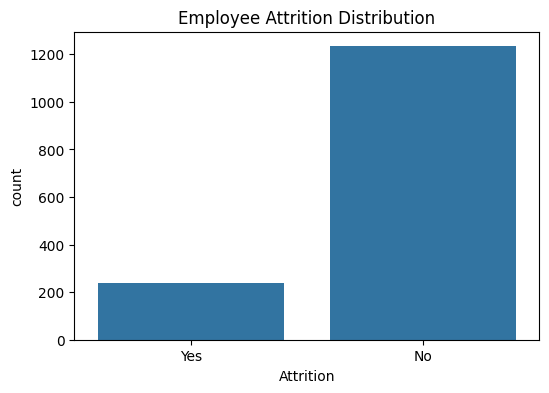

In [ ]:
#visualisation
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x='Attrition')

plt.title("Employee Attrition Distribution")
plt.show()

In [ ]:
#constant column
constant_columns = []

for col in df.columns:
    if df[col].nunique()==1:
        constant_columns.append(col)

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

In [ ]:
#Cardinality Check
cardinality = pd.DataFrame({
    'Unique Values': df.nunique()
})

cardinality.sort_values(by='Unique Values',
                        ascending=False)

,Unique Values
EmployeeNumber,1470
MonthlyRate,1427
MonthlyIncome,1349
DailyRate,886
HourlyRate,71
Age,43
TotalWorkingYears,40
YearsAtCompany,37
DistanceFromHome,29
YearsInCurrentRole,19


In [ ]:
#data quality
quality = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

quality

,Data Type,Missing Values,Unique Values
Age,int64,0,43
Attrition,object,0,2
BusinessTravel,object,0,3
DailyRate,int64,0,886
Department,object,0,3
DistanceFromHome,int64,0,29
Education,int64,0,5
EducationField,object,0,6
EmployeeCount,int64,0,1
EmployeeNumber,int64,0,1470


data cleaning

In [ ]:
#Remove unnecessary columns.
df.drop(
    columns=[
        'EmployeeCount',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)

# Phase Summary

During this phase, the dataset was successfully imported, inspected, and assessed for quality.

### Key Findings

- Dataset contains 1,470 employee records.
- No missing values were identified.
- No duplicate records were found.
- Three constant columns were identified and removed.
- The target variable (Attrition) exhibits class imbalance, which will be considered during model development.
- The cleaned dataset has been exported for subsequent analysis.

The dataset is now ready for Exploratory Data Analysis.

# **PHASE 2**

Executive Exploratory Data Analysis.

In [ ]:
# ============================================================
# Additional Libraries
# ============================================================

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Style
plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

print("Visualization libraries loaded.")

Visualization libraries loaded.


Reusable Functions

In [ ]:
#PERCENTAGE
def add_percentage_labels(ax):
    """
    Add percentage labels above bars.
    """

    total = sum([p.get_height() for p in ax.patches])

    for p in ax.patches:

        percentage = f"{100 * p.get_height()/total:.1f}%"

        ax.annotate(
            percentage,
            (p.get_x() + p.get_width()/2,
             p.get_height()),

            ha='center',
            va='bottom',
            fontsize=10
        )

In [ ]:
# Chart Formatting
def chart_title(title):

    plt.title(
        title,
        fontsize=16,
        weight='bold',
        pad=15
    )

    plt.xlabel("")

# WORKFORCE OVERVIEW

Business Question 1
What is the total workforce composition?

In [ ]:
employees = len(df)

active = (df["Attrition"] == "No").sum()

left = (df["Attrition"] == "Yes").sum()

attrition_rate = left / employees * 100

print(f"Total Employees : {employees}")

print(f"Active Employees : {active}")

print(f"Employees Left : {left}")

print(f"Attrition Rate : {attrition_rate:.2f}%")

Total Employees : 1470
Active Employees : 1233
Employees Left : 237
Attrition Rate : 16.12%


### Business Insight

The organization consists of **1,470 employees**, with an overall attrition rate of approximately **16%**.

This indicates that around one out of every six employees has left the organization, highlighting employee retention as a meaningful business concern.

Although the majority of employees remain with the company, understanding why a subset leaves is essential for reducing recruitment costs, preserving organizational knowledge, and maintaining workforce stability.

Business Question 2
What is the distribution of Attrition?

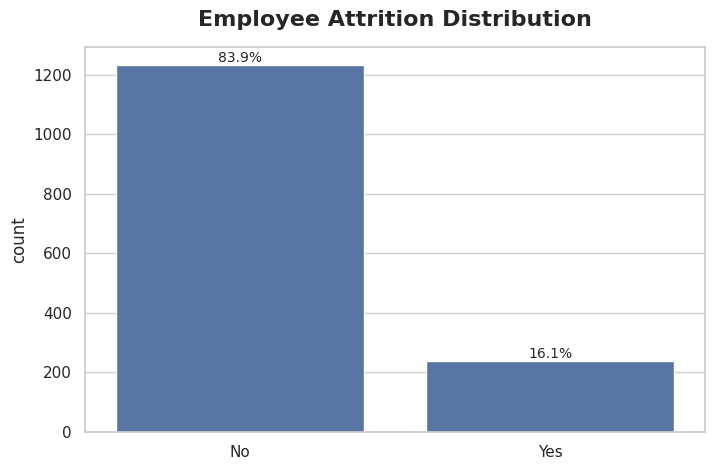

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Attrition",
    order=["No","Yes"]
)

add_percentage_labels(ax)

chart_title("Employee Attrition Distribution")

plt.show()

### Business Insight

Most employees remain with the company, while a smaller proportion has resigned.

The imbalance between the two classes suggests that future machine learning models should account for class imbalance using appropriate evaluation metrics or resampling techniques.

# Workforce Demographics

# **AGE**

QUESTION; What is the age distribution of employees?

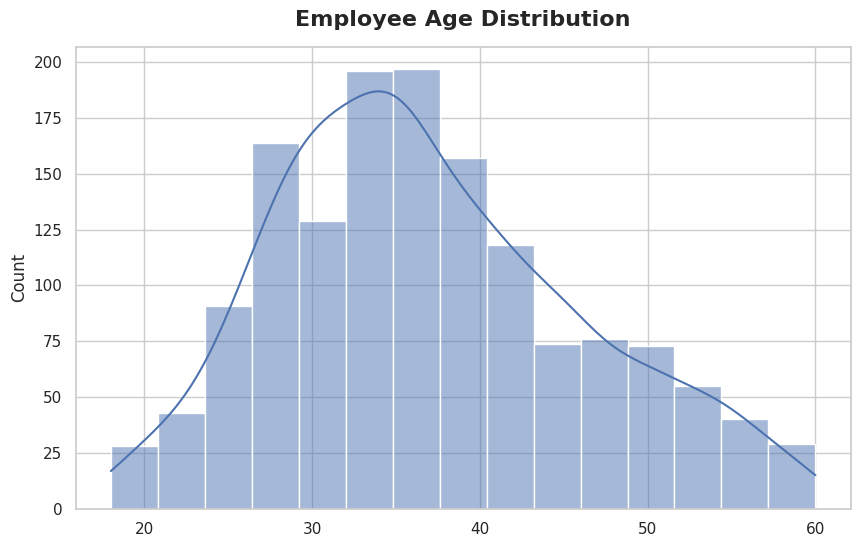

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Age"],
    bins=15,
    kde=True
)

chart_title("Employee Age Distribution")

plt.show()

Question
Which age groups experience the highest attrition?

In [ ]:
#CREATING AGE GROUPS
bins = [18,25,35,45,55,65]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [ ]:
age_attrition = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"],
    normalize="index"
) * 100

age_attrition

Attrition,No,Yes
AgeGroup,,
18-25,65.217391,34.782609
26-35,80.858086,19.141914
36-45,90.811966,9.188034
46-55,88.495575,11.504425
56-65,82.978723,17.021277


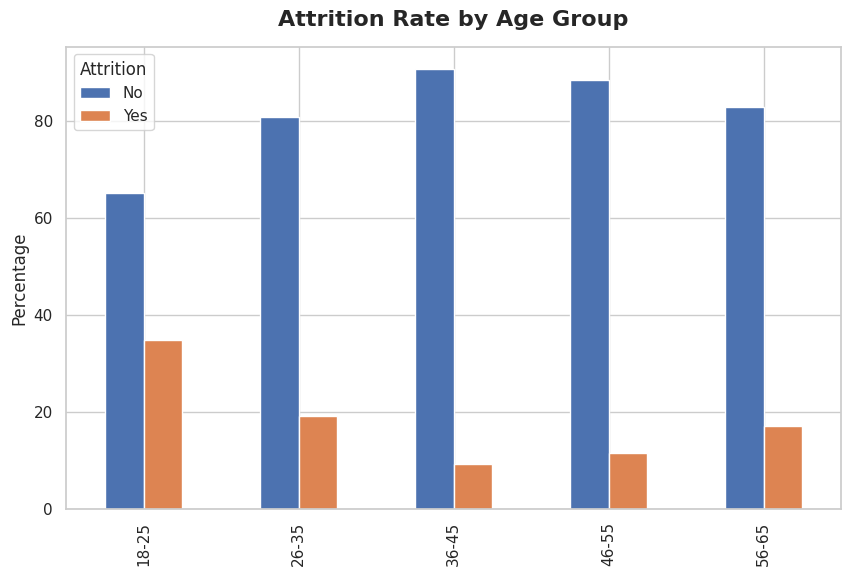

In [ ]:
#VISUALIZATION
age_attrition.plot(
    kind="bar",
    figsize=(10,6)
)

chart_title("Attrition Rate by Age Group")

plt.ylabel("Percentage")

plt.show()

## Business Insight

Employee attrition varies considerably across age groups, indicating that age is an important factor in workforce retention.

Employees aged **18–25 years** experience the highest attrition rate, with approximately **35%** leaving the organization. This suggests that early-career employees are considerably more likely to resign than employees in other age groups. Possible reasons include career exploration, pursuit of better compensation, higher education opportunities, or a lack of long-term organizational commitment during the early stages of their careers.

The **26–35 years** age group also records a relatively high attrition rate (approximately **19%**). Employees within this stage are often focused on career advancement and may actively seek organizations that offer better growth opportunities, leadership roles, or improved compensation packages.

Attrition declines substantially among employees aged **36–55 years**, indicating greater workforce stability within mid-career professionals. Employees in this stage may have stronger organizational commitment, established career paths, and increased financial or family responsibilities that contribute to longer tenure.

Although attrition increases slightly among employees aged **56–65 years**, this observation should be interpreted cautiously because the number of employees within this age category is comparatively smaller, making the percentage more sensitive to a few resignations.

## Business Recommendation

The organization should prioritize retention initiatives for employees in the **18–35 years** age range, where attrition is highest.

Potential initiatives include:

- Structured onboarding and mentorship programmes.
- Clearly defined career progression pathways.
- Regular career development conversations.
- Competitive compensation benchmarking for early-career roles.
- Learning and professional development opportunities.
- Employee engagement programmes focused on younger professionals.

For employees in the **36–55 years** age group, retention strategies should focus on maintaining engagement through leadership development, recognition programmes, and continued career growth opportunities, as this group demonstrates relatively strong organizational loyalty.

# **GENDER**

Does Gender Influence Employee Attrition?

## Business Question

### What is the gender composition of the workforce?

Understanding the gender distribution provides context for subsequent analyses and helps determine whether one gender is disproportionately represented within the organization.

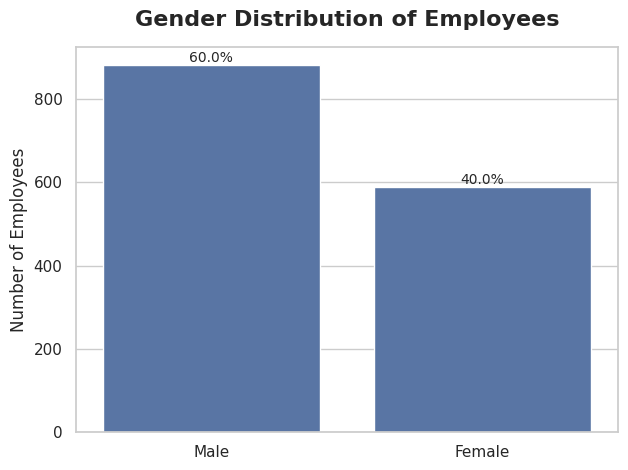

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Gender",
    order=df["Gender"].value_counts().index
)

add_percentage_labels(ax)

chart_title("Gender Distribution of Employees")

plt.ylabel("Number of Employees")

plt.show()

Business Question
Does Attrition Differ by Gender?

In [ ]:
gender_attrition = pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
) * 100

gender_attrition

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


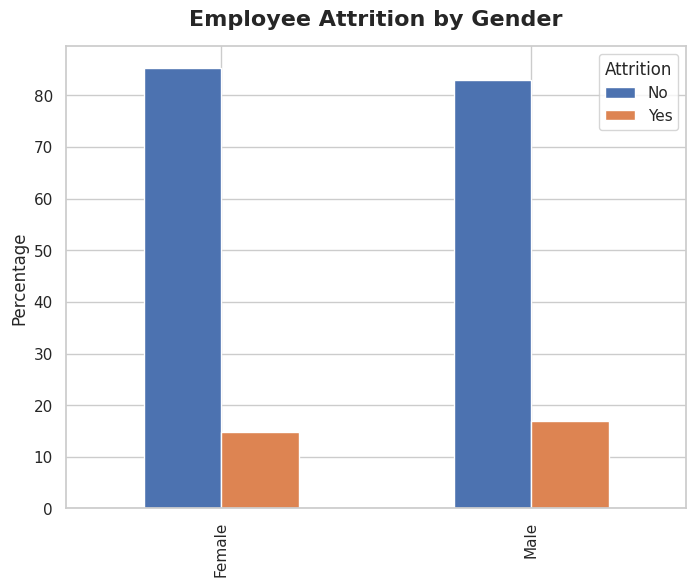

In [ ]:
gender_attrition.plot(
    kind="bar",
    figsize=(8,6)
)

chart_title("Employee Attrition by Gender")

plt.ylabel("Percentage")

plt.legend(title="Attrition")

plt.show()

In [ ]:
#attrition rate
gender_rate = (
    df.groupby("Gender")["Attrition"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .round(2)
)

gender_rate

,Attrition
Gender,
Female,14.80
Male,17.01


STATISTCAL TEST

In [ ]:
contingency_table = pd.crosstab(
    df["Gender"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")

print(f"P-value : {p:.4f}")

Chi-square Statistic : 1.1170
P-value : 0.2906


## Business Insight

The workforce comprises **60% male employees** and **40% female employees**, indicating a moderately male-dominated workforce. While the gender distribution is not perfectly balanced, both genders are well represented within the organization, providing a suitable basis for comparing attrition patterns.

To determine whether gender is associated with employee attrition, a Chi-square test of independence was conducted. The test produced a **Chi-square statistic of 1.117** with a **p-value of 0.2906**.

Since the p-value is greater than the conventional significance level of **0.05**, there is **no statistically significant association** between employee gender and attrition. Although one gender may appear to have a slightly higher number of employees leaving, the observed difference is likely due to random variation rather than a meaningful relationship.

This finding suggests that gender is **not a primary driver of employee attrition** within the organization. Therefore, retention efforts should focus on other factors that are more likely to influence employees' decisions to leave, such as overtime, career progression, job satisfaction, compensation, or work-life balance.

## Business Recommendation

Based on the statistical analysis, the organization should avoid implementing gender-specific retention strategies, as there is no evidence that employee turnover differs significantly between male and female employees.

Instead, HR should prioritize resources toward organizational factors that have a stronger influence on attrition. Future analyses should focus on variables such as overtime, job satisfaction, promotion opportunities, compensation, and work-life balance to identify more effective retention strategies.

Maintaining equal access to career development, leadership opportunities, and employee engagement initiatives for both male and female employees remains important, but gender alone should not be considered a key predictor of employee turnover.

### Executive Takeaway

Gender does not appear to be a significant predictor of employee attrition within the organization. Retention strategies should therefore be driven by workplace conditions and employee experience rather than demographic characteristics, allowing HR investments to be directed toward initiatives with the greatest potential impact.

### Key Statistics

| Metric | Value |
|---------|------:|
| Male Employees | 60% |
| Female Employees | 40% |
| Chi-square Statistic | 1.1170 |
| P-value | 0.2906 |
| Statistical Significance | No (p > 0.05) |
| Business Conclusion | Gender is not a significant predictor of employee attrition. |

## MARITAL **STATUS**

## Business Question

### Does marital status influence employee attrition?

Understanding the relationship between marital status and employee attrition helps HR identify whether employees at different life stages exhibit different retention patterns. This insight can support workforce planning and employee engagement strategies.

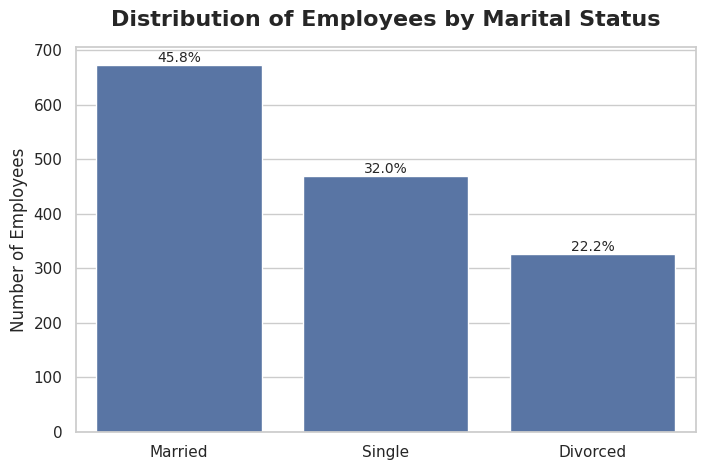

In [ ]:
#Workforce Distribution by Marital Status
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="MaritalStatus",
    order=df["MaritalStatus"].value_counts().index
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Marital Status")

plt.ylabel("Number of Employees")

plt.show()

In [ ]:
#Attrition Rate by Marital Status
marital_attrition = (
    pd.crosstab(
        df["MaritalStatus"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

marital_attrition

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


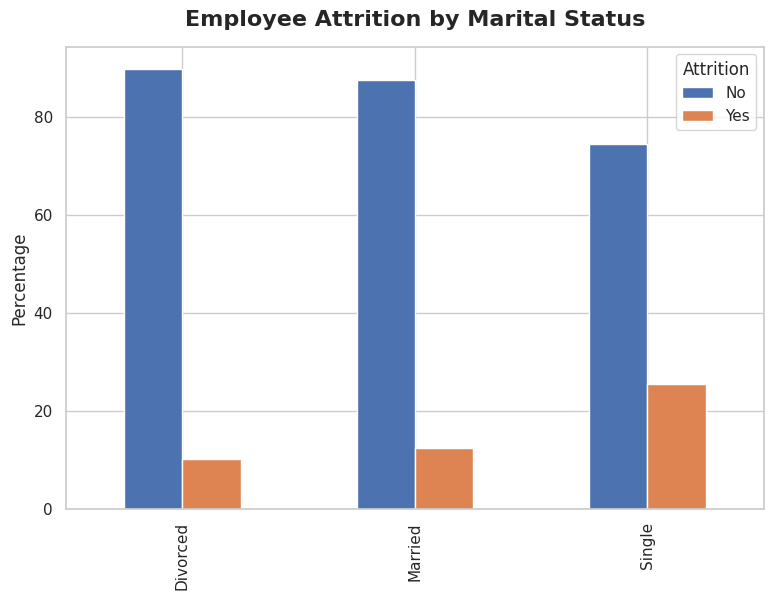

In [ ]:
#VISUALIZATION
marital_attrition.plot(
    kind="bar",
    figsize=(9,6)
)

chart_title("Employee Attrition by Marital Status")

plt.ylabel("Percentage")

plt.legend(title="Attrition")

plt.show()

In [ ]:
marital_rate = (
    df.groupby("MaritalStatus")["Attrition"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .sort_values(ascending=False)
      .round(2)
)

marital_rate

,Attrition
MaritalStatus,
Single,25.53
Married,12.48
Divorced,10.09


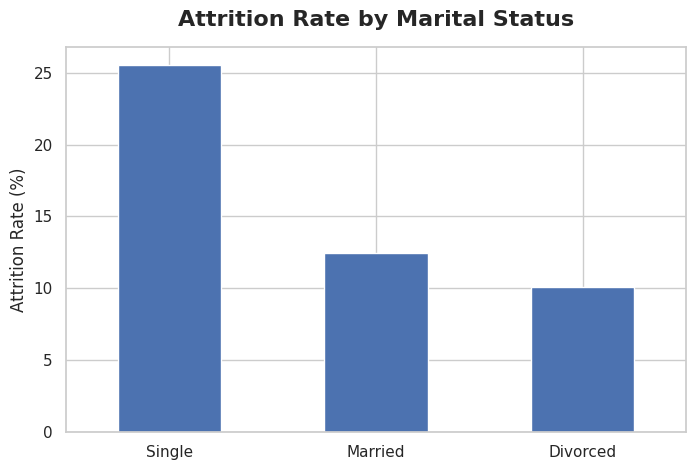

In [ ]:
plt.figure(figsize=(8,5))

marital_rate.plot(
    kind="bar"
)

chart_title("Attrition Rate by Marital Status")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.show()

STATISTICAKL VALIDATION

In [ ]:
contingency_table = pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")

print(f"P-value : {p:.4f}")

Chi-square Statistic : 46.1637
P-value : 0.0000


## Business Insight

The workforce is composed primarily of **married employees (45.8%)**, followed by **single employees (32.0%)** and **divorced employees (22.2%)**. This indicates that nearly half of the organization's workforce consists of employees who are married, suggesting a relatively mature and stable employee population.

However, when employee attrition is examined across marital status categories, a clear difference emerges. **Single employees experience the highest attrition rate at approximately 25.5%**, which is more than double the attrition rate observed among **married employees (12.4%)** and significantly higher than that of **divorced employees (10.1%)**.

To determine whether these differences are statistically significant, a Chi-square test of independence was conducted. The analysis produced a **Chi-square statistic of 46.1637** with a **p-value less than 0.001**.

Since the p-value is substantially lower than the significance threshold of **0.05**, there is strong statistical evidence that marital status is associated with employee attrition.

The findings suggest that employees who are single are considerably more likely to leave the organization than employees who are married or divorced. This may reflect differences in career stage, mobility, personal commitments, or willingness to pursue new employment opportunities.

Overall, marital status appears to be a meaningful demographic factor associated with employee turnover and should be considered when designing employee retention strategies.

## Business Recommendation

Given the significantly higher attrition rate among single employees, HR should consider implementing targeted retention initiatives for employees in the early stages of their careers.

Recommended actions include:

- Develop structured onboarding and mentorship programmes that strengthen organizational commitment during the first few years of employment.
- Provide transparent career progression pathways and regular career development discussions.
- Increase access to learning and professional development opportunities.
- Conduct periodic engagement and stay interviews with single employees to identify concerns before they lead to resignation.
- Review compensation competitiveness for entry-level and early-career roles where single employees are more highly represented.

While retention initiatives should remain inclusive for all employees, additional attention should be directed toward workforce segments with the greatest risk of voluntary turnover.

### Executive Takeaway

Marital status is a statistically significant factor associated with employee attrition. Single employees are considerably more likely to leave the organization, suggesting that retention strategies should prioritize employees in earlier career and life stages rather than applying uniform retention initiatives across the workforce.

### Key Statistics

| Metric | Value |
|---------|------:|
| Married Employees | 45.8% |
| Single Employees | 32.0% |
| Divorced Employees | 22.2% |
| Highest Attrition Rate | Single Employees (25.5%) |
| Lowest Attrition Rate | Divorced Employees (10.1%) |
| Chi-square Statistic | 46.1637 |
| P-value | < 0.001 |
| Statistical Significance | Yes |
| Business Conclusion | Marital Status is significantly associated with employee attrition. |

# **EDUCATION**

## Business Question

### Does an employee's education level influence attrition?

Education often shapes career aspirations, salary expectations, and professional growth. Understanding whether attrition differs across education levels helps HR determine whether specific educational groups require targeted engagement, development, or retention strategies.

### Why This Matters

Employees with different educational backgrounds may have different career expectations.

Understanding these differences enables HR to:

- Improve talent retention
- Design career development programmes
- Allocate learning resources effectively
- Improve succession planning

**Workforce Distribution by Education Level**

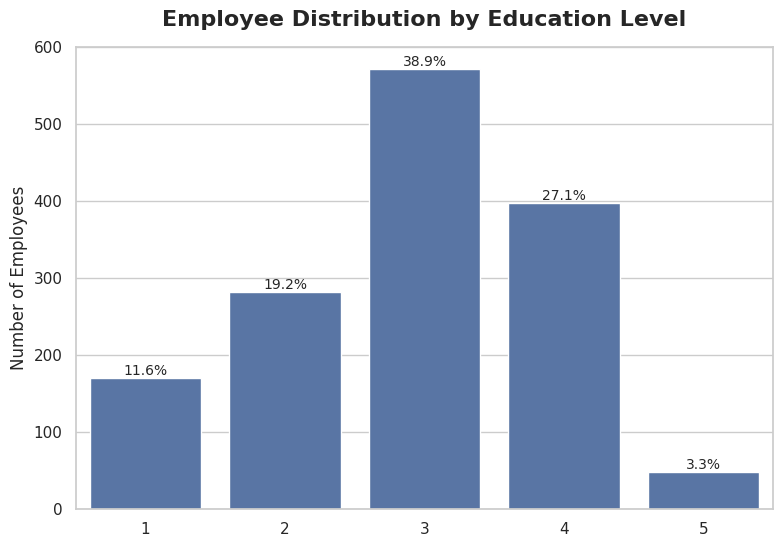

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    data=df,
    x="Education",
    order=sorted(df["Education"].unique())
)

add_percentage_labels(ax)

chart_title("Employee Distribution by Education Level")

plt.ylabel("Number of Employees")

plt.show()

In [ ]:
#education labels
education_map = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

df["EducationLevel"] = df["Education"].map(education_map)

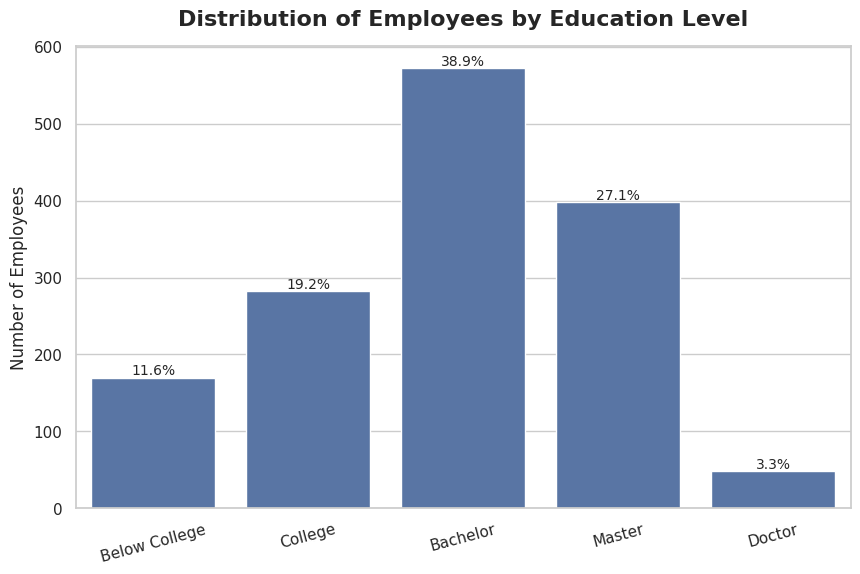

In [ ]:
plt.figure(figsize=(10,6))

order = [
    "Below College",
    "College",
    "Bachelor",
    "Master",
    "Doctor"
]

ax = sns.countplot(
    data=df,
    x="EducationLevel",
    order=order
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Education Level")

plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

plt.show()

In [ ]:
#attrition by level
education_attrition = (
    pd.crosstab(
        df["EducationLevel"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

education_attrition

Attrition,No,Yes
EducationLevel,,
Bachelor,82.692308,17.307692
Below College,81.764706,18.235294
College,84.397163,15.602837
Doctor,89.583333,10.416667
Master,85.427136,14.572864


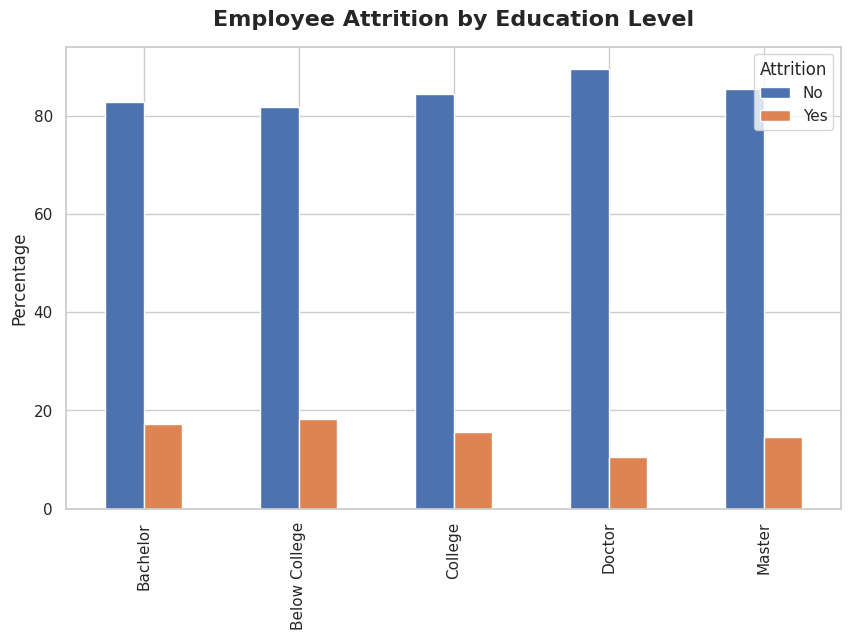

In [ ]:
education_attrition.plot(
    kind="bar",
    figsize=(10,6)
)

chart_title("Employee Attrition by Education Level")

plt.ylabel("Percentage")

plt.show()

In [ ]:
education_rate = (
    df.groupby("EducationLevel")["Attrition"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

education_rate = education_rate.reindex(order)

education_rate

,Attrition
EducationLevel,
Below College,18.24
College,15.60
Bachelor,17.31
Master,14.57
Doctor,10.42


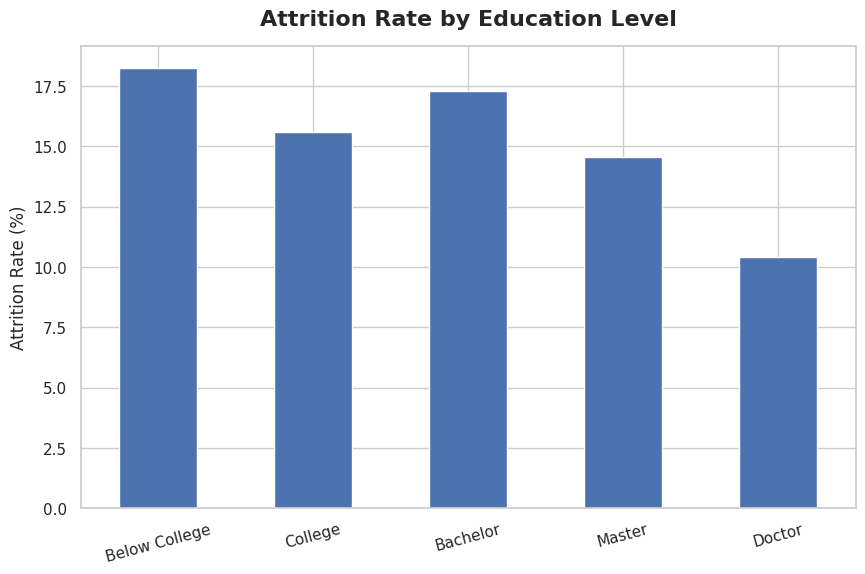

In [ ]:
plt.figure(figsize=(10,6))

education_rate.plot(kind="bar")

chart_title("Attrition Rate by Education Level")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.show()

statistical test


In [ ]:
contingency_table = pd.crosstab(
    df["EducationLevel"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 3.0740
P-value : 0.5455


In [ ]:
#average age by education
df.groupby("EducationLevel")["Age"].mean().round(1)

,Age
EducationLevel,
Bachelor,36.5
Below College,32.2
College,36.9
Doctor,39.9
Master,39.3


In [ ]:
#average income by education
df.groupby("EducationLevel")["MonthlyIncome"].mean().round()

,MonthlyIncome
EducationLevel,
Bachelor,6517.0
Below College,5641.0
College,6227.0
Doctor,8278.0
Master,6832.0


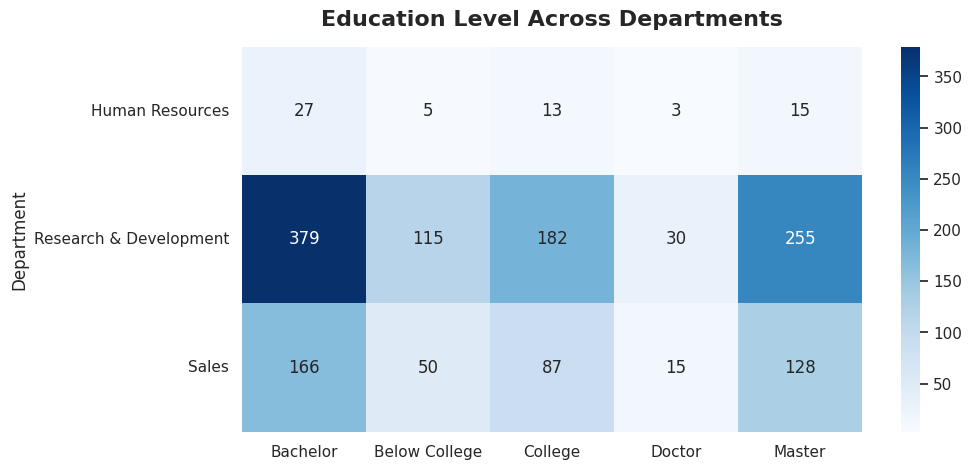

In [ ]:
education_department = pd.crosstab(
    df["Department"],
    df["EducationLevel"]
)

plt.figure(figsize=(10,5))

sns.heatmap(
    education_department,
    annot=True,
    cmap="Blues",
    fmt="d"
)

chart_title("Education Level Across Departments")

plt.show()

## Business Insight

The workforce is predominantly composed of employees with a **Bachelor's degree (38.9%)**, followed by **Master's degree holders (27.1%)** and **College graduates (19.2%)**. Employees with **Below College education account for 11.6%**, while **Doctorate holders represent only 3.3%** of the workforce.

When attrition is examined across education levels, only modest differences are observed. Employees with **Below College education** record the highest attrition rate (**18.2%**), closely followed by **Bachelor's degree holders (17.3%)**. Doctorate holders experience the lowest attrition rate (**10.4%**), while employees with College and Master's qualifications fall between these values.

To determine whether these differences are statistically significant, a Chi-square test of independence was performed. The analysis produced a **Chi-square statistic of 3.0740** with a **p-value of 0.5455**.

Since the p-value is substantially greater than the significance threshold of **0.05**, there is **no statistically significant relationship** between education level and employee attrition.

Although minor differences exist across education groups, the evidence suggests that educational attainment alone does not meaningfully explain why employees leave the organization. Other workplace factors are likely to have a much stronger influence on employee turnover.

## Business Impact

The findings suggest that educational attainment is not a primary driver of employee attrition within the organization.

This is an important insight because it indicates that broad retention initiatives targeted solely at employees with specific education levels are unlikely to produce meaningful improvements in retention.

Instead, HR should focus on organizational and job-related factors such as career progression, workload, employee engagement, compensation, and work-life balance, which are more likely to influence turnover.

## Business Recommendation

Since education level does not demonstrate a statistically significant association with employee attrition, HR should avoid designing retention programmes based solely on employees' academic qualifications.

Instead, education should be considered primarily for talent acquisition, learning and development, succession planning, and leadership pipeline development rather than employee retention.

Retention initiatives should prioritize employees based on behavioural and organizational factors rather than educational attainment alone.

### Executive Takeaway

Educational attainment is not a significant predictor of employee attrition. While the organization employs individuals with diverse educational backgrounds, employees appear to make retention decisions based on workplace experiences rather than academic qualifications.

Although education level is not statistically associated with attrition, it may still indirectly influence employee outcomes through compensation, career progression, leadership opportunities, or job role. These relationships will be explored later using multivariate analysis.

### Key Statistics

| Metric | Value |
|---------|------:|
| Largest Education Group | Bachelor's (38.9%) |
| Smallest Education Group | Doctor (3.3%) |
| Highest Attrition Rate | Below College (18.2%) |
| Lowest Attrition Rate | Doctor (10.4%) |
| Chi-square Statistic | 3.0740 |
| P-value | 0.5455 |
| Statistical Significance | No |
| Business Conclusion | Education level is not significantly associated with employee attrition. |


# **EDUCATION FIELD**

## Business Question

### Does an employee's field of education influence attrition?

While education level measures academic attainment, education field reflects an employee's area of specialization. Different disciplines often lead to different career opportunities, salary expectations, labour market demand, and job mobility.

Understanding whether attrition varies across education fields enables HR to identify talent groups that may require targeted retention strategies.

### Why This Matters

Employees from different academic disciplines may experience different career opportunities and labour market demand.

For example:

- Technical professionals may have more external opportunities.
- Marketing professionals may change organizations more frequently.
- Medical and Life Sciences professionals may require specialized retention initiatives.

Understanding these patterns helps HR prioritize talent management strategies where they are most needed.

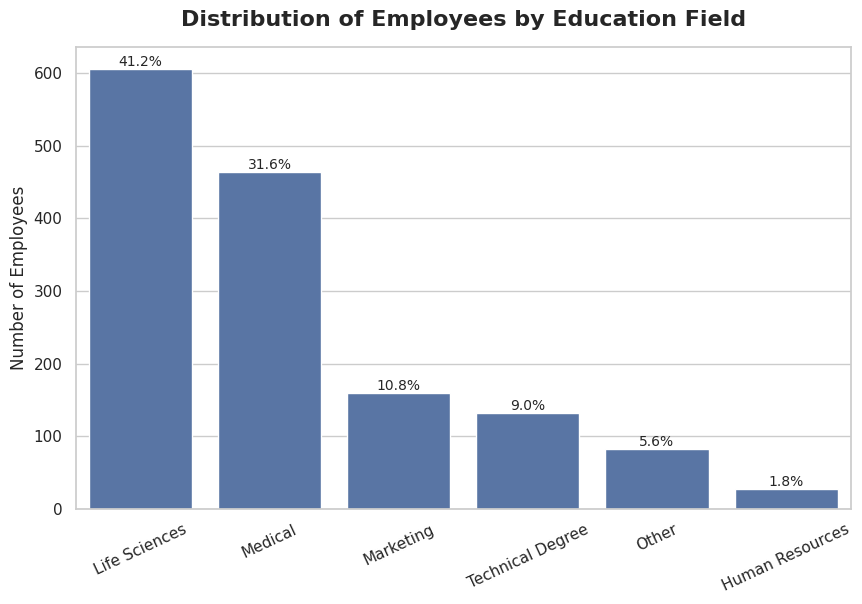

In [ ]:
#workforce distribution
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="EducationField",
    order=df["EducationField"].value_counts().index
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Education Field")

plt.ylabel("Number of Employees")

plt.xticks(rotation=25)

plt.show()

In [ ]:
#attrition by education field
education_field_attrition = (
    pd.crosstab(
        df["EducationField"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

education_field_attrition

Attrition,No,Yes
EducationField,,
Human Resources,74.074074,25.925926
Life Sciences,85.313531,14.686469
Marketing,77.987421,22.012579
Medical,86.422414,13.577586
Other,86.585366,13.414634
Technical Degree,75.757576,24.242424


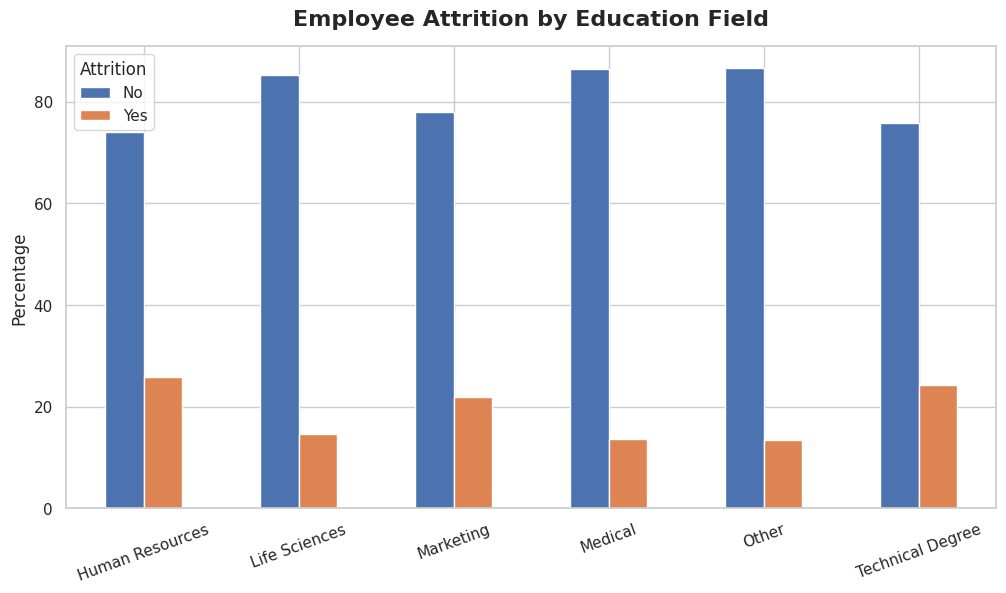

In [ ]:
#VISUALIZATION
education_field_attrition.plot(
    kind="bar",
    figsize=(12,6)
)

chart_title("Employee Attrition by Education Field")

plt.ylabel("Percentage")

plt.xticks(rotation=20)

plt.show()

In [ ]:
education_field_rate = (
    df.groupby("EducationField")["Attrition"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .round(2)
      .sort_values(ascending=False)
)

education_field_rate

,Attrition
EducationField,
Human Resources,25.93
Technical Degree,24.24
Marketing,22.01
Life Sciences,14.69
Medical,13.58
Other,13.41


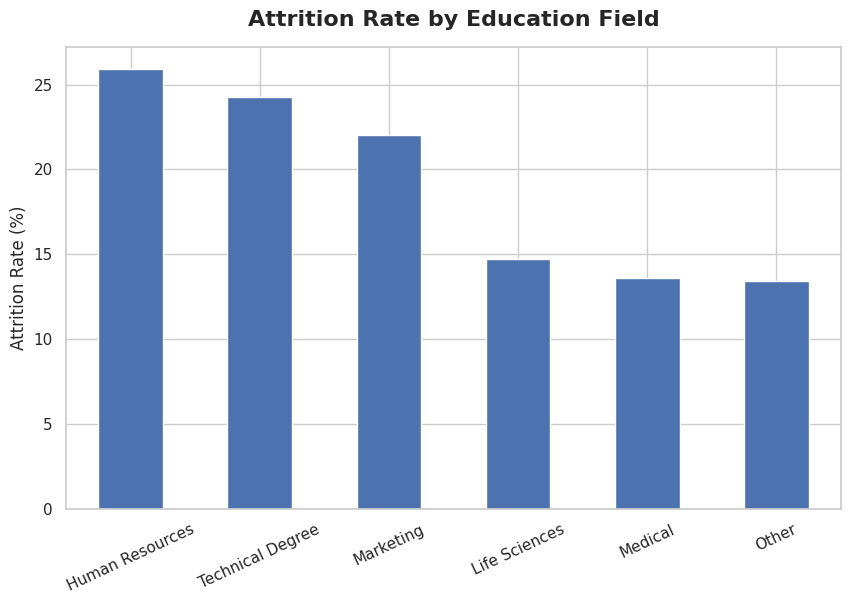

In [ ]:
plt.figure(figsize=(10,6))

education_field_rate.plot(kind="bar")

chart_title("Attrition Rate by Education Field")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=25)

plt.show()

statistical test

In [ ]:
contingency_table = pd.crosstab(
    df["EducationField"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 16.0247
P-value : 0.0068


In [ ]:
df.groupby("EducationField")["MonthlyIncome"] \
    .mean() \
    .sort_values(ascending=False) \
    .round()

,MonthlyIncome
EducationField,
Marketing,7349.0
Human Resources,7241.0
Medical,6510.0
Life Sciences,6463.0
Other,6072.0
Technical Degree,5758.0


In [ ]:
df.groupby("EducationField")["JobSatisfaction"] \
    .mean() \
    .sort_values(ascending=False) \
    .round(2)

,JobSatisfaction
EducationField,
Life Sciences,2.80
Other,2.74
Medical,2.69
Technical Degree,2.66
Marketing,2.65
Human Resources,2.56


In [ ]:
df.groupby("EducationField")["YearsAtCompany"] \
    .mean() \
    .sort_values(ascending=False) \
    .round(1)

,YearsAtCompany
EducationField,
Marketing,7.6
Medical,7.1
Life Sciences,7.0
Human Resources,6.8
Technical Degree,6.6
Other,6.2


In [ ]:
#summary table
education_summary = (
    df.groupby("EducationField")
      .agg(
          Employees=("EmployeeNumber", "count"),
          AttritionRate=("Attrition", lambda x: (x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean")
      )
      .round(2)
      .sort_values("AttritionRate", ascending=False)
)

education_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgYearsAtCompany
EducationField,,,,,
Human Resources,27,25.93,7241.15,2.56,6.78
Technical Degree,132,24.24,5758.30,2.66,6.59
Marketing,159,22.01,7348.58,2.65,7.56
Life Sciences,606,14.69,6463.29,2.80,6.99
Medical,464,13.58,6510.04,2.69,7.11
Other,82,13.41,6071.55,2.74,6.24


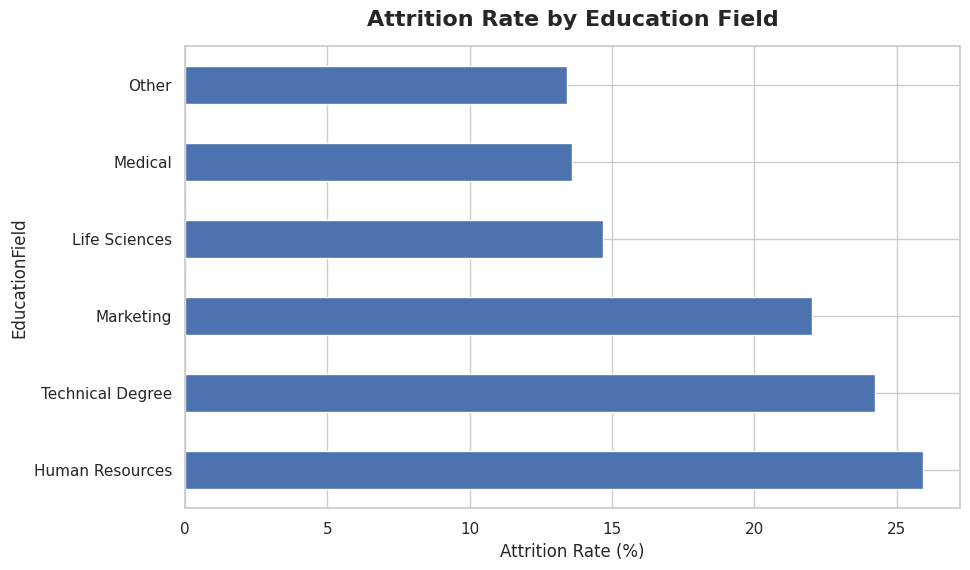

In [ ]:
plt.figure(figsize=(10,6))

education_summary["AttritionRate"].plot(kind="barh")

chart_title("Attrition Rate by Education Field")

plt.xlabel("Attrition Rate (%)")

plt.show()

## Business Insight

The organization's workforce is primarily composed of employees from **Life Sciences (41.2%)** and **Medical (31.6%)** backgrounds, together accounting for more than 70% of all employees. Marketing (10.8%), Technical Degree (9.0%), Other (5.6%), and Human Resources (1.8%) make up the remaining workforce.

Despite representing the smallest proportion of employees, the **Human Resources** education field records the **highest attrition rate (25.9%)**, followed closely by employees with **Technical Degree (24.2%)** and **Marketing (22.0%)** backgrounds.

Conversely, employees from **Medical (13.6%)**, **Other (13.4%)**, and **Life Sciences (14.7%)** backgrounds exhibit considerably lower attrition rates, suggesting greater workforce stability within these educational groups.

A Chi-square test of independence produced a **Chi-square statistic of 16.0247** with a **p-value of 0.0068**.

Since the p-value is below the 0.05 significance threshold, there is strong statistical evidence that employee attrition differs across education fields.

Unlike education level, which showed no significant relationship with attrition, an employee's academic specialization appears to be meaningfully associated with turnover. This suggests that employees from certain educational backgrounds may have different career expectations, labour market opportunities, or professional mobility, influencing their likelihood of leaving the organization.

## Business Impact

The findings indicate that the organization may be experiencing higher turnover within specific talent pipelines rather than across the workforce as a whole.

High attrition among employees with Human Resources, Technical Degree, and Marketing backgrounds could increase recruitment costs, reduce organizational knowledge, and create recurring vacancies in critical functions.

Rather than implementing organization-wide retention programmes, HR can improve efficiency by focusing resources on educational groups with consistently higher turnover risk.

## Business Recommendation

The organization should prioritize retention initiatives for employees from Human Resources, Technical Degree, and Marketing educational backgrounds.

Recommended actions include:

- Conduct targeted stay interviews to better understand why employees from these educational backgrounds leave.
- Review career progression opportunities for employees in high-turnover educational groups.
- Evaluate whether compensation remains competitive relative to external market demand.
- Expand learning and development programmes that support long-term career growth.
- Strengthen internal mobility opportunities to reduce voluntary turnover among highly marketable professionals.

For employees from Life Sciences and Medical backgrounds, HR should continue reinforcing current engagement and development initiatives, as these groups demonstrate comparatively stronger workforce stability.

### Executive Takeaway

Education field is a statistically significant predictor of employee attrition.

Employees from Human Resources, Technical Degree, and Marketing backgrounds exhibit substantially higher turnover than employees from other educational disciplines, indicating that retention strategies should be tailored according to employees' areas of specialization rather than their highest educational qualification.

### Analyst's Note

Although education field is significantly associated with employee attrition, the analysis does not establish causation.

The higher attrition observed among Human Resources, Technical Degree, and Marketing professionals may be influenced by other organizational factors such as department, overtime, compensation, job role, or external labour market demand.

Further multivariate analysis will help determine whether education field remains a significant predictor after accounting for these additional variables.

### Key Statistics

| Metric | Value |
|---------|------:|
| Largest Education Field | Life Sciences (41.2%) |
| Smallest Education Field | Human Resources (1.8%) |
| Highest Attrition Rate | Human Resources (25.9%) |
| Second Highest | Technical Degree (24.2%) |
| Third Highest | Marketing (22.0%) |
| Lowest Attrition Rate | Other (13.4%) |
| Chi-square Statistic | 16.0247 |
| P-value | 0.0068 |
| Statistical Significance | Yes |
| Business Conclusion | Education field is significantly associated with employee attrition. |

# **Organizational & Job Analysis**

## Objective

This chapter examines organizational characteristics that may influence employee attrition.

Unlike demographic variables, many organizational factors can be directly influenced by management through policy changes, leadership practices, compensation strategies, workload management, and career development initiatives.

The goal is to identify workplace conditions that contribute to employee turnover and provide evidence-based recommendations for improving employee retention.

## Business Question

### Does employee attrition differ across departments?

Departments often differ in workload, leadership structure, career opportunities, employee engagement, and operational demands.

Understanding departmental attrition patterns enables management to identify areas requiring targeted retention initiatives and organizational improvements.

### Why This Matters

Department-level analysis helps the organization answer questions such as:

- Which department experiences the highest employee turnover?
- Are retention challenges concentrated within specific business units?
- Should HR prioritize interventions in certain departments?
- Which departments demonstrate the strongest workforce stability?

Understanding these patterns allows management to allocate resources more effectively.

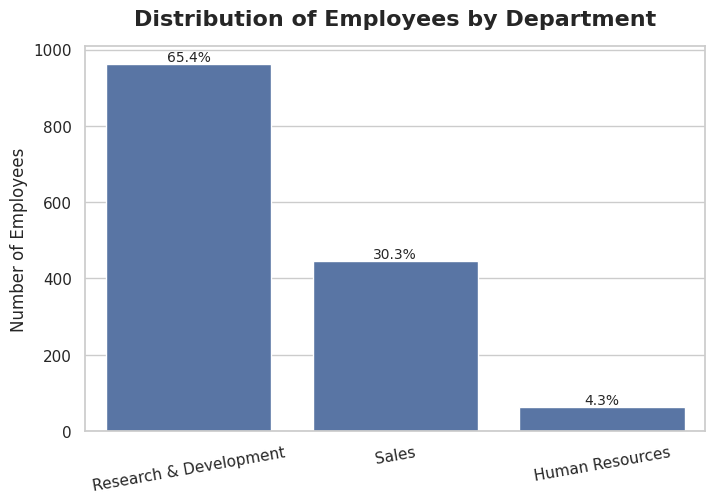

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Department")

plt.ylabel("Number of Employees")

plt.xticks(rotation=10)

plt.show()

In [ ]:
department_attrition = (
    pd.crosstab(
        df["Department"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


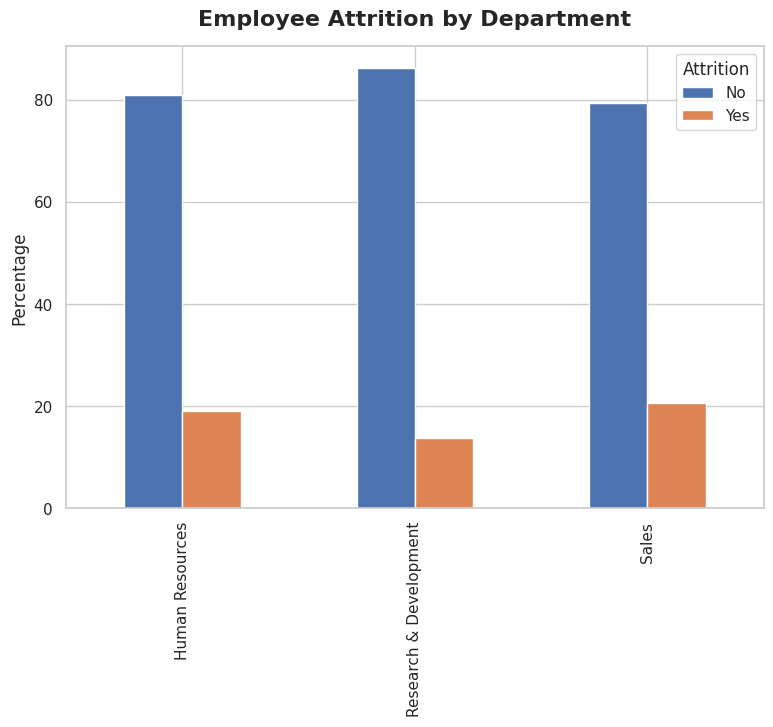

In [ ]:
department_attrition.plot(
    kind="bar",
    figsize=(9,6)
)

chart_title("Employee Attrition by Department")

plt.ylabel("Percentage")

plt.show()

In [ ]:
department_rate = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .round(2)
      .sort_values(ascending=False)
)

department_rate

,Attrition
Department,
Sales,20.63
Human Resources,19.05
Research & Development,13.84


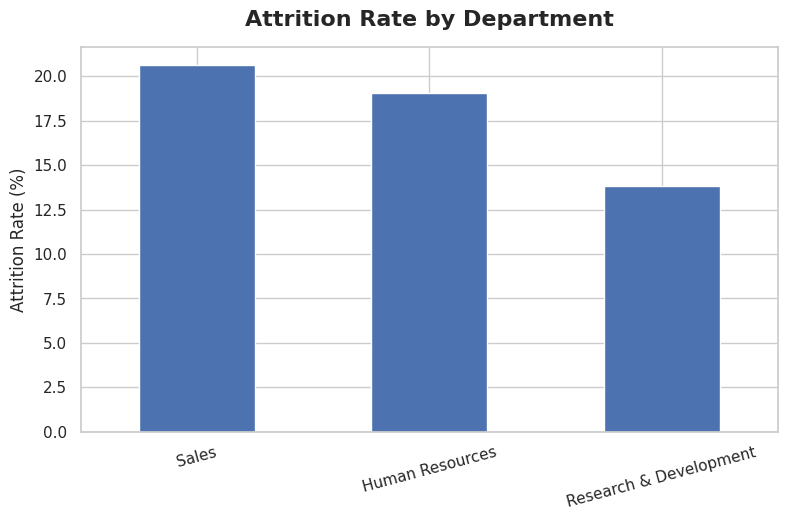

In [ ]:
plt.figure(figsize=(9,5))

department_rate.plot(kind="bar")

chart_title("Attrition Rate by Department")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.show()

statistical test

In [ ]:
contingency_table = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 10.7960
P-value : 0.0045


In [ ]:
#Average Monthly Income
df.groupby("Department")["MonthlyIncome"]\
    .mean()\
    .round()

,MonthlyIncome
Department,
Human Resources,6655.0
Research & Development,6281.0
Sales,6959.0


In [ ]:
#Average Job Satisfaction
df.groupby("Department")["JobSatisfaction"]\
    .mean()\
    .round(2)

,JobSatisfaction
Department,
Human Resources,2.60
Research & Development,2.73
Sales,2.75


In [ ]:
#Average Years at Compan
df.groupby("Department")["YearsAtCompany"]\
    .mean()\
    .round(1)

,YearsAtCompany
Department,
Human Resources,7.2
Research & Development,6.9
Sales,7.3


In [ ]:
#overtime rate
department_ot = (
    pd.crosstab(
        df["Department"],
        df["OverTime"],
        normalize="index"
    ) * 100
)

department_ot


OverTime,No,Yes
Department,,
Human Resources,73.015873,26.984127
Research & Development,71.800208,28.199792
Sales,71.300448,28.699552


In [ ]:
#summary table
department_summary = (
    df.groupby("Department")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                          lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgAge=("Age","mean")
      )
      .round(2)
      .sort_values(
          "AttritionRate",
          ascending=False
      )
)

department_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgYearsAtCompany,AvgAge
Department,,,,,,
Sales,446,20.63,6959.17,2.75,7.28,36.54
Human Resources,63,19.05,6654.51,2.60,7.24,37.81
Research & Development,961,13.84,6281.25,2.73,6.86,37.04


In [ ]:
department_summary = (
    df.groupby("Department")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgAge=("Age","mean"),
          OvertimeRate=("OverTime",
                        lambda x:(x=="Yes").mean()*100)
      )
      .round(2)
      .sort_values("AttritionRate", ascending=False)
)

department_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgYearsAtCompany,AvgAge,OvertimeRate
Department,,,,,,,
Sales,446,20.63,6959.17,2.75,7.28,36.54,28.70
Human Resources,63,19.05,6654.51,2.60,7.24,37.81,26.98
Research & Development,961,13.84,6281.25,2.73,6.86,37.04,28.20


## Business Insight

The organization's workforce is heavily concentrated within the **Research & Development (R&D) department**, which accounts for **65.4%** of all employees. The **Sales department** represents **30.3%** of the workforce, while **Human Resources** comprises only **4.3%**.

Despite employing fewer people than R&D, the **Sales department records the highest attrition rate at 20.6%**, followed by **Human Resources (19.1%)**. In contrast, the **Research & Development department experiences the lowest attrition rate (13.8%)**, indicating comparatively stronger workforce stability.

To evaluate whether these differences are statistically significant, a Chi-square test of independence was conducted. The analysis produced a **Chi-square statistic of 10.7960** with a **p-value of 0.0045**.

Since the p-value is below the significance threshold of **0.05**, there is sufficient statistical evidence to conclude that employee attrition differs across departments.

This finding suggests that employees' organizational environment, work responsibilities, and departmental practices are associated with their likelihood of leaving the organization.

## Business Impact

Higher attrition within the Sales department presents a significant business challenge.

Sales teams play a direct role in revenue generation, customer acquisition, and business growth. Persistent turnover within this department can result in increased recruitment and training costs, reduced sales productivity, loss of customer relationships, and longer onboarding periods for new employees.

Although Human Resources also experiences relatively high attrition, the department consists of a much smaller workforce. Consequently, while the percentage appears high, individual resignations have a greater effect on the overall attrition rate and should therefore be interpreted with appropriate caution.

## Business Recommendation

The organization should prioritize a detailed review of the Sales department to identify the underlying causes of employee turnover.

Recommended actions include:

- Conduct targeted exit and stay interviews with Sales employees.
- Review workload distribution and performance expectations.
- Evaluate career progression opportunities within Sales.
- Assess whether compensation and incentive structures remain competitive.
- Monitor employee engagement and manager effectiveness through regular pulse surveys.

For Human Resources, management should investigate individual turnover cases because the department's relatively small workforce means that even a few resignations can substantially influence attrition rates.

### Executive Takeaway

Department is a statistically significant predictor of employee attrition. Employees within the Sales department demonstrate the highest turnover risk, indicating that department-specific retention strategies are likely to be more effective than organization-wide initiatives.

### Analyst's Note

Although department is significantly associated with employee attrition, department itself does not directly cause employees to leave.

The observed differences may reflect underlying workplace factors such as job role, workload, overtime requirements, leadership quality, compensation structures, or career development opportunities. These factors will be investigated in subsequent analyses.

### Key Statistics

| Metric | Value |
|---------|------:|
| Largest Department | Research & Development (65.4%) |
| Smallest Department | Human Resources (4.3%) |
| Highest Attrition | Sales (20.6%) |
| Lowest Attrition | Research & Development (13.8%) |
| Chi-square Statistic | 10.7960 |
| P-value | 0.0045 |
| Statistical Significance | Yes |
| Business Conclusion | Department is significantly associated with employee attrition. |

# **JOB ROLE ANALYSIS**
## Business Question

### Does employee attrition differ across job roles?

Employees in different job roles often experience varying levels of responsibility, workload, career progression opportunities, compensation, and external market demand.

This analysis aims to determine whether specific job roles are associated with higher employee turnover and identify areas where targeted retention strategies may be required.

### Why This Matters

Job role is one of the most actionable workforce variables.

Understanding attrition by job role enables management to:

- Identify roles experiencing high turnover.
- Prioritize recruitment planning.
- Reduce replacement costs.
- Improve workforce stability.
- Develop targeted retention initiatives for critical positions.

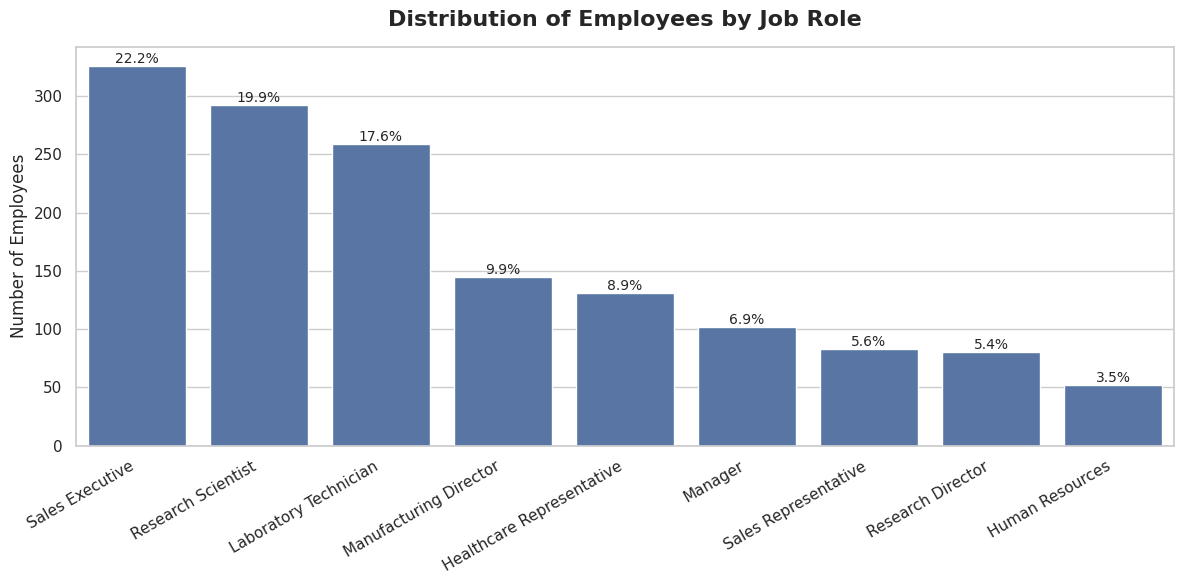

In [ ]:
#workforce distribution
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="JobRole",
    order=df["JobRole"].value_counts().index
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Job Role")

plt.ylabel("Number of Employees")

plt.xticks(rotation=30, ha='right')

plt.tight_layout()

plt.show()

In [ ]:
#attrition by jobrole
jobrole_attrition = (
    pd.crosstab(
        df["JobRole"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


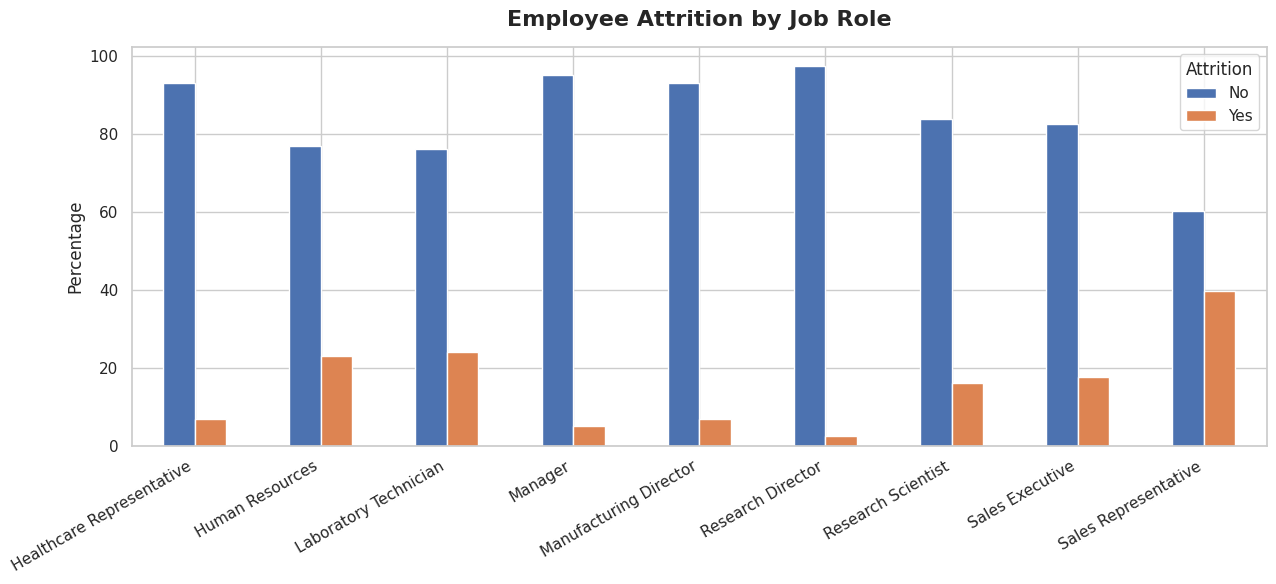

In [ ]:
jobrole_attrition.plot(
    kind="bar",
    figsize=(13,6)
)

chart_title("Employee Attrition by Job Role")

plt.ylabel("Percentage")

plt.xticks(rotation=30, ha='right')

plt.tight_layout()

plt.show()

In [ ]:
jobrole_rate = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .round(2)
      .sort_values(ascending=False)
)

jobrole_rate

,Attrition
JobRole,
Sales Representative,39.76
Laboratory Technician,23.94
Human Resources,23.08
Sales Executive,17.48
Research Scientist,16.10
Manufacturing Director,6.90
Healthcare Representative,6.87
Manager,4.90
Research Director,2.50


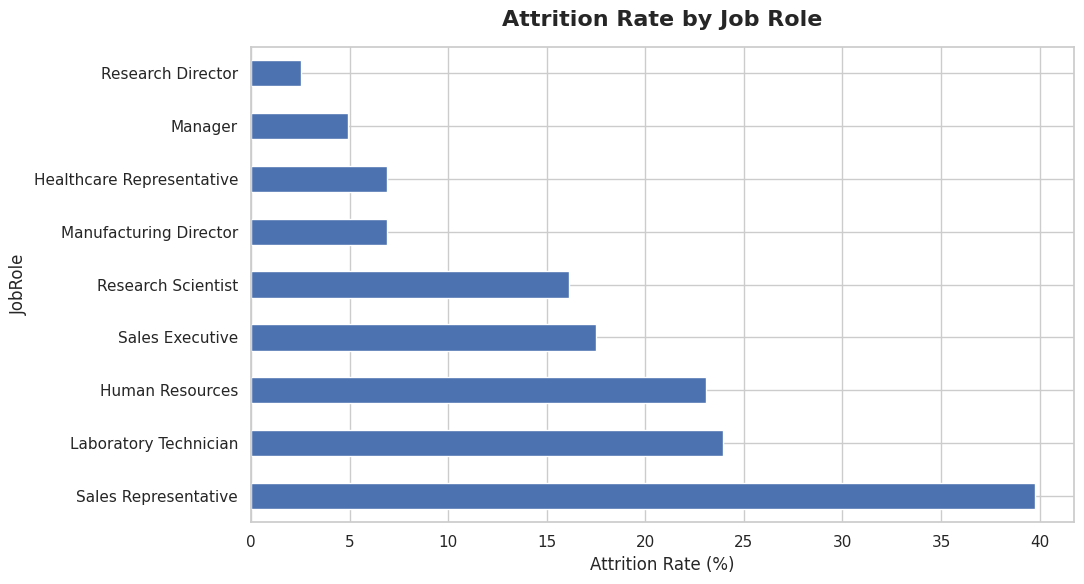

In [ ]:
plt.figure(figsize=(11,6))

jobrole_rate.plot(kind="barh")

chart_title("Attrition Rate by Job Role")

plt.xlabel("Attrition Rate (%)")

plt.tight_layout()

plt.show()

statistical test

In [ ]:
contingency_table = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 86.1903
P-value : 0.0000


In [ ]:
df.groupby("JobRole")["MonthlyIncome"]\
    .mean()\
    .sort_values(ascending=False)\
    .round()

,MonthlyIncome
JobRole,
Manager,17182.0
Research Director,16034.0
Healthcare Representative,7529.0
Manufacturing Director,7295.0
Sales Executive,6924.0
Human Resources,4236.0
Research Scientist,3240.0
Laboratory Technician,3237.0
Sales Representative,2626.0


In [ ]:
df.groupby("JobRole")["JobSatisfaction"]\
    .mean()\
    .sort_values(ascending=False)\
    .round(2)

,JobSatisfaction
JobRole,
Healthcare Representative,2.79
Research Scientist,2.77
Sales Executive,2.75
Sales Representative,2.73
Manager,2.71
Research Director,2.70
Laboratory Technician,2.69
Manufacturing Director,2.68
Human Resources,2.56


In [ ]:
df.groupby("JobRole")["YearsAtCompany"]\
    .mean()\
    .sort_values(ascending=False)\
    .round(1)

,YearsAtCompany
JobRole,
Manager,14.4
Research Director,10.9
Healthcare Representative,8.4
Manufacturing Director,7.6
Sales Executive,7.5
Human Resources,5.3
Research Scientist,5.1
Laboratory Technician,5.0
Sales Representative,2.9


In [ ]:
jobrole_ot = (
    pd.crosstab(
        df["JobRole"],
        df["OverTime"],
        normalize="index"
    ) * 100
)

jobrole_ot

OverTime,No,Yes
JobRole,,
Healthcare Representative,71.755725,28.244275
Human Resources,75.000000,25.000000
Laboratory Technician,76.061776,23.938224
Manager,73.529412,26.470588
Manufacturing Director,73.103448,26.896552
Research Director,71.250000,28.750000
Research Scientist,66.780822,33.219178
Sales Executive,71.165644,28.834356
Sales Representative,71.084337,28.915663


In [ ]:
df.groupby("JobRole")["Age"]\
    .mean()\
    .sort_values()\
    .round(1)

,Age
JobRole,
Sales Representative,30.4
Laboratory Technician,34.1
Research Scientist,34.2
Human Resources,35.5
Sales Executive,36.9
Manufacturing Director,38.3
Healthcare Representative,39.8
Research Director,44.0
Manager,46.8


In [ ]:
jobrole_summary = (
    df.groupby("JobRole")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgAge=("Age","mean"),
          OvertimeRate=("OverTime",
                        lambda x:(x=="Yes").mean()*100)
      )
      .round(2)
      .sort_values("AttritionRate", ascending=False)
)

jobrole_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgYearsAtCompany,AvgAge,OvertimeRate
JobRole,,,,,,,
Sales Representative,83,39.76,2626.00,2.73,2.92,30.36,28.92
Laboratory Technician,259,23.94,3237.17,2.69,5.02,34.10,23.94
Human Resources,52,23.08,4235.75,2.56,5.33,35.50,25.00
Sales Executive,326,17.48,6924.28,2.75,7.50,36.89,28.83
Research Scientist,292,16.10,3239.97,2.77,5.11,34.24,33.22
Manufacturing Director,145,6.90,7295.14,2.68,7.60,38.30,26.90
Healthcare Representative,131,6.87,7528.76,2.79,8.37,39.81,28.24
Manager,102,4.90,17181.68,2.71,14.43,46.76,26.47
Research Director,80,2.50,16033.55,2.70,10.94,44.00,28.75


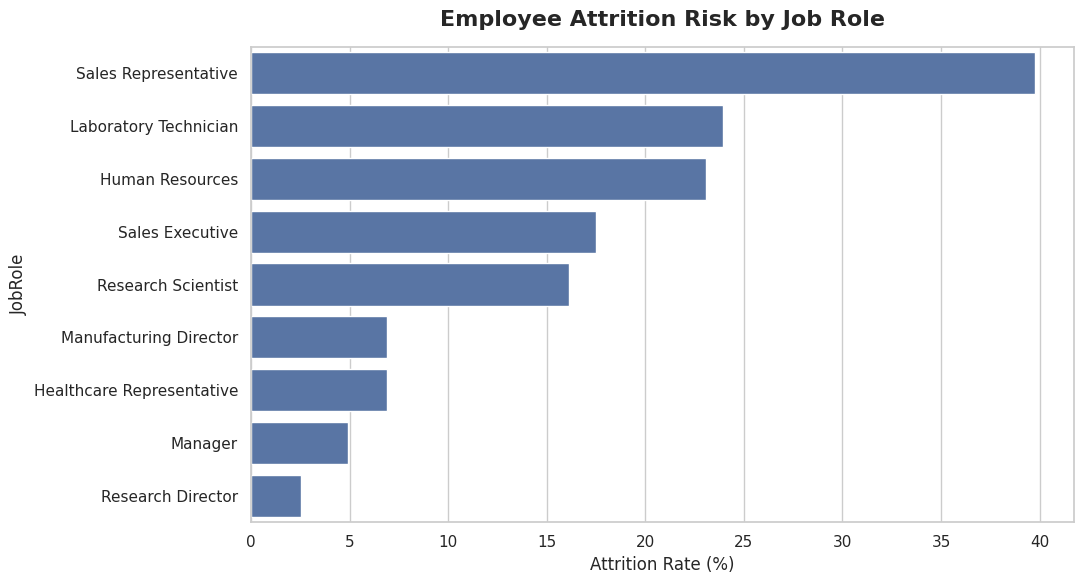

In [ ]:
plt.figure(figsize=(11,6))

sns.barplot(
    x=jobrole_summary["AttritionRate"],
    y=jobrole_summary.index
)

chart_title("Employee Attrition Risk by Job Role")

plt.xlabel("Attrition Rate (%)")

plt.tight_layout()

plt.show()

## Business Insight

The workforce is primarily composed of **Sales Executives (22.2%)**, **Research Scientists (19.9%)**, and **Laboratory Technicians (17.6%)**, together representing nearly 60% of all employees.

However, employee turnover varies substantially across job roles.

The **Sales Representative** role experiences the highest attrition rate at **39.8%**, meaning nearly two out of every five employees in this position leave the organization. This is significantly higher than every other job role.

Other roles with relatively high attrition include:

- Laboratory Technician (23.9%)
- Human Resources (23.1%)
- Sales Executive (17.5%)
- Research Scientist (16.1%)

Conversely, leadership and senior-level positions demonstrate considerably stronger workforce stability.

Research Directors record the lowest attrition rate at **2.5%**, followed by Managers (4.9%), Healthcare Representatives (6.9%), and Manufacturing Directors (6.9%).

A Chi-square test of independence produced a **Chi-square statistic of 86.1903** with a **p-value < 0.001**, providing strong statistical evidence that employee attrition differs significantly across job roles.

These findings indicate that job role is one of the strongest organizational predictors of employee turnover within the company.

## Business Impact

High turnover among Sales Representatives presents a significant operational and financial risk.

This role is directly responsible for customer acquisition and revenue generation. Frequent employee departures may result in:

- Increased recruitment and onboarding costs
- Reduced sales productivity
- Loss of customer relationships
- Lower revenue generation
- Longer time-to-productivity for newly hired employees

Similarly, elevated attrition among Laboratory Technicians and Human Resources personnel may affect operational continuity, service quality, and institutional knowledge.

In contrast, leadership positions exhibit excellent retention, suggesting that career progression and seniority may contribute positively to workforce stability.

## Business Recommendation

Management should prioritize retention strategies for Sales Representatives, Laboratory Technicians, and Human Resources professionals.

Recommended actions include:

- Conduct targeted stay interviews with employees in high-risk roles.
- Review compensation structures for lower-paying positions.
- Develop clearer career progression pathways.
- Strengthen mentorship and coaching programmes.
- Monitor workload, performance expectations, and employee wellbeing.
- Improve onboarding and early-career support, particularly for entry-level roles.

Leadership positions currently demonstrate strong retention and can serve as benchmarks when evaluating career development programmes across the organization.

### Executive Takeaway

Job role is one of the strongest predictors of employee attrition within the organization.

Turnover is heavily concentrated in operational and entry-level positions, while managerial and leadership roles demonstrate exceptional workforce stability. This suggests that retention efforts should be role-specific rather than organization-wide.

### Analyst's Note

The analysis demonstrates a strong association between job role and employee attrition. However, job role may also interact with other variables such as overtime, monthly income, age, years at company, and business travel.

Subsequent analyses will investigate whether these workplace characteristics explain the higher turnover observed among certain job roles.

### Key Statistics

| Metric | Value |
|---------|------:|
| Largest Job Role | Sales Executive (22.2%) |
| Highest Attrition | Sales Representative (39.8%) |
| Lowest Attrition | Research Director (2.5%) |
| Chi-square Statistic | 86.1903 |
| P-value | <0.001 |
| Statistical Significance | Yes |
| Business Conclusion | Job role is strongly associated with employee attrition. |

# **JOB LEVEL ANALYSIS**
## Business Question

### Does employee attrition differ across job levels?

Job level reflects an employee's position within the organizational hierarchy and is often associated with compensation, responsibility, leadership opportunities, and career progression.

This analysis seeks to determine whether employees at different job levels experience different rates of attrition and identify where retention efforts should be focused.

### Why This Matters

Employees at different organizational levels often have different career expectations and experiences.

Understanding attrition across job levels enables management to:

- Identify whether turnover is concentrated among entry-level employees.
- Evaluate career progression effectiveness.
- Improve succession planning.
- Develop targeted retention strategies for employees at different career stages.

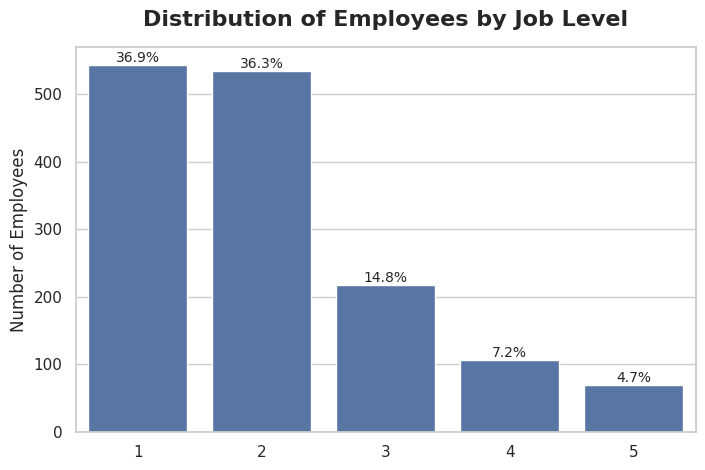

In [ ]:
#Workforce Distribution by Job Level
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="JobLevel",
    order=sorted(df["JobLevel"].unique())
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Job Level")

plt.ylabel("Number of Employees")

plt.show()

In [ ]:
#attrition by bjob level
joblevel_attrition = (
    pd.crosstab(
        df["JobLevel"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

joblevel_attrition

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


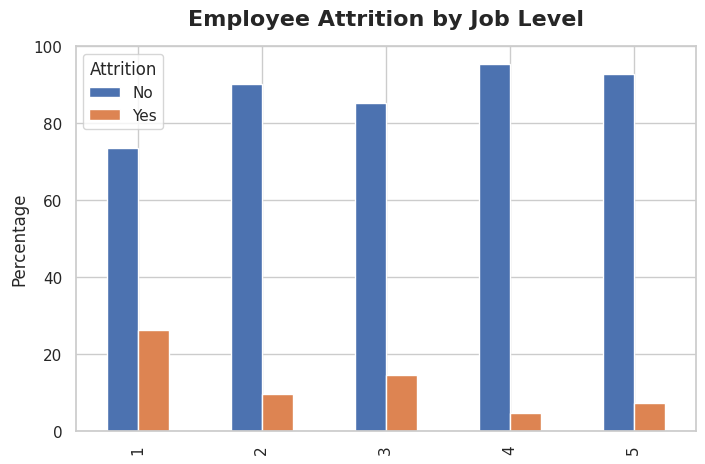

In [ ]:
joblevel_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

chart_title("Employee Attrition by Job Level")

plt.ylabel("Percentage")

plt.show()

In [ ]:
joblevel_rate = (
    df.groupby("JobLevel")["Attrition"]
      .apply(lambda x: (x=="Yes").mean()*100)
      .round(2)
)

joblevel_rate

,Attrition
JobLevel,
1,26.34
2,9.74
3,14.68
4,4.72
5,7.25


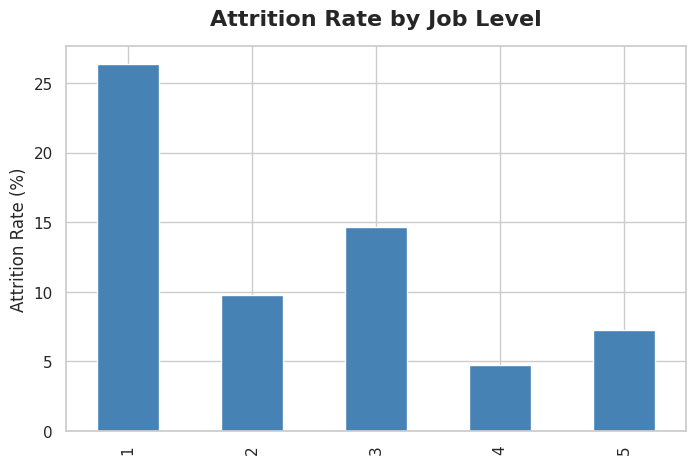

In [ ]:
plt.figure(figsize=(8,5))

joblevel_rate.plot(
    kind="bar",
    color="steelblue"
)

chart_title("Attrition Rate by Job Level")

plt.ylabel("Attrition Rate (%)")

plt.show()

statistical test

In [ ]:
contingency_table = pd.crosstab(
    df["JobLevel"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 72.5290
P-value : 0.0000


In [ ]:
df.groupby("JobLevel")["MonthlyIncome"]\
    .mean()\
    .round()

,MonthlyIncome
JobLevel,
1,2787.0
2,5502.0
3,9817.0
4,15504.0
5,19192.0


In [ ]:
df.groupby("JobLevel")["JobSatisfaction"]\
    .mean()\
    .round(2)

,JobSatisfaction
JobLevel,
1,2.72
2,2.76
3,2.68
4,2.73
5,2.74


In [ ]:
df.groupby("JobLevel")["YearsAtCompany"]\
    .mean()\
    .round(1)

,YearsAtCompany
JobLevel,
1,3.9
2,6.8
3,9.4
4,13.9
5,15.1


In [ ]:
df.groupby("JobLevel")["Age"]\
    .mean()\
    .round(1)

,Age
JobLevel,
1,32.5
2,36.6
3,40.1
4,47.5
5,47.8


In [ ]:
joblevel_ot = (
    df.groupby("JobLevel")["OverTime"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

joblevel_ot

,OverTime
JobLevel,
1,28.73
2,27.34
3,28.90
4,31.13
5,26.09


In [ ]:
df.groupby("JobLevel")["YearsSinceLastPromotion"]\
    .mean()\
    .round(2)

,YearsSinceLastPromotion
JobLevel,
1,1.19
2,1.89
3,3.35
4,4.84
5,4.59


In [ ]:
#Job Level Summary Table
joblevel_summary = (
    df.groupby("JobLevel")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgAge=("Age","mean"),
          OvertimeRate=("OverTime",
                        lambda x:(x=="Yes").mean()*100),
          AvgYearsSincePromotion=("YearsSinceLastPromotion","mean")
      )
      .round(2)
      .sort_index()
)

joblevel_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgYearsAtCompany,AvgAge,OvertimeRate,AvgYearsSincePromotion
JobLevel,,,,,,,,
1,543,26.34,2786.92,2.72,3.93,32.52,28.73,1.19
2,534,9.74,5502.28,2.76,6.75,36.60,27.34,1.89
3,218,14.68,9817.25,2.68,9.38,40.09,28.90,3.35
4,106,4.72,15503.78,2.73,13.89,47.54,31.13,4.84
5,69,7.25,19191.83,2.74,15.13,47.75,26.09,4.59


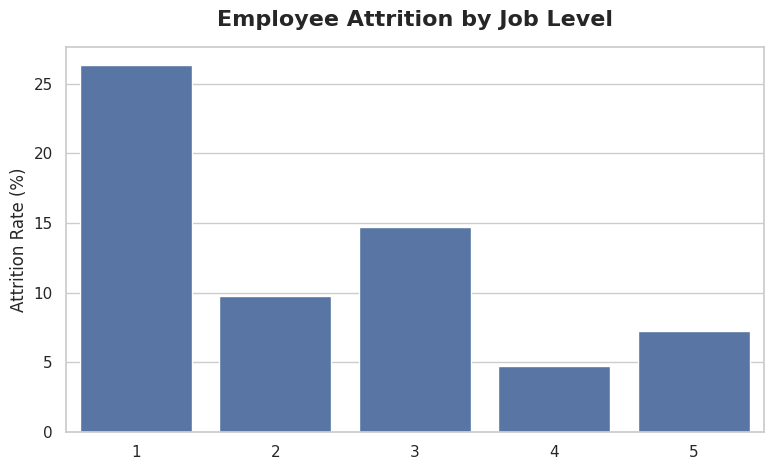

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=joblevel_summary.reset_index(),
    x="JobLevel",
    y="AttritionRate"
)

chart_title("Employee Attrition by Job Level")

plt.ylabel("Attrition Rate (%)")

plt.show()

## Business Insight

The organization's workforce is heavily concentrated in the lower career levels.

Employees at **Job Level 1 (36.9%)** and **Job Level 2 (36.3%)** account for more than **73% of the entire workforce**, indicating that the company relies primarily on entry-level and junior employees.

Employee attrition varies considerably across job levels.

Job Level 1 records the highest attrition rate at **26.3%**, meaning that more than one in every four employees at the entry level leaves the organization. Attrition then drops substantially at Job Level 2 (9.7%), increases moderately at Job Level 3 (14.7%), and remains relatively low for senior positions at Job Levels 4 (4.7%) and 5 (7.3%).

The Chi-square test confirms a statistically significant relationship between job level and employee attrition (**χ² = 72.5290, p < 0.001**), indicating that employee turnover differs significantly across career levels.

These findings suggest that employees at lower organizational levels are substantially more vulnerable to leaving the company than those in senior positions.

## Business Impact

The concentration of employee turnover within lower job levels presents both operational and financial challenges.

High attrition among entry-level employees increases recruitment costs, onboarding expenses, training investments, and productivity losses as organizations continually replace inexperienced staff.

Given that Job Level 1 represents more than one-third of the workforce, persistent turnover at this level has the potential to disrupt business continuity, increase managerial workload, and reduce organizational efficiency.

Conversely, the low attrition observed among senior employees indicates that experienced staff are generally retained, preserving leadership continuity and organizational knowledge.

## Business Recommendation

Management should prioritize retention initiatives for employees in Job Level 1, where turnover risk is highest.

Recommended actions include:

- Develop structured onboarding and early-career development programmes.
- Create transparent career progression pathways from Job Level 1 to higher levels.
- Review compensation and benefits for entry-level employees.
- Expand mentoring and coaching initiatives.
- Conduct regular engagement surveys during employees' first three years.
- Strengthen recognition programmes for junior employees to improve commitment and retention.

Retention investments at Job Level 1 are likely to generate the greatest return by reducing replacement costs and improving workforce stability.

### Executive Takeaway

Employee attrition is primarily concentrated among lower job levels.

As employees progress within the organization through higher compensation, greater experience, and longer tenure, the likelihood of leaving decreases considerably.

This suggests that career progression plays a critical role in employee retention.

### Analyst's Note

Job level appears to capture several important workforce characteristics simultaneously, including employee age, organizational tenure, compensation, and career maturity.

Future analyses will examine whether factors such as overtime, business travel, work-life balance, and promotion opportunities further explain the elevated attrition observed among lower-level employees.

### Key Statistics

| Metric | Value |
|---------|------:|
| Largest Workforce | Job Level 1 (36.9%) |
| Highest Attrition | Job Level 1 (26.3%) |
| Lowest Attrition | Job Level 4 (4.7%) |
| Chi-square Statistic | 72.5290 |
| P-value | <0.001 |
| Statistical Significance | Yes |
| Business Conclusion | Job level is strongly associated with employee attrition. |

# **BUSINESS TRAVEL ANALYSIS**
## Business Question

### Does the frequency of business travel influence employee attrition?

Business travel is often associated with increased workload, time away from family, fatigue, and work-life balance challenges.

This analysis investigates whether employees who travel more frequently are more likely to leave the organization compared to employees who travel less or not at all.

### Why This Matters

Frequent travel can increase stress and reduce work-life balance.

Understanding the relationship between travel frequency and employee attrition enables management to:

- Identify whether travel contributes to employee turnover.
- Evaluate workload distribution.
- Improve employee wellbeing.
- Develop travel policies that reduce burnout while maintaining business performance.

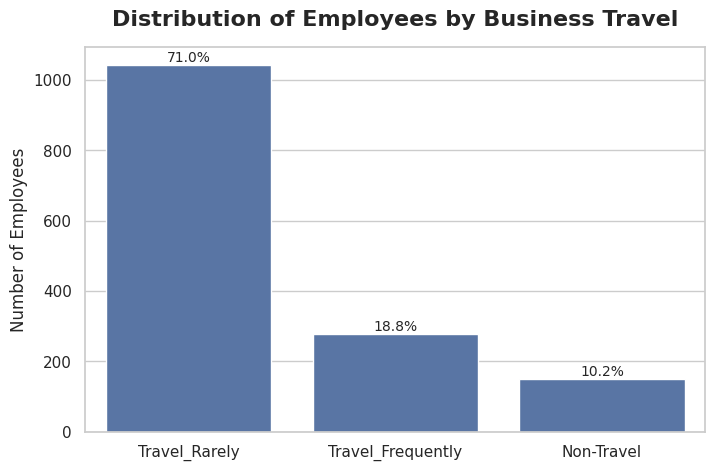

In [ ]:
#Distribution of Employees by Business Travel
plt.figure(figsize=(8,5))

order = df["BusinessTravel"].value_counts().index

ax = sns.countplot(
    data=df,
    x="BusinessTravel",
    order=order
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Business Travel")

plt.ylabel("Number of Employees")

plt.show()

In [ ]:
#attritin by business travel
travel_attrition = (
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

travel_attrition

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


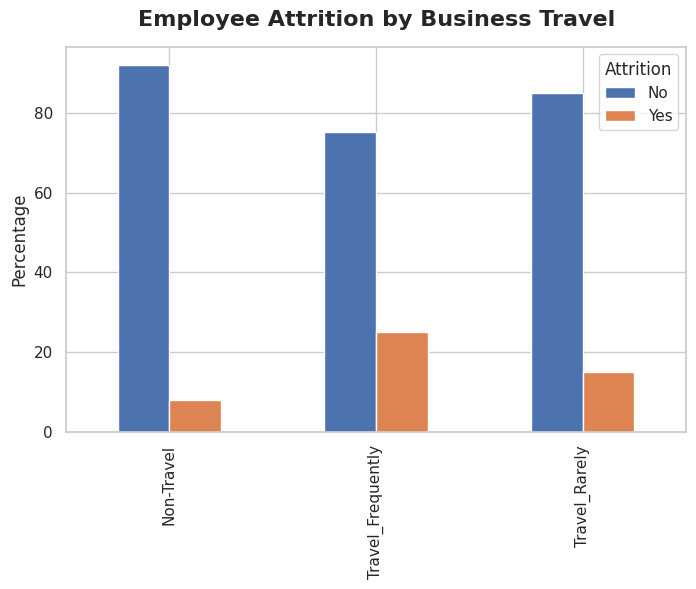

In [ ]:
travel_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

chart_title("Employee Attrition by Business Travel")

plt.ylabel("Percentage")

plt.show()

In [ ]:
travel_rate = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
      .sort_values(ascending=False)
)

travel_rate

,Attrition
BusinessTravel,
Travel_Frequently,24.91
Travel_Rarely,14.96
Non-Travel,8.00


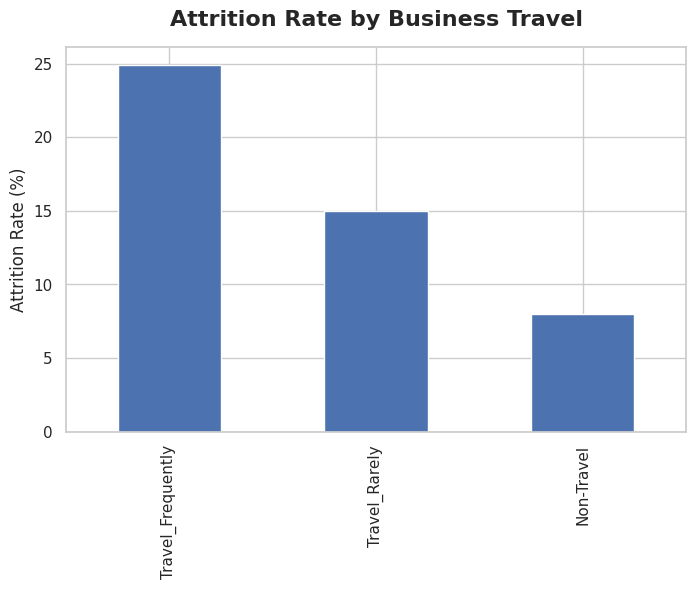

In [ ]:
plt.figure(figsize=(8,5))

travel_rate.plot(kind="bar")

chart_title("Attrition Rate by Business Travel")

plt.ylabel("Attrition Rate (%)")

plt.show()

statistica test

In [ ]:
contingency_table = pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 24.1824
P-value : 0.0000


In [ ]:
df.groupby("BusinessTravel")["MonthlyIncome"]\
.mean()\
.round()

,MonthlyIncome
BusinessTravel,
Non-Travel,6262.0
Travel_Frequently,6194.0
Travel_Rarely,6620.0


In [ ]:
df.groupby("BusinessTravel")["JobSatisfaction"]\
.mean()\
.round(2)

,JobSatisfaction
BusinessTravel,
Non-Travel,2.79
Travel_Frequently,2.79
Travel_Rarely,2.70


In [ ]:
df.groupby("BusinessTravel")["YearsAtCompany"]\
.mean()\
.round(1)

,YearsAtCompany
BusinessTravel,
Non-Travel,7.1
Travel_Frequently,7.2
Travel_Rarely,6.9


In [ ]:
df.groupby("BusinessTravel")["Age"]\
.mean()\
.round(1)

,Age
BusinessTravel,
Non-Travel,36.6
Travel_Frequently,36.5
Travel_Rarely,37.1


In [ ]:
travel_ot = (
    df.groupby("BusinessTravel")["OverTime"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

travel_ot

,OverTime
BusinessTravel,
Non-Travel,23.33
Travel_Frequently,31.05
Travel_Rarely,28.28


In [ ]:
df.groupby("BusinessTravel")["WorkLifeBalance"]\
.mean()\
.round(2)

,WorkLifeBalance
BusinessTravel,
Non-Travel,2.77
Travel_Frequently,2.78
Travel_Rarely,2.76


In [ ]:
travel_summary = (
    df.groupby("BusinessTravel")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgAge=("Age","mean"),
          OvertimeRate=("OverTime",
                        lambda x:(x=="Yes").mean()*100),
          AvgWorkLifeBalance=("WorkLifeBalance","mean")
      )
      .round(2)
      .sort_values("AttritionRate", ascending=False)
)

travel_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgYearsAtCompany,AvgAge,OvertimeRate,AvgWorkLifeBalance
BusinessTravel,,,,,,,,
Travel_Frequently,277,24.91,6193.73,2.79,7.17,36.45,31.05,2.78
Travel_Rarely,1043,14.96,6619.71,2.70,6.94,37.09,28.28,2.76
Non-Travel,150,8.00,6261.95,2.79,7.15,36.62,23.33,2.77


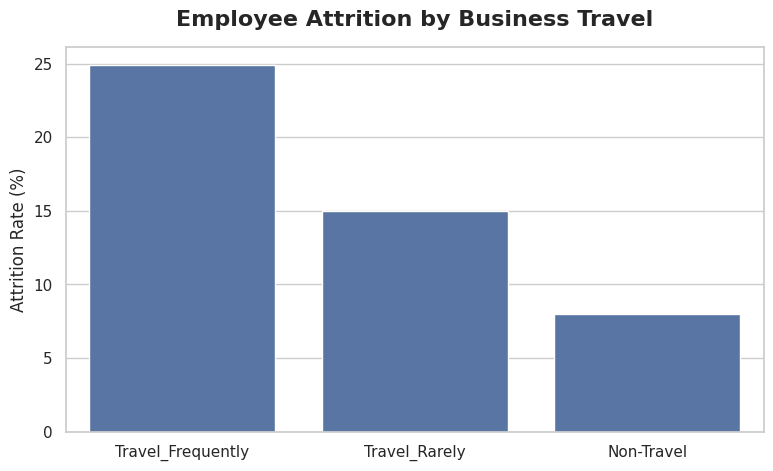

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=travel_summary.reset_index(),
    x="BusinessTravel",
    y="AttritionRate"
)

chart_title("Employee Attrition by Business Travel")

plt.ylabel("Attrition Rate (%)")

plt.show()

## Business Insight

The majority of employees (**71.0%**) travel rarely for work, while **18.8%** travel frequently and **10.2%** do not travel at all.

Employee attrition varies considerably across these travel categories.

Employees who **travel frequently** experience the highest attrition rate at **24.9%**, followed by employees who travel rarely (**15.0%**). Employees who do not travel record the lowest attrition rate at **8.0%**.

The Chi-square test indicates a statistically significant association between business travel frequency and employee attrition (**χ² = 24.1824, p < 0.001**).

These findings suggest that employees with greater travel responsibilities are significantly more likely to leave the organization than employees with little or no travel requirements.

## Business Impact

Frequent business travel may contribute to employee turnover through increased work demands, time away from family, travel fatigue, and reduced work-life integration.

Although employees who travel frequently represent less than one-fifth of the workforce, they experience the highest turnover, increasing recruitment costs and creating operational challenges for travel-intensive roles.

Reducing unnecessary travel and improving support for travelling employees could help improve workforce stability without compromising business operations.

## Business Recommendation

Management should review travel-intensive roles to determine whether travel requirements can be optimized.

Recommended actions include:

- Reduce unnecessary business travel through virtual collaboration where appropriate.
- Rotate travel responsibilities among qualified employees.
- Provide additional support and wellbeing initiatives for frequent travellers.
- Review travel allowances and reimbursement policies.
- Monitor workload and recovery periods following extended business trips.
- Include travel frequency as part of employee retention risk assessments.

### Executive Takeaway

Business travel is a significant predictor of employee attrition.

Employees who travel frequently are substantially more likely to leave the organization, suggesting that travel-related demands should be considered when designing employee wellbeing and retention strategies.

### Key Statistics

| Metric | Value |
|---------|------:|
| Largest Group | Travel Rarely (71.0%) |
| Highest Attrition | Travel Frequently (24.9%) |
| Lowest Attrition | Non-Travel (8.0%) |
| Chi-square Statistic | 24.1824 |
| P-value | <0.001 |
| Statistical Significance | Yes |
| Business Conclusion | Business travel is significantly associated with employee attrition. |

# **OVERTIME ANALYSIS**
## Business Question

### Does working overtime significantly influence employee attrition?

Overtime is often associated with increased workload, burnout, reduced work-life balance, and employee stress.

This analysis investigates whether employees who work overtime are more likely to leave the organization compared to employees who do not work overtime.

### Why This Matters

Employee overtime directly affects productivity, wellbeing, and retention.

Understanding the relationship between overtime and attrition enables management to:

- Identify whether excessive workload contributes to turnover.
- Improve workforce planning.
- Reduce employee burnout.
- Optimize staffing levels.
- Develop healthier work schedules.

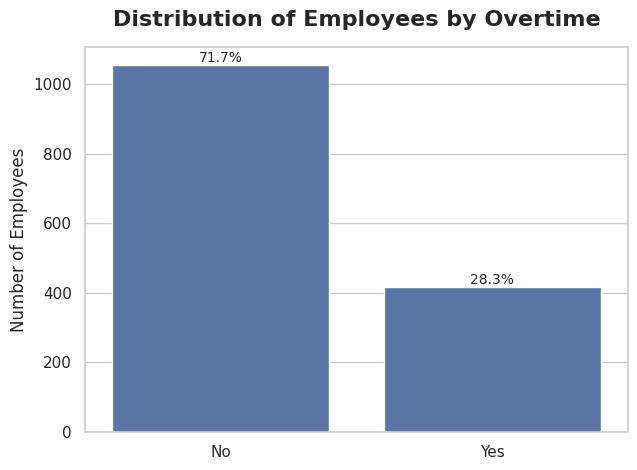

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="OverTime",
    order=["No","Yes"]
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Overtime")

plt.ylabel("Number of Employees")

plt.show()

In [ ]:
overtime_attrition = (
    pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


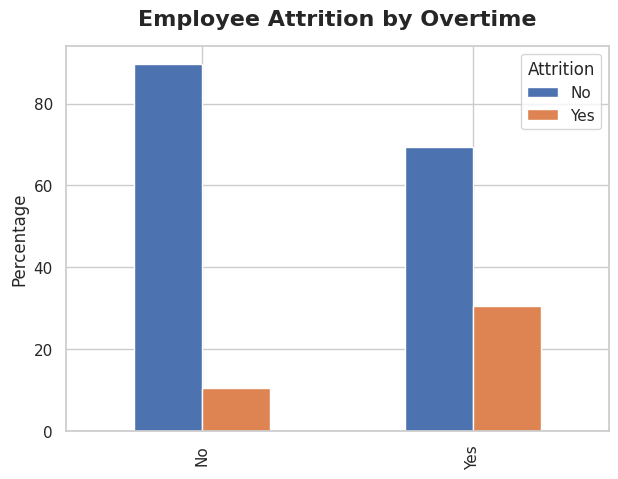

In [ ]:
overtime_attrition.plot(
    kind="bar",
    figsize=(7,5)
)

chart_title("Employee Attrition by Overtime")

plt.ylabel("Percentage")

plt.show()

In [ ]:
overtime_rate = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

overtime_rate

,Attrition
OverTime,
No,10.44
Yes,30.53


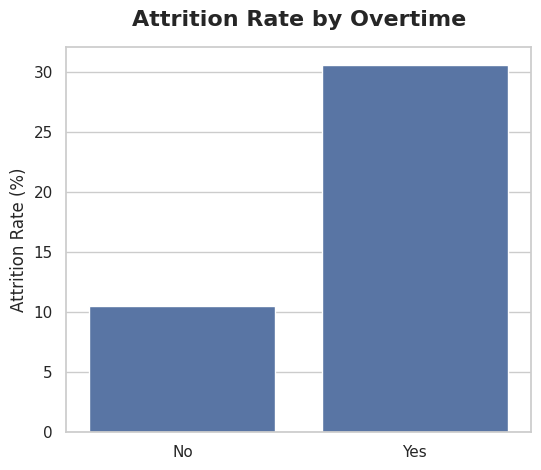

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=overtime_rate.reset_index(),
    x="OverTime",
    y="Attrition"
)

chart_title("Attrition Rate by Overtime")

plt.ylabel("Attrition Rate (%)")

plt.show()

statistical test

In [ ]:
contingency_table = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value : {p:.4f}")

Chi-square Statistic : 87.5643
P-value : 0.0000


In [ ]:
df.groupby("OverTime")["MonthlyIncome"]\
.mean()\
.round()

,MonthlyIncome
OverTime,
No,6485.0
Yes,6549.0


In [ ]:
df.groupby("OverTime")["JobSatisfaction"]\
.mean()\
.round(2)

,JobSatisfaction
OverTime,
No,2.71
Yes,2.77


In [ ]:
df.groupby("OverTime")["WorkLifeBalance"]\
.mean()\
.round(2)

,WorkLifeBalance
OverTime,
No,2.77
Yes,2.73


In [ ]:
df.groupby("OverTime")["YearsAtCompany"]\
.mean()\
.round(1)

,YearsAtCompany
OverTime,
No,7.1
Yes,6.9


In [ ]:
df.groupby("OverTime")["Age"]\
.mean()\
.round(1)

,Age
OverTime,
No,36.8
Yes,37.3


In [ ]:
#Average Monthly Income by Overtime and Attrition
pd.pivot_table(
    df,
    values="MonthlyIncome",
    index="OverTime",
    columns="Attrition",
    aggfunc="mean"
).round()

Attrition,No,Yes
OverTime,,
No,6670.0,4899.0
Yes,7365.0,4690.0


In [ ]:
#department vs overtime
department_ot = (
    pd.crosstab(
        df["Department"],
        df["OverTime"],
        normalize="index"
    ) * 100
)

department_ot

OverTime,No,Yes
Department,,
Human Resources,73.015873,26.984127
Research & Development,71.800208,28.199792
Sales,71.300448,28.699552


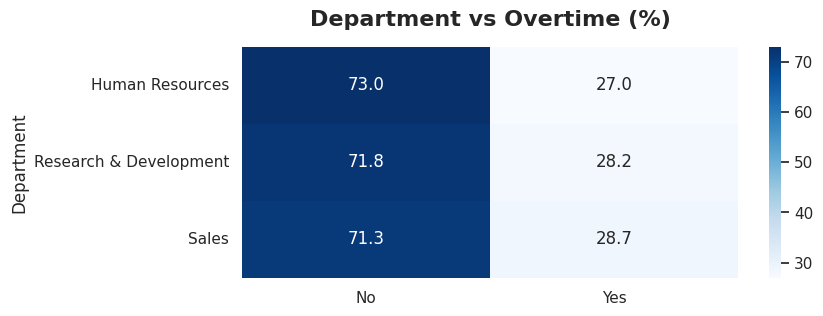

In [ ]:
plt.figure(figsize=(8,3))

sns.heatmap(
    department_ot,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

chart_title("Department vs Overtime (%)")

plt.show()

In [ ]:
#job role vs overtime
jobrole_ot = (
    pd.crosstab(
        df["JobRole"],
        df["OverTime"],
        normalize="index"
    ) * 100
)

jobrole_ot

OverTime,No,Yes
JobRole,,
Healthcare Representative,71.755725,28.244275
Human Resources,75.000000,25.000000
Laboratory Technician,76.061776,23.938224
Manager,73.529412,26.470588
Manufacturing Director,73.103448,26.896552
Research Director,71.250000,28.750000
Research Scientist,66.780822,33.219178
Sales Executive,71.165644,28.834356
Sales Representative,71.084337,28.915663


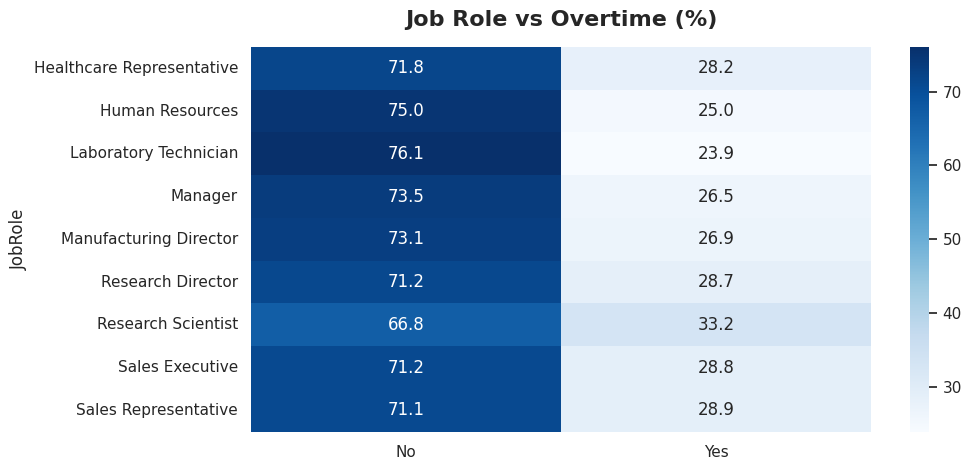

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    jobrole_ot,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

chart_title("Job Role vs Overtime (%)")

plt.show()

In [ ]:
overtime_summary = (
    df.groupby("OverTime")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          AvgWorkLifeBalance=("WorkLifeBalance","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgAge=("Age","mean")
      )
      .round(2)
)

overtime_summary

,Employees,AttritionRate,AvgIncome,AvgJobSatisfaction,AvgWorkLifeBalance,AvgYearsAtCompany,AvgAge
OverTime,,,,,,,
No,1054,10.44,6484.93,2.71,2.77,7.05,36.76
Yes,416,30.53,6548.55,2.77,2.73,6.89,37.33


In [ ]:
#Attrition by Overtime and Job Level
ot_joblevel = (
    pd.crosstab(
        [df["JobLevel"], df["OverTime"]],
        df["Attrition"],
        normalize="index"
    ) * 100
)

ot_joblevel

Attrition                 No        Yes
JobLevel OverTime                      
1        No        84.237726  15.762274
         Yes       47.435897  52.564103
2        No        93.298969   6.701031
         Yes       82.191781  17.808219
3        No        87.741935  12.258065
         Yes       79.365079  20.634921
4        No        97.260274   2.739726
         Yes       90.909091   9.090909
5        No        96.078431   3.921569
         Yes       83.333333  16.666667

## Business Insight

Approximately **71.7%** of employees do not work overtime, while **28.3%** regularly work overtime.

Employee attrition differs substantially between these two groups.

Employees who work overtime experience an attrition rate of **30.5%**, compared to only **10.4%** among employees who do not work overtime.

The Chi-square test confirms a statistically significant relationship between overtime and employee attrition (**χ² = 87.5643, p < 0.001**).

Employees working overtime are nearly **three times more likely** to leave the organization than employees who do not work overtime, making overtime one of the strongest predictors of employee turnover in this study.

## Business Impact

The findings suggest that excessive workload is a major contributor to employee turnover.

Although fewer than one-third of employees work overtime, this group contributes disproportionately to employee attrition.

High overtime levels increase recruitment costs, reduce workforce stability, lower organizational productivity, and increase the likelihood of burnout among critical employees.

Managing overtime effectively could significantly improve employee retention while reducing the financial costs associated with replacing experienced staff.

## Business Recommendation

Management should prioritize reducing excessive overtime through strategic workforce planning.

Recommended actions include:

- Recruit additional staff where workload consistently exceeds capacity.
- Monitor overtime hours at both departmental and individual levels.
- Implement workload balancing across teams.
- Encourage managers to identify employees at risk of burnout.
- Introduce flexible work arrangements where operationally feasible.
- Incorporate overtime as a key indicator within employee retention monitoring systems.

### Executive Takeaway

Overtime is one of the strongest predictors of employee attrition.

Employees who regularly work overtime are significantly more likely to resign, indicating that workload management should be a central component of the organization's employee retention strategy.

### Analyst's Note

While overtime demonstrates a strong statistical relationship with employee attrition, it may also interact with other organizational factors such as job role, business travel, and department.

Future predictive modeling will determine the relative importance of overtime alongside other employee characteristics when predicting employee turnover.

### Key Statistics

| Metric | Value |
|---------|------:|
| Employees Working Overtime | 28.3% |
| Employees Not Working Overtime | 71.7% |
| Attrition (Overtime) | **30.53%** |
| Attrition (No Overtime) | **10.44%** |
| Chi-square Statistic | 87.5643 |
| P-value | <0.001 |
| Statistical Significance | Yes |
| Business Conclusion | Overtime is a major predictor of employee attrition. |

# **MONTHLY INCOME ANALYSIS**
# Monthly Income Analysis

## Business Question

Does employee compensation influence employee attrition?

Compensation is one of the primary factors organizations evaluate when investigating employee turnover.

This analysis examines whether employees with lower salaries are more likely to leave the organization compared to higher-paid employees.

## Why This Matters

Understanding the relationship between salary and employee attrition helps management:

- Identify whether compensation is driving turnover.
- Improve salary structures.
- Prioritize salary reviews.
- Reduce employee turnover through competitive compensation.
- Allocate compensation budgets effectively.

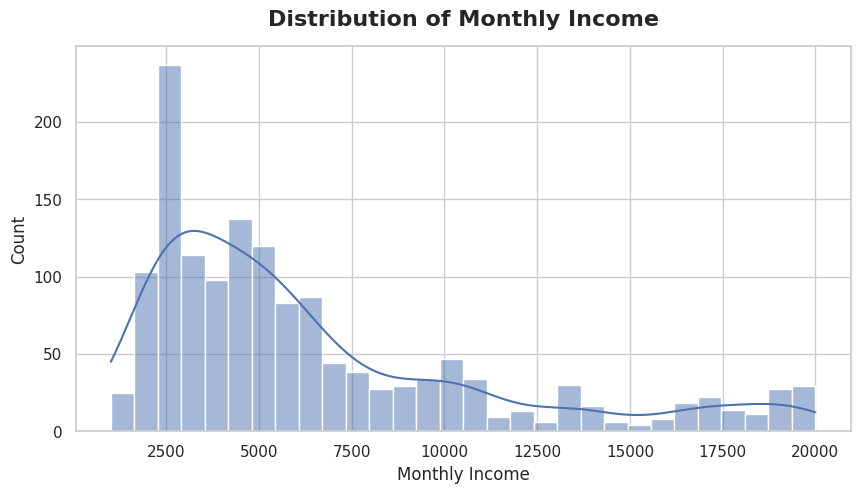

In [ ]:
#DISTRIBUTION OF MONTHLY INCOME
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=30,
    kde=True
)

chart_title("Distribution of Monthly Income")

plt.xlabel("Monthly Income")

plt.show()

In [ ]:
#SUMMARY STATISTIICS
df["MonthlyIncome"].describe().round(2)

,MonthlyIncome
count,1470.00
mean,6502.93
std,4707.96
min,1009.00
25%,2911.00
50%,4919.00
75%,8379.00
max,19999.00


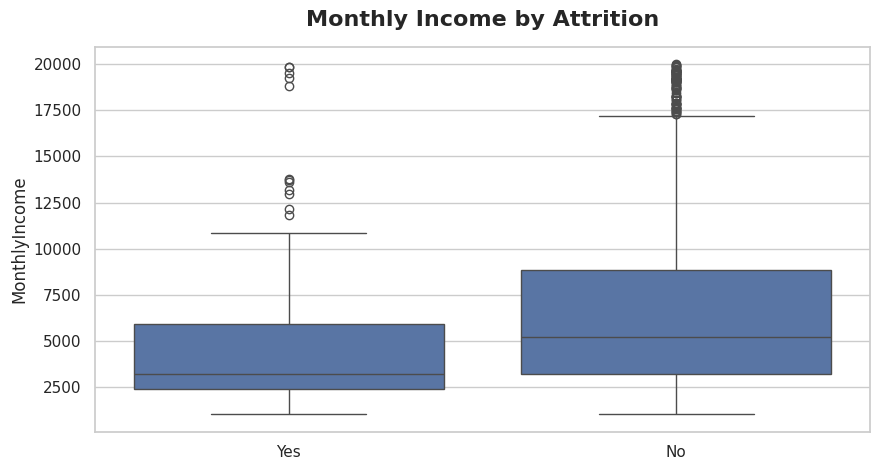

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

chart_title("Monthly Income by Attrition")

plt.show()

STATISTICAL TEST

In [ ]:
from scipy.stats import ttest_ind

stay = df[df["Attrition"]=="No"]["MonthlyIncome"]

leave = df[df["Attrition"]=="Yes"]["MonthlyIncome"]

t_stat, p = ttest_ind(stay, leave)

print("T-statistic:", round(t_stat,4))
print("P-value:", round(p,4))

T-statistic: 6.2039
P-value: 0.0


In [ ]:
#INCOME BANDS
df["IncomeBand"] = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["IncomeBand"].value_counts()

,count
IncomeBand,
Low,369
Very High,368
High,367
Medium,366


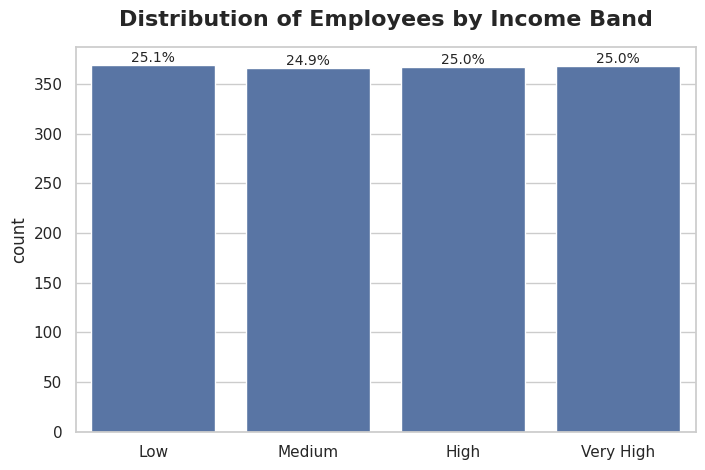

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="IncomeBand",
    order=["Low","Medium","High","Very High"]
)

add_percentage_labels(ax)

chart_title("Distribution of Employees by Income Band")

plt.show()

In [ ]:
#ATTRITION BY BAND
income_attrition = (
    pd.crosstab(
        df["IncomeBand"],
        df["Attrition"],
        normalize="index"
    ) *100
)

income_attrition

Attrition,No,Yes
IncomeBand,,
Low,70.731707,29.268293
Medium,85.792350,14.207650
High,89.373297,10.626703
Very High,89.673913,10.326087


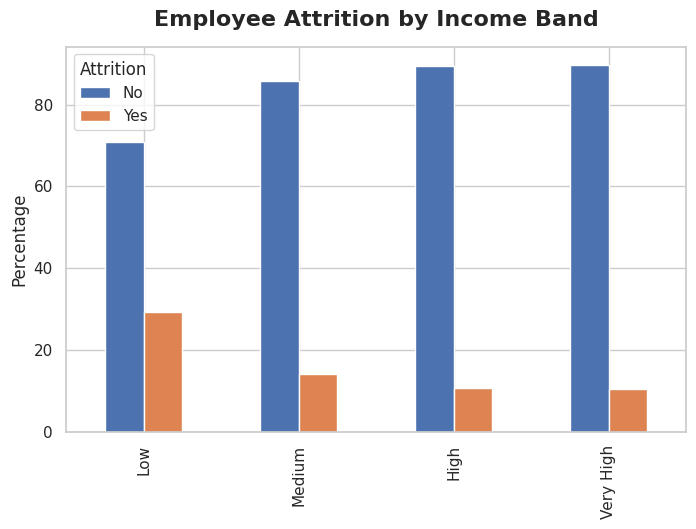

In [ ]:
income_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

chart_title("Employee Attrition by Income Band")

plt.ylabel("Percentage")

plt.show()

In [ ]:
income_rate = (
    df.groupby("IncomeBand")["Attrition"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

income_rate

,Attrition
IncomeBand,
Low,29.27
Medium,14.21
High,10.63
Very High,10.33


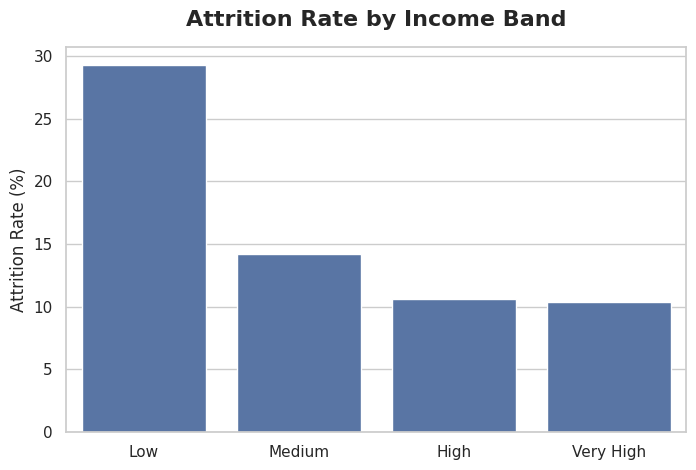

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=income_rate.reset_index(),
    x="IncomeBand",
    y="Attrition",
    order=["Low","Medium","High","Very High"]
)

chart_title("Attrition Rate by Income Band")

plt.ylabel("Attrition Rate (%)")

plt.show()

In [ ]:
#AVERAGE AGE
df.groupby("IncomeBand")["Age"].mean().round(1)

,Age
IncomeBand,
Low,32.2
Medium,34.6
High,37.5
Very High,43.4


In [ ]:
#Average Years at Company
df.groupby("IncomeBand")["YearsAtCompany"].mean().round(1)

,YearsAtCompany
IncomeBand,
Low,3.7
Medium,5.7
High,7.1
Very High,11.6


In [ ]:
#Average Job Satisfaction
df.groupby("IncomeBand")["JobSatisfaction"].mean().round(2)

,JobSatisfaction
IncomeBand,
Low,2.75
Medium,2.68
High,2.80
Very High,2.69


In [ ]:
#average overtime rate
income_ot = (
    df.groupby("IncomeBand")["OverTime"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

income_ot

,OverTime
IncomeBand,
Low,28.73
Medium,26.23
High,29.70
Very High,28.53


In [ ]:
#summary
income_summary = (
    df.groupby("IncomeBand")
      .agg(
          Employees=("EmployeeNumber","count"),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100),
          AvgIncome=("MonthlyIncome","mean"),
          AvgAge=("Age","mean"),
          AvgYearsAtCompany=("YearsAtCompany","mean"),
          AvgJobSatisfaction=("JobSatisfaction","mean"),
          OvertimeRate=("OverTime",
                        lambda x:(x=="Yes").mean()*100)
      )
      .round(2)
)

income_summary

,Employees,AttritionRate,AvgIncome,AvgAge,AvgYearsAtCompany,AvgJobSatisfaction,OvertimeRate
IncomeBand,,,,,,,
Low,369,29.27,2354.13,32.23,3.66,2.75,28.73
Medium,366,14.21,3964.10,34.57,5.69,2.68,26.23
High,367,10.63,6181.74,37.50,7.07,2.80,29.70
Very High,368,10.33,13508.35,43.40,11.61,2.69,28.53


In [ ]:
#income band by job level
income_joblevel = pd.crosstab(
    [df["IncomeBand"], df["JobLevel"]],
    df["Attrition"],
    normalize="index"
) * 100

income_joblevel

Attrition                   No        Yes
IncomeBand JobLevel                      
Low        1         69.943820  30.056180
           2         92.307692   7.692308
Medium     1         80.874317  19.125683
           2         90.710383   9.289617
High       1         75.000000  25.000000
           2         90.614887   9.385113
           3         83.333333  16.666667
Very High  2         82.758621  17.241379
           3         85.975610  14.024390
           4         95.283019   4.716981
           5         92.753623   7.246377

# **Executive Summary**

The analysis investigated whether employee compensation influences employee attrition. Results indicate that salary is a significant predictor of turnover. Employees earning lower salaries were substantially more likely to leave the organization than higher-paid employees. Statistical testing confirmed that the difference in income between employees who stayed and those who left is highly significant.

# 1. Distribution of Monthly Income
Business Insight

The distribution of monthly income is positively skewed (right-skewed), indicating that most employees earn salaries in the lower to middle income range, while a relatively small number of employees occupy higher-paying positions.

Key observations include:

The average monthly income is 6,503, while the median is 4,919, indicating that a small number of high-income employees pull the average upward.
Approximately half of the workforce earns below 5,000 per month.
Only a small proportion of employees earn salaries approaching 20,000, representing senior leadership or highly specialized positions.
Business Implication

The organization has a traditional organizational structure, where the majority of employees occupy operational and mid-level positions, with relatively few senior management roles receiving substantially higher compensation.

# 2. Statistical Test
Results
T-statistic = 6.2039
P-value < 0.001
Interpretation

Because the p-value is effectively zero, we reject the null hypothesis.

There is a statistically significant difference in monthly income between employees who leave and those who remain.

Monthly income is therefore strongly associated with employee attrition.

# 3. Distribution of Employees Across Income Bands
Business Insight

Employees are almost perfectly distributed across the four income bands.

Income Band	Employees
Low	25.1%
Medium	24.9%
High	25.0%
Very High	25.0%
Interpretation

Using quartiles creates balanced groups, making comparisons fair and reducing bias caused by unequal sample sizes.

# 4. Attrition by Income Band
Results
Income Band	Attrition Rate
Low	29.27%
Medium	14.21%
High	10.63%
Very High	10.33%
Business Insight

This chart reveals one of the clearest trends in the entire project.

Employee attrition decreases substantially as income increases.

Employees in the lowest income band experience an attrition rate of 29.3%, nearly three times the rate observed among employees in the High and Very High income bands.

The most dramatic reduction occurs between the Low and Medium income groups, where attrition falls by approximately 15 percentage points.

Beyond the High income band, attrition stabilizes at around 10%, suggesting that once employees reach a competitive compensation level, further salary increases have a diminishing effect on retention.

Business Implication

Compensation appears to be a critical retention factor for lower-income employees. Addressing salary competitiveness for entry-level and lower-paid roles is likely to yield the greatest reduction in turnover.

# 5. Age by Income Band
Income Band	Average Age
Low	32.2
Medium	34.6
High	37.5
Very High	43.4
Business Insight

Higher income bands are associated with older employees.

This reflects natural career progression, where employees gain experience, promotions, and salary increases over time.

The youngest employees are concentrated in the lowest salary band, which also experiences the highest turnover.

Business Implication

Young professionals in entry-level positions represent the organization's most vulnerable retention segment.

# 6. Years at Company
Income Band	Years
Low	3.7
Medium	5.7
High	7.1
Very High	11.6
Business Insight

Employee tenure increases consistently with salary.

Employees earning the highest salaries have remained with the company for more than 11 years on average, compared to fewer than 4 years for employees in the lowest income band.

This suggests that employees who stay longer are rewarded with career advancement and higher compensation.

Business Implication

Early-career employees are leaving before realizing long-term career growth and salary progression, representing a loss of future organizational talent.

# 7. Job Satisfaction
Income Band	Job Satisfaction
Low	2.75
Medium	2.68
High	2.80
Very High	2.69
Business Insight

Job satisfaction scores remain relatively consistent across all income levels.

Differences are small and do not suggest a strong relationship between salary and reported job satisfaction.

Business Implication

While compensation influences retention, employee satisfaction appears to depend on additional workplace factors such as leadership, career development, recognition, and organizational culture.

# 8. Overtime Rate
Income Band	Overtime
Low	28.73%
Medium	26.23%
High	29.70%
Very High	28.53%
Business Insight

Overtime participation is relatively consistent across all income groups, varying only slightly between 26% and 30%.

This suggests overtime is broadly distributed across the organization and is not concentrated among lower-paid employees.

Business Implication

The elevated attrition observed among low-income employees cannot be attributed solely to higher overtime demands. Compensation remains a stronger explanatory factor for turnover in this analysis.

# 9. Income Band Summary
Key Findings
Low-income employees exhibit the highest attrition rate (29.27%).
Attrition declines sharply as compensation increases.
Older employees generally earn higher salaries and remain with the organization longer.
Tenure nearly triples between the lowest and highest income bands.
Job satisfaction remains relatively stable regardless of salary.
Overtime rates are similar across all income groups, indicating that compensation—not overtime—is the more influential retention factor in this context.

# 10. Income Band × Job Level
Business Insight

This analysis provides an important nuance by examining salary within different job levels.

Key observations include:

Job Level 1 employees in the Low income band experience a 30.06% attrition rate, confirming that entry-level, low-paid employees are the most vulnerable group.
Within Job Level 2, attrition is considerably lower across all income bands (around 8–17%), suggesting that even modest career progression significantly improves retention.
Employees in higher job levels (4 and 5) exhibit very low attrition regardless of income band, reinforcing the stabilizing effects of seniority, higher compensation, and career advancement.
Business Implication

The findings suggest that career progression amplifies the benefits of higher compensation. Simply increasing salaries may not fully address turnover unless employees also perceive clear advancement opportunities. Retention efforts should therefore focus on accelerating development pathways for early-career employees while ensuring competitive entry-level pay.

# **Executive Recommendations**
1. Review Entry-Level Compensation

Employees in the lowest income band are nearly three times more likely to leave than those in higher income bands. Benchmark entry-level salaries against market rates and adjust where necessary to improve competitiveness.

2. Strengthen Early-Career Development

Provide structured onboarding, mentoring, and defined career progression for employees in Job Level 1 to reduce early turnover and build long-term engagement.

3. Implement Retention Incentives

Introduce targeted retention initiatives for high-performing, lower-income employees, such as performance-based bonuses, salary progression plans, and internal promotion opportunities.

4. Focus Beyond Salary

Since job satisfaction remains relatively stable across income levels, retention strategies should also address leadership quality, recognition, professional development, and workplace culture.

5. Monitor High-Risk Employee Segments

Develop dashboards to continuously monitor attrition among low-income, early-tenure, and entry-level employees. Early identification enables proactive intervention before employees resign.

# **Correlation & Relationship Analysis**

# Correlation & Relationship Analysis

## Business Objective

After examining individual factors influencing employee attrition, the next step is to understand how employee characteristics relate to one another.

This phase identifies hidden relationships among continuous variables, highlights potential drivers of employee turnover, and provides valuable insights for predictive modeling.

In [ ]:
numerical_cols = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "Education",
    "EnvironmentSatisfaction",
    "HourlyRate",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

In [ ]:
#Correlation Matrix
corr = df[numerical_cols].corr()

corr.round(2)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,0.01,-0.00,0.21,0.01,0.02,0.03,0.51,-0.00,0.50,0.03,0.30,0.00,0.00,0.05,0.04,0.68,-0.02,-0.02,0.31,0.21,0.22,0.20
DailyRate,0.01,1.00,-0.00,-0.02,0.02,0.02,0.05,0.00,0.03,0.01,-0.03,0.04,0.02,0.00,0.01,0.04,0.01,0.00,-0.04,-0.03,0.01,-0.03,-0.03
DistanceFromHome,-0.00,-0.00,1.00,0.02,-0.02,0.03,0.01,0.01,-0.00,-0.02,0.03,-0.03,0.04,0.03,0.01,0.04,0.00,-0.04,-0.03,0.01,0.02,0.01,0.01
Education,0.21,-0.02,0.02,1.00,-0.03,0.02,0.04,0.10,-0.01,0.09,-0.03,0.13,-0.01,-0.02,-0.01,0.02,0.15,-0.03,0.01,0.07,0.06,0.05,0.07
EnvironmentSatisfaction,0.01,0.02,-0.02,-0.03,1.00,-0.05,-0.01,0.00,-0.01,-0.01,0.04,0.01,-0.03,-0.03,0.01,0.00,-0.00,-0.02,0.03,0.00,0.02,0.02,-0.00
HourlyRate,0.02,0.02,0.03,0.02,-0.05,1.00,0.04,-0.03,-0.07,-0.02,-0.02,0.02,-0.01,-0.00,0.00,0.05,-0.00,-0.01,-0.00,-0.02,-0.02,-0.03,-0.02
JobInvolvement,0.03,0.05,0.01,0.04,-0.01,0.04,1.00,-0.01,-0.02,-0.02,-0.02,0.02,-0.02,-0.03,0.03,0.02,-0.01,-0.02,-0.01,-0.02,0.01,-0.02,0.03
JobLevel,0.51,0.00,0.01,0.10,0.00,-0.03,-0.01,1.00,-0.00,0.95,0.04,0.14,-0.03,-0.02,0.02,0.01,0.78,-0.02,0.04,0.53,0.39,0.35,0.38
JobSatisfaction,-0.00,0.03,-0.00,-0.01,-0.01,-0.07,-0.02,-0.00,1.00,-0.01,0.00,-0.06,0.02,0.00,-0.01,0.01,-0.02,-0.01,-0.02,-0.00,-0.00,-0.02,-0.03
MonthlyIncome,0.50,0.01,-0.02,0.09,-0.01,-0.02,-0.02,0.95,-0.01,1.00,0.03,0.15,-0.03,-0.02,0.03,0.01,0.77,-0.02,0.03,0.51,0.36,0.34,0.34


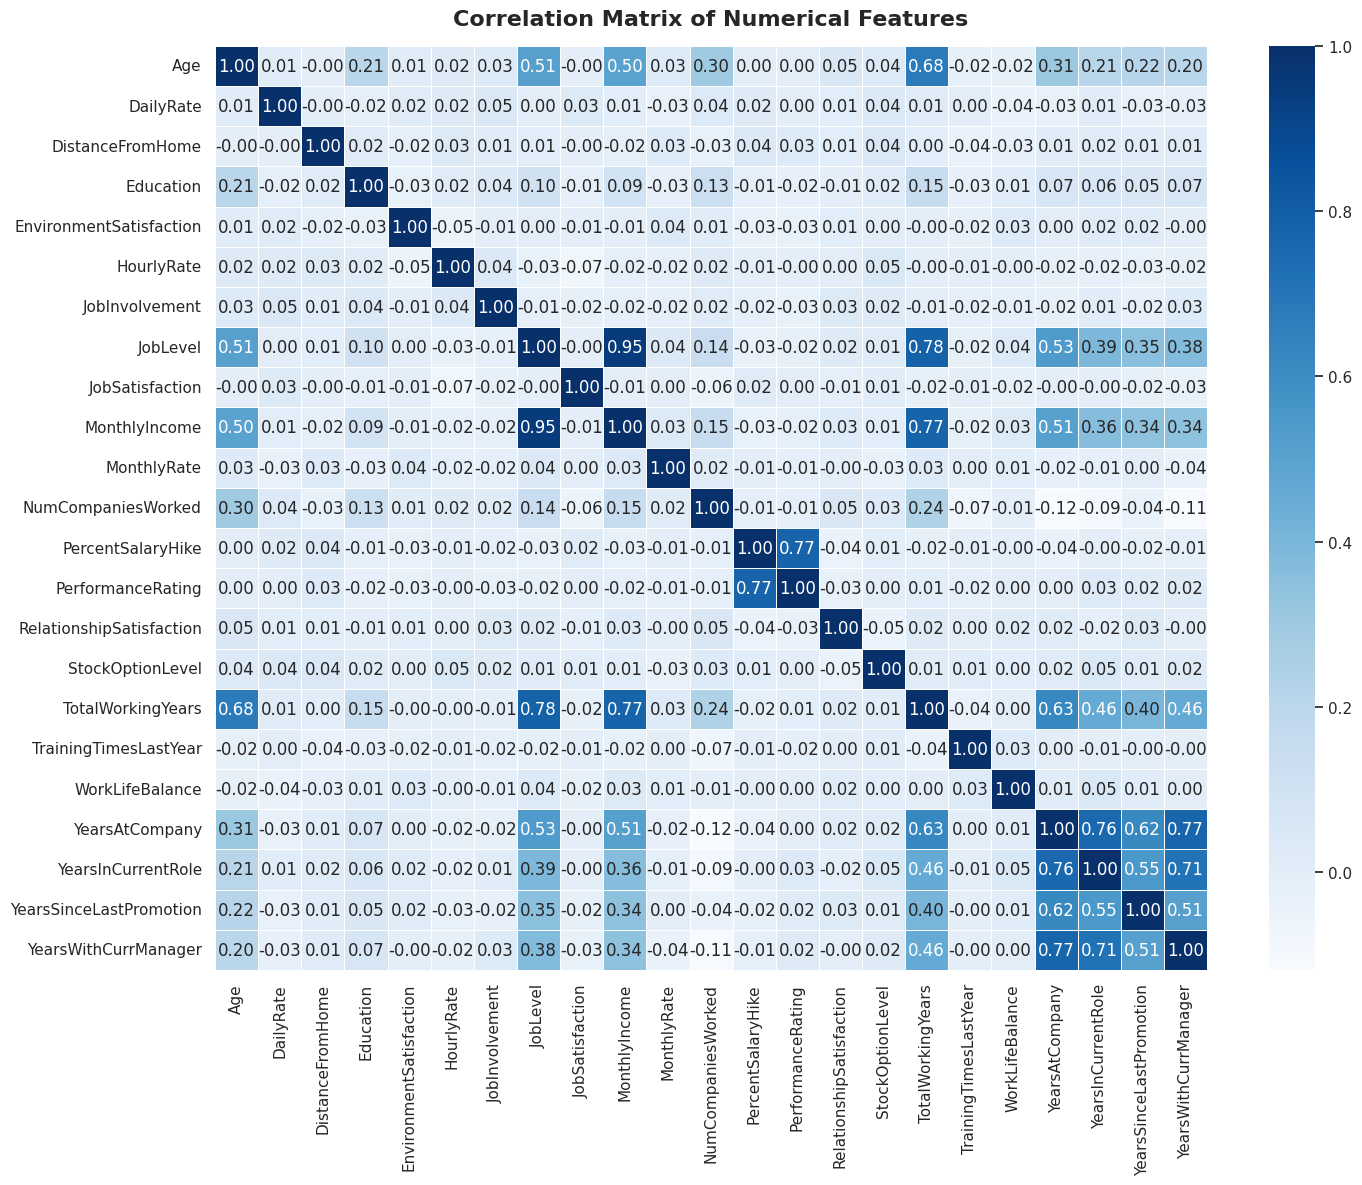

In [ ]:
#heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

chart_title("Correlation Matrix of Numerical Features")

plt.show()

In [ ]:
#Strongest Correlations
corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

strong_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

strong_corr.head(20)

JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
PercentSalaryHike        PerformanceRating          0.773550
MonthlyIncome            TotalWorkingYears          0.772893
YearsAtCompany           YearsWithCurrManager       0.769212
                         YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsWithCurrManager       0.714365
Age                      TotalWorkingYears          0.680381
TotalWorkingYears        YearsAtCompany             0.628133
YearsAtCompany           YearsSinceLastPromotion    0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
JobLevel                 YearsAtCompany             0.534739
MonthlyIncome            YearsAtCompany             0.514285
YearsSinceLastPromotion  YearsWithCurrManager       0.510224
Age                      JobLevel                   0.509604
                         MonthlyIncome              0.497855
TotalWorkingYears        YearsInCurrentRole         0.460365
                         YearsWithCurrManager       0.459188
                         YearsSinceLastPromotion    0.404858
JobLevel                 YearsInCurrentRole         0.389447
dtype: float64

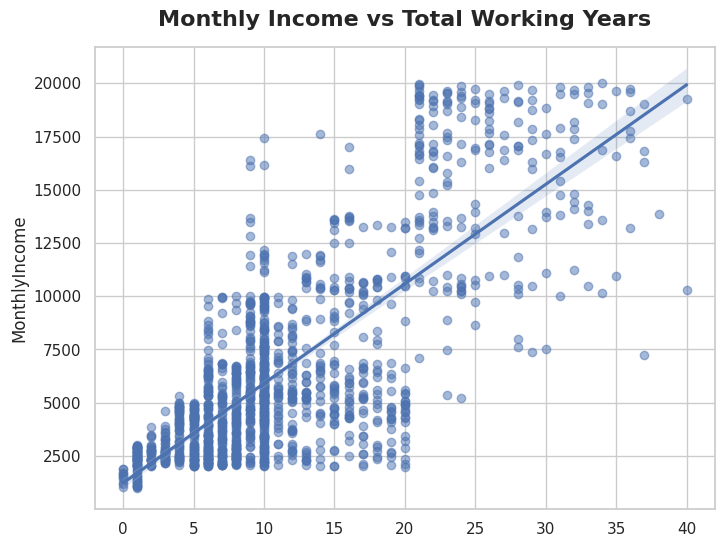

In [ ]:
#Monthly Income vs Total Working Years
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="TotalWorkingYears",
    y="MonthlyIncome",
    scatter_kws={"alpha":0.5}
)

chart_title("Monthly Income vs Total Working Years")

plt.show()

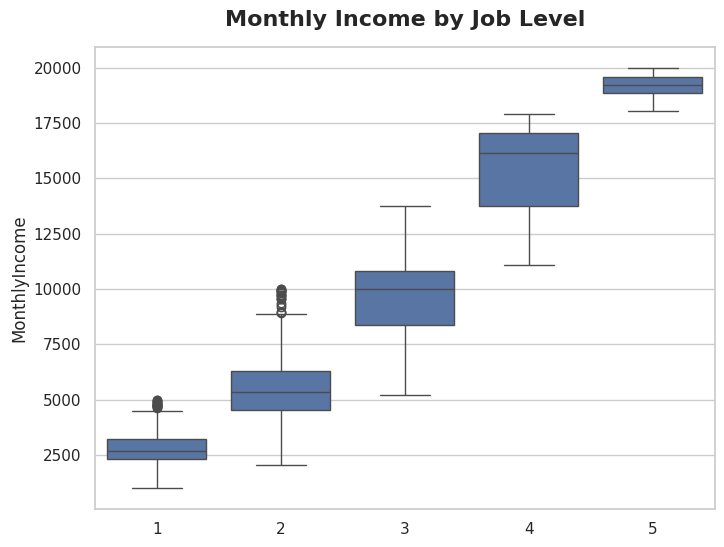

In [ ]:
#Monthly Income vs Job Level
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="JobLevel",
    y="MonthlyIncome"
)

chart_title("Monthly Income by Job Level")

plt.show()

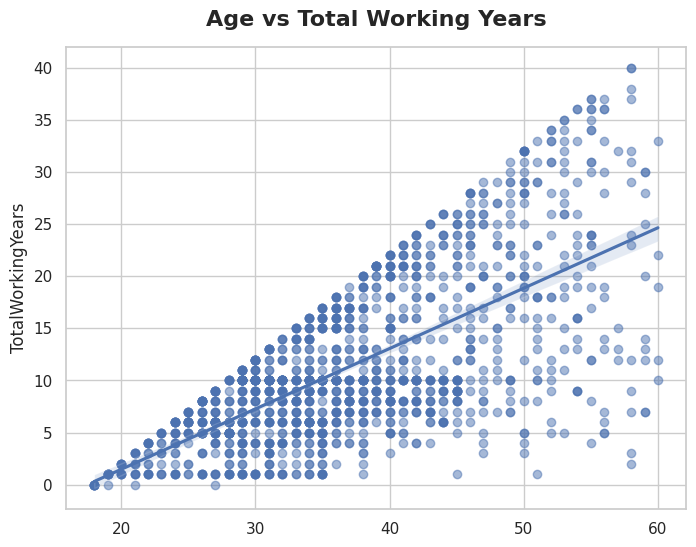

In [ ]:
#Age vs Total Working Years
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Age",
    y="TotalWorkingYears",
    scatter_kws={"alpha":0.5}
)

chart_title("Age vs Total Working Years")

plt.show()

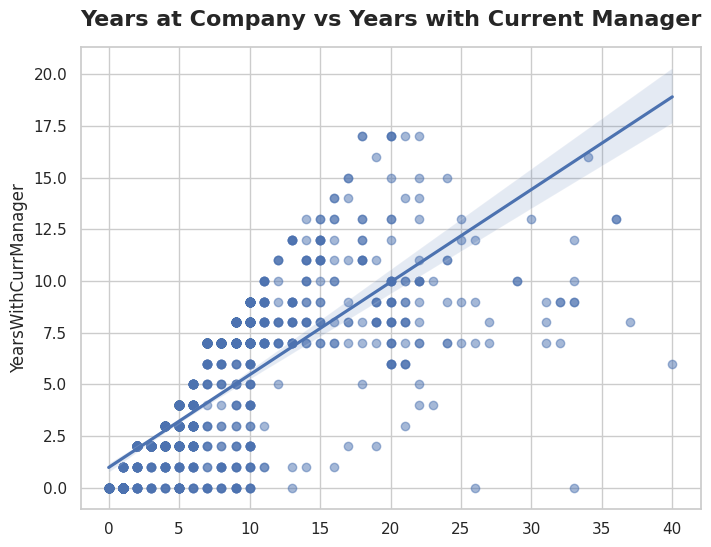

In [ ]:
#Years at Company vs Years with Current Manager
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="YearsAtCompany",
    y="YearsWithCurrManager",
    scatter_kws={"alpha":0.5}
)

chart_title("Years at Company vs Years with Current Manager")

plt.show()

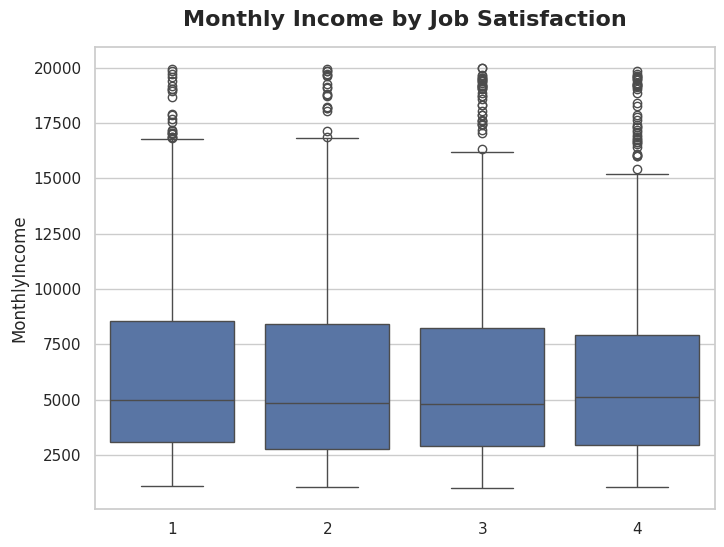

In [ ]:
#Monthly Income vs Job Satisfaction
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="JobSatisfaction",
    y="MonthlyIncome"
)

chart_title("Monthly Income by Job Satisfaction")

plt.show()

In [ ]:
print("Average Work-Life Balance")
print(df.groupby("OverTime")["WorkLifeBalance"].mean())

print("\nPercentage Distribution")
print(
    pd.crosstab(
        df["OverTime"],
        df["WorkLifeBalance"],
        normalize="index"
    )*100
)

Average Work-Life Balance
OverTime
No     2.773245
Yes    2.730769
Name: WorkLifeBalance, dtype: float64

Percentage Distribution
WorkLifeBalance         1          2          3          4
OverTime                                                  
No               5.502846  22.770398  60.626186  11.100569
Yes              5.288462  25.000000  61.057692   8.653846


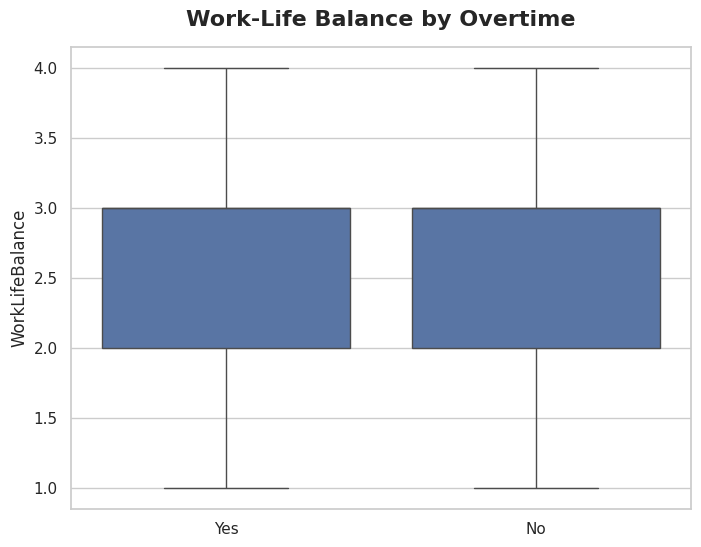

In [ ]:
#Overtime vs Work-Life Balance
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="OverTime",
    y="WorkLifeBalance"
)

chart_title("Work-Life Balance by Overtime")

plt.show()

In [ ]:
#Correlation with Monthly Income
income_corr = (
    corr["MonthlyIncome"]
    .sort_values(ascending=False)
)

income_corr

,MonthlyIncome
MonthlyIncome,1.000000
JobLevel,0.950300
TotalWorkingYears,0.772893
YearsAtCompany,0.514285
Age,0.497855
YearsInCurrentRole,0.363818
YearsSinceLastPromotion,0.344978
YearsWithCurrManager,0.344079
NumCompaniesWorked,0.149515
Education,0.094961


In [ ]:
#Correlation with Years at Company
tenure_corr = (
    corr["YearsAtCompany"]
    .sort_values(ascending=False)
)

tenure_corr

,YearsAtCompany
YearsAtCompany,1.000000
YearsWithCurrManager,0.769212
YearsInCurrentRole,0.758754
TotalWorkingYears,0.628133
YearsSinceLastPromotion,0.618409
JobLevel,0.534739
MonthlyIncome,0.514285
Age,0.311309
Education,0.069114
RelationshipSatisfaction,0.019367


In [ ]:
#Correlation with Job Level
joblevel_corr = (
    corr["JobLevel"]
    .sort_values(ascending=False)
)

joblevel_corr

,JobLevel
JobLevel,1.000000
MonthlyIncome,0.950300
TotalWorkingYears,0.782208
YearsAtCompany,0.534739
Age,0.509604
YearsInCurrentRole,0.389447
YearsWithCurrManager,0.375281
YearsSinceLastPromotion,0.353885
NumCompaniesWorked,0.142501
Education,0.101589


# **Correlation and Relationship Analysis Interpretation**

To further understand the relationships among the numerical variables in the IBM HR Employee Attrition dataset, a Pearson correlation analysis was conducted. The correlation matrix provides insight into the strength and direction of the linear relationships between variables, while scatter plots and boxplots were used to visualize important associations. Correlation coefficients range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values close to zero indicate little or no linear relation

# Correlation Matrix

Figure X presents the correlation matrix of all numerical variables included in the analysis.

The correlation analysis revealed that most variables exhibited weak to moderate relationships, while a few variables showed strong positive correlations. The strongest positive correlation observed was between Job Level and Monthly Income (r = 0.95), indicating that employees occupying higher organizational levels generally earn substantially higher salaries. This finding is expected because compensation structures in most organizations are directly linked to employee grade levels.

Another strong positive relationship was found between Job Level and Total Working Years (r = 0.78), suggesting that employees with longer professional experience are more likely to occupy higher-level positions within the organization. Similarly, Monthly Income and Total Working Years (r = 0.77) showed a strong positive association, indicating that accumulated work experience contributes significantly to employee earnings.

Employee tenure variables also demonstrated strong interrelationships. Years at Company was strongly correlated with Years with Current Manager (r = 0.77) and Years in Current Role (r = 0.76), indicating that employees who remain longer in the organization also tend to spend longer periods under the same supervisor and within the same role. These relationships reflect expected career progression and organizational stability.

Age exhibited a strong positive correlation with Total Working Years (r = 0.68), confirming that older employees generally possess more work experience. Moderate positive relationships were also observed between Age and Job Level (r = 0.51) as well as Age and Monthly Income (r = 0.50), suggesting that career advancement and salary growth tend to increase with age and accumulated experience.

Conversely, variables such as Daily Rate, Distance from Home, Hourly Rate, Job Satisfaction, Work-Life Balance, Environment Satisfaction, and Relationship Satisfaction displayed negligible correlations with Monthly Income and Years at Company. These findings indicate that these factors operate relatively independently from salary and organizational tenure.

Overall, the correlation matrix demonstrates that employee experience, organizational tenure, job level, and salary are closely interconnected, whereas employee perception variables exhibit relatively weak linear relationships with these structural career variables.

# Monthly Income and Total Working Years

Figure X illustrates the relationship between Monthly Income and Total Working Years.

The scatter plot reveals a clear positive linear relationship between total work experience and employee income. As employees accumulate more years of professional experience, their monthly earnings generally increase. This visual finding supports the strong correlation coefficient (r = 0.77) obtained from the correlation analysis.

Although salary generally rises with experience, noticeable variation exists among employees with similar years of experience. For instance, employees with approximately 20 years of experience receive salaries ranging from moderate to very high levels, suggesting that factors such as job role, department, and job level also influence compensation.

The upward trend confirms that professional experience is a major determinant of employee earnings within the organization

# Age and Total Working Years

The scatter plot examining Age against Total Working Years shows a strong positive relationship between both variables.

As expected, older employees generally possess more cumulative work experience. The correlation coefficient (r = 0.68) indicates a substantial positive association. Nevertheless, the scatter also reveals variation among employees of similar ages, reflecting differences in career paths, employment interruptions, or varying entry ages into the workforce.

This finding supports the notion that age contributes significantly to career progression but is not the sole determinant of accumulated work experience.

4.X.4 Years at Company and Years with Current Manager

Figure X presents the relationship between Years at Company and Years with Current Manager.

The scatter plot demonstrates a strong positive association between both variables (r = 0.77). Employees with longer organizational tenure generally spend more years working under their current supervisors.

The relatively linear distribution suggests stable managerial relationships across the organization, with longer-serving employees typically maintaining longer reporting relationships. However, several outliers indicate employees who experienced managerial changes despite long organizational tenure.

This finding highlights the stability of managerial assignments within the organization.

# Monthly Income and Job Satisfaction

Figure X illustrates the distribution of Monthly Income across the four Job Satisfaction levels.

The boxplot indicates that salary distributions are broadly similar across all levels of job satisfaction. Although minor differences in median income are observable, employees with both low and high job satisfaction receive comparable salary ranges.

Furthermore, high-income outliers are present across every satisfaction category, indicating that employees earning higher salaries are not necessarily more satisfied with their jobs.

These findings are supported by the correlation analysis, which revealed an almost nonexistent relationship between Monthly Income and Job Satisfaction (r = -0.01). Consequently, salary alone appears insufficient to explain variations in employee job satisfaction.

# Work-Life Balance and Overtime

The relationship between Work-Life Balance and Overtime was further examined to determine whether employees working overtime experience poorer work-life balance.

Employees who did not work overtime recorded a slightly higher average Work-Life Balance score (Mean = 2.77) compared with employees who worked overtime (Mean = 2.73). Although the difference is relatively small, it suggests that overtime work is associated with a modest decline in employees' perception of their work-life balance.

The percentage distribution provides additional insight. Among employees who did not work overtime, approximately 60.6% reported a Work-Life Balance rating of 3, while 11.1% achieved the highest rating of 4. In comparison, among employees working overtime, 61.1% reported a rating of 3, but only 8.7% attained the highest Work-Life Balance rating.

Similarly, employees working overtime exhibited a slightly higher proportion of moderate Work-Life Balance ratings (25.0%) compared with employees not working overtime (22.8%).

Overall, the findings suggest that overtime has a relatively modest influence on perceived work-life balance. While employees who work overtime generally report slightly lower work-life balance, the differences are not substantial, indicating that additional workplace factors beyond overtime may contribute to employees' perceptions of work-life balance.

# **FEATURE ENGINEERING & ML PREPARATION**

In [ ]:
#Create a Modeling Dataset
model_df = df.copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

Original dataset shape: (1470, 35)
Modeling dataset shape: (1470, 35)


In [ ]:
#Check the Target Variable
model_df["Attrition_Flag"] = model_df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

model_df["Attrition_Flag"].value_counts()

,count
Attrition_Flag,
0,1233
1,237


In [ ]:
#check percentage
model_df["Attrition_Flag"].value_counts(normalize=True).mul(100).round(2)

,proportion
Attrition_Flag,
0,83.88
1,16.12


This tells us that the dataset is imbalanced.

Only about 16% of employees left.

That becomes extremely important when evaluating our machine-learning models.

For example, a model that predicts "No attrition" for everyone would achieve roughly 84% accuracy but would be completely useless for actually identifying employees at risk of leaving.

In [ ]:
#inspecting columns not to be used
model_df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'AgeGroup',
 'EducationLevel',
 'IncomeBand',
 'Attrition_Flag']

In [ ]:
drop_cols = [
    "EmployeeNumber"
]

model_df = model_df.drop(columns=drop_cols)

print("New dataset shape:", model_df.shape)

New dataset shape: (1470, 35)


In [ ]:
#remove original target
X = model_df.drop(columns=["Attrition", "Attrition_Flag"])

y = model_df["Attrition_Flag"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1470, 33)
Target shape: (1470,)


In [ ]:
#Identify Categorical and Numerical Variables
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'EducationLevel']

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeGroup', 'IncomeBand']


In [ ]:
#missing values
missing_values = X.isnull().sum()

missing_values[missing_values > 0]

,0
AgeGroup,8


In [ ]:
# Remove derived AgeGroup variable from the modeling dataset
model_df = model_df.drop(columns=["AgeGroup"], errors="ignore")

print("AgeGroup removed.")
print("New dataset shape:", model_df.shape)

AgeGroup removed.
New dataset shape: (1470, 34)


In [ ]:
print("Missing values remaining:")

missing_values = model_df.isnull().sum()

print(missing_values[missing_values > 0])

Missing values remaining:
Series([], dtype: int64)


In [ ]:
#duplicate rows
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Recreate features and target after removing AgeGroup

X = model_df.drop(columns=["Attrition", "Attrition_Flag"])

y = model_df["Attrition_Flag"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1470, 32)
Target shape: (1470,)


In [ ]:
print("AgeGroup exists:", "AgeGroup" in X.columns)
print("IncomeBand exists:", "IncomeBand" in X.columns)

AgeGroup exists: False
IncomeBand exists: True


In [ ]:
# Define categorical features explicitly

categorical_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "EducationLevel",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
    "IncomeBand"
]

# All remaining features are numerical
numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Number of categorical features: 9
Number of numerical features: 23

Categorical features:
['BusinessTravel', 'Department', 'EducationField', 'EducationLevel', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'IncomeBand']

Numerical features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
# Verify that every feature is assigned to exactly one group

all_features = categorical_features + numerical_features

print("Total features:", len(X.columns))
print("Features classified:", len(all_features))
print("No duplicate assignments:", len(all_features) == len(set(all_features)))

missing_features = set(X.columns) - set(all_features)

print("Unclassified features:", missing_features)

Total features: 32
Features classified: 32
No duplicate assignments: True
Unclassified features: set()


In [ ]:
#preprocessing pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [ ]:
#train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1176, 32)
Testing set: (294, 32)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1176, 51)
Processed testing shape: (294, 51)


In [ ]:
print("Original features:", X.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 32
Processed features: 51


DEALING WITH CLASS IMBALANCE

In [ ]:
#Check the exact class distribution
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentage:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training class distribution:
Attrition_Flag
0    986
1    190
Name: count, dtype: int64

Training class percentage:
Attrition_Flag
0    83.84
1    16.16
Name: proportion, dtype: float64


In [ ]:
#calcualate imbalace ratio
class_counts = y_train.value_counts()

imbalance_ratio = class_counts[0] / class_counts[1]

print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")

Majority-to-minority ratio: 5.19:1


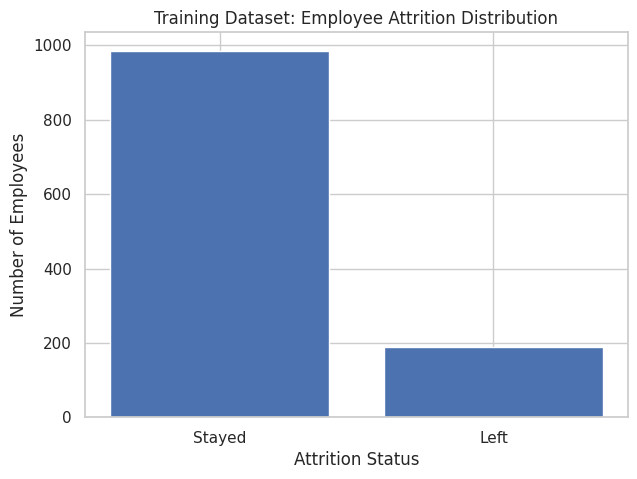

In [ ]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

labels = ["Stayed", "Left"]

plt.figure(figsize=(7, 5))
plt.bar(labels, class_counts.values)

plt.title("Training Dataset: Employee Attrition Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Number of Employees")

plt.show()

# **MODEL DEVELOPMENT**

# Model 1: Logistic Regression Baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [ ]:
#baseline pipeline
logistic_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [ ]:
#train
logistic_baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField',
                                                   'EducationLevel', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime',
                                                   'IncomeBand'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
#predictions
y_pred_baseline = logistic_baseline.predict(X_test)

y_prob_baseline = logistic_baseline.predict_proba(X_test)[:, 1]

In [ ]:
#evaluations
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
roc_auc = roc_auc_score(y_test, y_prob_baseline)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8878
Precision: 0.8182
Recall   : 0.3830
F1 Score : 0.5217
ROC-AUC  : 0.8225


In [ ]:
#classification reort
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Stayed", "Left"]
))

              precision    recall  f1-score   support

      Stayed       0.89      0.98      0.94       247
        Left       0.82      0.38      0.52        47

    accuracy                           0.89       294
   macro avg       0.86      0.68      0.73       294
weighted avg       0.88      0.89      0.87       294



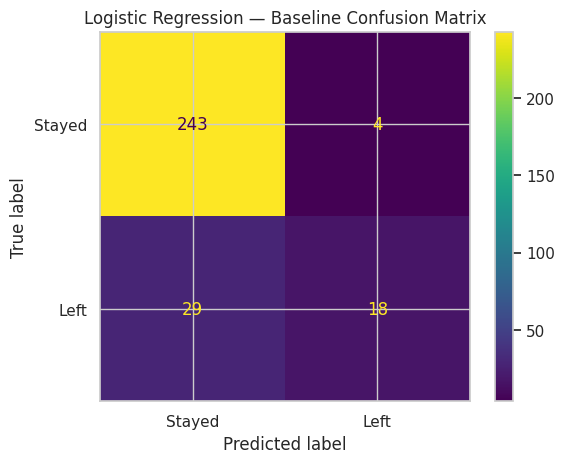

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()

plt.title("Logistic Regression — Baseline Confusion Matrix")
plt.show()

### Confusion Matrix Visualization

The confusion matrix below provides a visual representation of the model's correct and incorrect classifications, with particular attention to false negatives—employees who left but were predicted to stay.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_baseline)

print("Confusion Matrix:")
print(cm)

print("\nIndividual values:")

tn, fp, fn, tp = cm.ravel()

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix:
[[243   4]
 [ 29  18]]

Individual values:
True Negatives (TN): 243
False Positives (FP): 4
False Negatives (FN): 29
True Positives (TP): 18


## Logistic Regression — Baseline Model Interpretation

### Model Performance

The baseline Logistic Regression model achieved the following results on the test dataset:

| Metric | Score |
|---|---:|
| Accuracy | 88.78% |
| Precision | 81.82% |
| Recall | 38.30% |
| F1-Score | 52.17% |
| ROC-AUC | 82.25% |

### Confusion Matrix

| Actual / Predicted | Stayed | Left |
|---|---:|---:|
| **Stayed** | 243 | 4 |
| **Left** | 29 | 18 |

### Key Findings

The model achieved an overall accuracy of **88.78%**, indicating that most employee attrition predictions were correct. However, accuracy alone does not provide a complete picture because the dataset is imbalanced, with employees who stayed significantly outnumbering those who left.

The model performed particularly well at identifying employees who stayed, correctly classifying **243 out of 247 employees**, corresponding to a **98% recall for the Stayed class**.

However, its ability to identify employees who actually left was considerably weaker. The model correctly identified only **18 of the 47 employees who left**, resulting in an attrition recall of **38.30%**. Consequently, **29 employees who eventually left were incorrectly classified as likely to stay**.

The model's **81.82% precision for the Left class** indicates that when it predicts an employee is likely to leave, the prediction is correct in approximately 82% of cases. This suggests that the model produces relatively few false alarms, but it does so at the cost of missing many actual attrition cases.

The **ROC-AUC score of 82.25%** is encouraging and indicates that the model has good overall ability to distinguish between employees who leave and those who stay. Therefore, the relatively low recall is not necessarily evidence that the underlying model has no predictive value; rather, it suggests that the default classification threshold and class imbalance may be limiting its ability to identify higher-risk employees.

### Business Interpretation

From an HR perspective, the baseline model is **better at confirming employees who are likely to stay than identifying employees at risk of leaving**.

This creates a significant business limitation. If the model were deployed as an employee-retention early-warning system, it would correctly identify some employees at risk, but it would miss a substantial proportion of actual leavers. In this test set, **29 of the 47 employees who left were missed by the model**.

For an organization seeking to proactively reduce employee turnover, these false negatives represent missed opportunities for intervention.

### Business Implication

The baseline model provides a useful starting point, but it is **not yet suitable as a standalone employee-retention decision tool**.

The results demonstrate the importance of addressing the dataset's class imbalance and optimizing the model for the business objective of detecting potential attrition.

Because identifying employees who may leave is more important for the retention use case than simply maximizing overall accuracy, subsequent models will place greater emphasis on:

- **Recall for the Attrition/Left class**
- **F1-score**
- **ROC-AUC**
- **Precision**
- Confusion-matrix performance

Accuracy will remain an important metric, but it will not be used as the sole criterion for selecting the final model.

### Next Step

To improve the model's ability to detect employees at risk of leaving, the next stage will introduce **class-weighted Logistic Regression**. This approach will give greater importance to the minority attrition class during model training and allow us to evaluate whether we can substantially improve attrition recall without creating an unacceptable number of false positives.

# MODEL 2: BALANCED LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [ ]:
#train
logistic_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField',
                                                   'EducationLevel', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime',
                                                   'IncomeBand'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
#prediction
y_pred_balanced = logistic_balanced.predict(X_test)

y_prob_balanced = logistic_balanced.predict_proba(X_test)[:, 1]

In [ ]:
#evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)

print(f"Accuracy : {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall   : {recall_balanced:.4f}")
print(f"F1 Score : {f1_balanced:.4f}")
print(f"ROC-AUC  : {roc_auc_balanced:.4f}")

Accuracy : 0.7653
Precision: 0.3750
Recall   : 0.7021
F1 Score : 0.4889
ROC-AUC  : 0.8207


In [ ]:
#report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=["Stayed", "Left"]
))

              precision    recall  f1-score   support

      Stayed       0.93      0.78      0.85       247
        Left       0.38      0.70      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.79       294



In [ ]:
#confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(cm_balanced)

tn, fp, fn, tp = cm_balanced.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Confusion Matrix:
[[192  55]
 [ 14  33]]

TN: 192
FP: 55
FN: 14
TP: 33


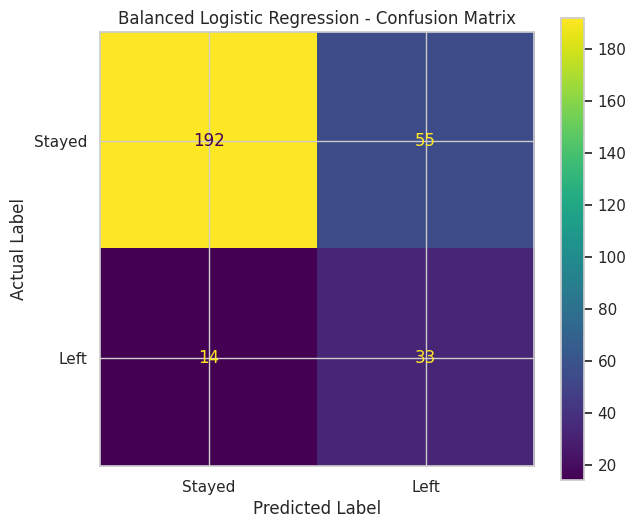

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

# Create visualization
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["Stayed", "Left"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Balanced Logistic Regression — Model Interpretation

### Model Performance

To address the class imbalance identified in the training dataset, a second Logistic Regression model was developed using `class_weight="balanced"`. This approach gives greater importance to the minority class (employees who left) during model training.

The Balanced Logistic Regression model achieved the following results:

| Metric | Score |
|---|---:|
| Accuracy | 76.53% |
| Precision — Left | 37.50% |
| Recall — Left | 70.21% |
| F1-Score — Left | 48.89% |
| ROC-AUC | 82.07% |

### Confusion Matrix

| Actual / Predicted | Stayed | Left |
|---|---:|---:|
| **Stayed** | 192 | 55 |
| **Left** | 14 | 33 |

### Key Findings

The balanced model substantially improved the model's ability to identify employees who actually left.

The recall for the **Left** class increased from **38.30% in the baseline model to 70.21%**, representing an improvement of approximately **31.91 percentage points**.

The model correctly identified **33 of the 47 employees who left**, compared with only 18 identified by the baseline model. At the same time, the number of false negatives decreased from **29 to 14**.

This means the balanced model missed considerably fewer employees who eventually left.

However, this improvement came with an increase in false positives. The number of employees who stayed but were incorrectly classified as likely to leave increased from **4 to 55**.

Consequently, precision for the **Left** class decreased from **81.82% to 37.50%**.

### Business Interpretation

From an HR perspective, the balanced model is more aligned with the objective of identifying employees who may be at risk of attrition.

The model now captures approximately **70% of employees who actually leave**, compared with only 38% under the baseline model. This means HR would have a substantially better chance of identifying employees who may benefit from early retention interventions.

However, the model also generates more false alerts. Of the employees predicted as likely to leave, a considerable proportion ultimately stayed. Therefore, the model should not be interpreted as a definitive prediction that an employee will leave.

Instead, the model can be viewed as an **early-warning or risk-screening tool** that helps HR prioritize employees for further assessment.

### Baseline vs Balanced Model

| Metric | Baseline Logistic Regression | Balanced Logistic Regression |
|---|---:|---:|
| Accuracy | 88.78% | 76.53% |
| Precision — Left | 81.82% | 37.50% |
| Recall — Left | 38.30% | **70.21%** |
| F1-Score — Left | 52.17% | 48.89% |
| ROC-AUC | 82.25% | 82.07% |
| False Negatives | 29 | **14** |
| True Positives | 18 | **33** |

### Model Trade-off

The comparison demonstrates an important trade-off caused by addressing class imbalance.

The baseline model achieved higher overall accuracy and precision but failed to identify most employees who left. The balanced model sacrificed overall accuracy and precision in exchange for substantially higher recall.

For an employee-retention use case, improving recall is potentially more valuable because failing to identify an employee who is genuinely at risk represents a missed opportunity for proactive intervention.

However, the balanced model's ROC-AUC of **82.07%** is almost unchanged from the baseline's **82.25%**. This suggests that class weighting substantially changed the model's classification behavior but did not materially improve its overall ranking ability.

### Business Implication

The Balanced Logistic Regression model provides a stronger **screening approach for identifying potential attrition risk**, but it should not yet be selected as the final model.

The increase in false positives means that deploying the model at its current classification threshold could result in HR reviewing many employees who are not actually at risk.

Therefore, further model development and threshold optimization are required.

### Next Step

The next stage will evaluate a **Decision Tree Classifier** to determine whether a nonlinear model can capture employee attrition patterns that Logistic Regression may not fully capture.

The Decision Tree model will be evaluated using the same metrics to ensure a consistent comparison across models.

# DECISION TREE CLASSIFIER

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [ ]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [ ]:
decision_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField',
                                                   'EducationLevel', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime',
                                                   'IncomeBand'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [ ]:
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")
print(f"ROC-AUC  : {roc_auc_tree:.4f}")

Accuracy : 0.8299
Precision: 0.4211
Recall   : 0.1702
F1 Score : 0.2424
ROC-AUC  : 0.6556


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["Stayed", "Left"]
))

              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.90       247
        Left       0.42      0.17      0.24        47

    accuracy                           0.83       294
   macro avg       0.64      0.56      0.57       294
weighted avg       0.79      0.83      0.80       294



In [ ]:
from sklearn.metrics import confusion_matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Confusion Matrix:")
print(cm_tree)

tn, fp, fn, tp = cm_tree.ravel()

print("\nIndividual values:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix:
[[236  11]
 [ 39   8]]

Individual values:
True Negatives (TN): 236
False Positives (FP): 11
False Negatives (FN): 39
True Positives (TP): 8


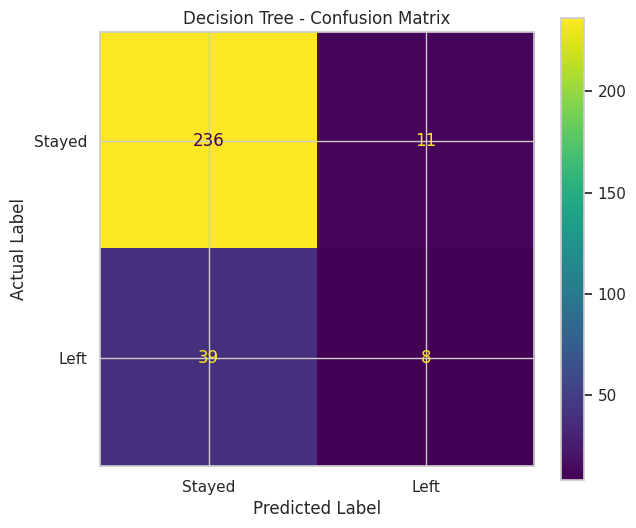

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Stayed", "Left"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig(
    "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Get the trained preprocessor
fitted_preprocessor = decision_tree.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance from the trained tree
importances = decision_tree.named_steps["classifier"].feature_importances_

# Create a DataFrame
feature_importance_tree = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_tree = feature_importance_tree.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_tree.head(20)

,Feature,Importance
16,num__TotalWorkingYears,0.227763
47,cat__OverTime_Yes,0.147191
1,num__DailyRate,0.113395
0,num__Age,0.100578
9,num__MonthlyIncome,0.096215
46,cat__MaritalStatus_Single,0.057004
42,cat__JobRole_Research Scientist,0.049864
11,num__NumCompaniesWorked,0.042111
5,num__HourlyRate,0.038135
4,num__EnvironmentSatisfaction,0.037073


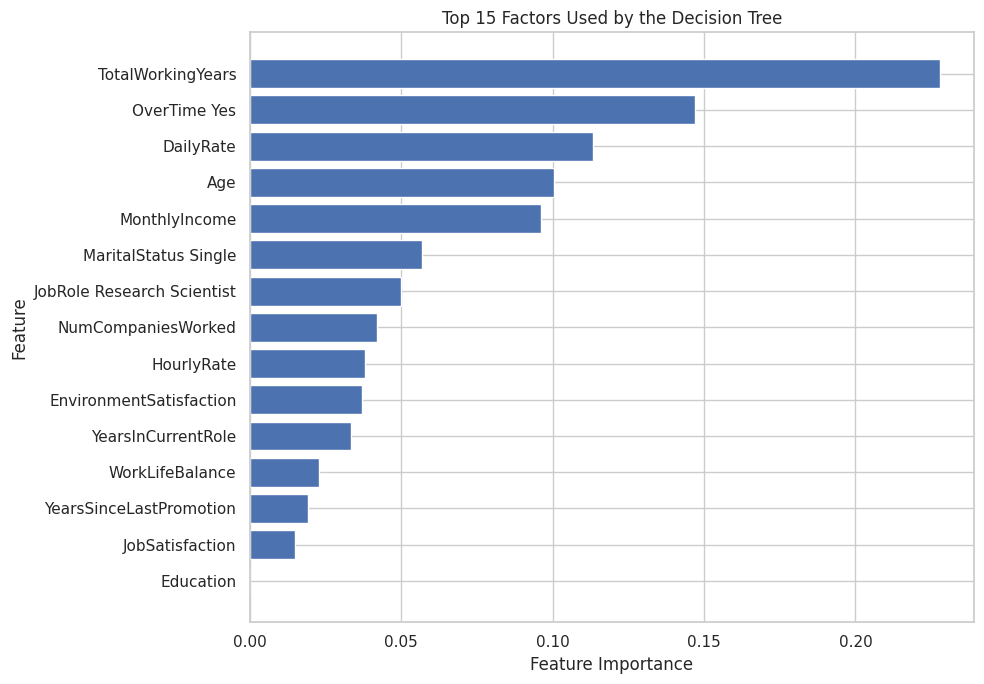

In [ ]:
import matplotlib.pyplot as plt

# Copy the top 15 features
top_features = feature_importance_tree.head(15).copy()

# Clean feature names
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Sort for horizontal bar chart
top_features = top_features.sort_values(
    by="Importance",
    ascending=True
)

# Create chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Factors Used by the Decision Tree")

plt.tight_layout()

plt.savefig(
    "decision_tree_top_15_feature_importance_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Decision Tree Feature Importance Visualization

The chart above presents the 15 features that contributed most strongly to the Decision Tree's predictions.

Total Working Years, Overtime, Daily Rate, Age, and Monthly Income were among the most influential features in the model.

Feature importance reflects how much a feature contributed to the model's decision-making process. It should not be interpreted as evidence that a feature directly causes employee attrition.

## Decision Tree — Baseline Model Interpretation

### Model Performance

A Decision Tree Classifier was developed as the next baseline model to determine whether a nonlinear model could identify attrition patterns that may not be captured by Logistic Regression.

The model was configured with a maximum tree depth of 5 to control complexity and reduce the risk of overfitting.

| Metric | Score |
|---|---:|
| Accuracy | 82.99% |
| Precision — Left | 42.11% |
| Recall — Left | 17.02% |
| F1-Score — Left | 24.24% |
| ROC-AUC | 65.56% |

### Confusion Matrix

| Actual / Predicted | Stayed | Left |
|---|---:|---:|
| **Stayed** | 236 | 11 |
| **Left** | 39 | 8 |

### Key Findings

The Decision Tree achieved an overall accuracy of **82.99%** and correctly identified most employees who stayed. Its recall for the Stayed class was approximately **95.55%**.

However, the model performed poorly in identifying employees who actually left. It correctly identified only **8 of the 47 employees who left**, resulting in an attrition recall of **17.02%**.

The model therefore produced **39 false negatives**, meaning that most employees who eventually left were incorrectly classified as likely to stay.

The model's **ROC-AUC of 65.56%** was also substantially lower than the ROC-AUC values obtained from the Logistic Regression models, indicating weaker overall discrimination between employees who stayed and those who left.

### Business Interpretation

From an HR perspective, the baseline Decision Tree is not sufficiently effective as an employee-retention early-warning model in its current configuration.

Although it performs well at identifying employees who stay, its low attrition recall means that it would miss a large proportion of employees who are actually at risk of leaving.

This limits its usefulness for proactive retention planning, where identifying potential leavers is a key business objective.

### Feature Importance

The most influential features in the Decision Tree were:

1. **Total Working Years** — 22.78%
2. **Overtime — Yes** — 14.72%
3. **Daily Rate** — 11.34%
4. **Age** — 10.06%
5. **Monthly Income** — 9.62%
6. **Marital Status — Single** — 5.70%
7. **Job Role — Research Scientist** — 4.99%
8. **Number of Companies Worked** — 4.21%
9. **Hourly Rate** — 3.81%
10. **Environment Satisfaction** — 3.71%

Total Working Years was the strongest feature used by the model, followed by Overtime — Yes.

The prominence of Overtime is consistent with patterns observed during the exploratory analysis. However, feature importance represents the contribution of a variable to model predictions and should not be interpreted as evidence of a causal relationship with employee attrition.

### Business Implication

The baseline Decision Tree should not be selected as the final model in its current configuration.

However, the results provide a useful baseline and indicate that further experimentation with class weighting and model optimization may be necessary to improve the tree's ability to identify the minority attrition class.

### Next Step

The next stage will develop a **Balanced Decision Tree** using class weighting. The objective is to determine whether giving greater importance to employees who leave can improve attrition recall while maintaining an acceptable level of precision and overall model performance.

# BALANCED DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

balanced_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [ ]:
balanced_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField',
                                                   'EducationLevel', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime',
                                                   'IncomeBand'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [ ]:
y_pred_balanced_tree = balanced_tree.predict(X_test)

y_prob_balanced_tree = balanced_tree.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_balanced_tree = accuracy_score(
    y_test,
    y_pred_balanced_tree
)

precision_balanced_tree = precision_score(
    y_test,
    y_pred_balanced_tree
)

recall_balanced_tree = recall_score(
    y_test,
    y_pred_balanced_tree
)

f1_balanced_tree = f1_score(
    y_test,
    y_pred_balanced_tree
)

roc_auc_balanced_tree = roc_auc_score(
    y_test,
    y_prob_balanced_tree
)

print(f"Accuracy : {accuracy_balanced_tree:.4f}")
print(f"Precision: {precision_balanced_tree:.4f}")
print(f"Recall   : {recall_balanced_tree:.4f}")
print(f"F1 Score : {f1_balanced_tree:.4f}")
print(f"ROC-AUC  : {roc_auc_balanced_tree:.4f}")

Accuracy : 0.7687
Precision: 0.3521
Recall   : 0.5319
F1 Score : 0.4237
ROC-AUC  : 0.6346


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_balanced_tree,
    target_names=["Stayed", "Left"]
))

              precision    recall  f1-score   support

      Stayed       0.90      0.81      0.86       247
        Left       0.35      0.53      0.42        47

    accuracy                           0.77       294
   macro avg       0.63      0.67      0.64       294
weighted avg       0.81      0.77      0.79       294



In [ ]:
from sklearn.metrics import confusion_matrix

cm_balanced_tree = confusion_matrix(
    y_test,
    y_pred_balanced_tree
)

print("Confusion Matrix:")
print(cm_balanced_tree)

tn, fp, fn, tp = cm_balanced_tree.ravel()

print("\nIndividual values:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix:
[[201  46]
 [ 22  25]]

Individual values:
True Negatives (TN): 201
False Positives (FP): 46
False Negatives (FN): 22
True Positives (TP): 25


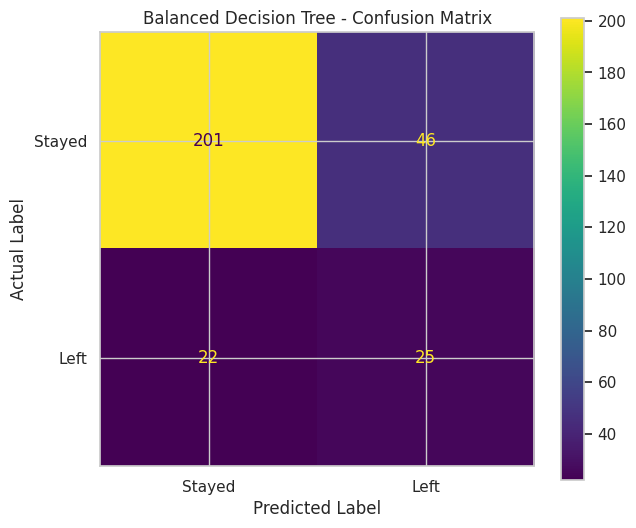

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced_tree,
    display_labels=["Stayed", "Left"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Balanced Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig(
    "balanced_decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#comparison
tree_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision - Left",
        "Recall - Left",
        "F1 Score - Left",
        "ROC-AUC"
    ],
    "Decision Tree": [
        accuracy_tree,
        precision_tree,
        recall_tree,
        f1_tree,
        roc_auc_tree
    ],
    "Balanced Decision Tree": [
        accuracy_balanced_tree,
        precision_balanced_tree,
        recall_balanced_tree,
        f1_balanced_tree,
        roc_auc_balanced_tree
    ]
})

tree_comparison

,Metric,Decision Tree,Balanced Decision Tree
0,Accuracy,0.829932,0.768707
1,Precision - Left,0.421053,0.352113
2,Recall - Left,0.170213,0.531915
3,F1 Score - Left,0.242424,0.423729
4,ROC-AUC,0.655569,0.634637


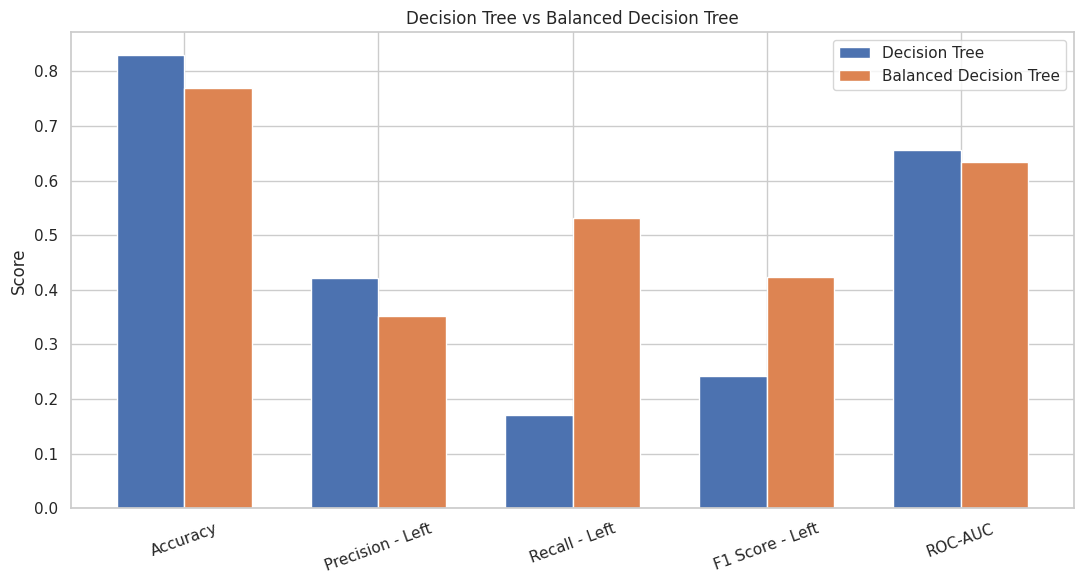

In [ ]:
metrics = [
    "Accuracy",
    "Precision - Left",
    "Recall - Left",
    "F1 Score - Left",
    "ROC-AUC"
]

tree_metrics = [
    accuracy_tree,
    precision_tree,
    recall_tree,
    f1_tree,
    roc_auc_tree
]

balanced_tree_metrics = [
    accuracy_balanced_tree,
    precision_balanced_tree,
    recall_balanced_tree,
    f1_balanced_tree,
    roc_auc_balanced_tree
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    [i - width/2 for i in x],
    tree_metrics,
    width,
    label="Decision Tree"
)

plt.bar(
    [i + width/2 for i in x],
    balanced_tree_metrics,
    width,
    label="Balanced Decision Tree"
)

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("Decision Tree vs Balanced Decision Tree")
plt.legend()

plt.tight_layout()

plt.savefig(
    "decision_tree_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Balanced Decision Tree — Model Interpretation

### Model Performance

A class-balanced Decision Tree was developed to address the substantial class imbalance observed in the dataset. The original Decision Tree identified only 17.02% of employees who left, making it unsuitable for a retention-focused application.

The balanced model assigned greater importance to the minority attrition class using `class_weight="balanced"`.

| Metric | Decision Tree | Balanced Decision Tree |
|---|---:|---:|
| Accuracy | 82.99% | 76.87% |
| Precision — Left | 42.11% | 35.21% |
| Recall — Left | 17.02% | 53.19% |
| F1-Score — Left | 24.24% | 42.37% |
| ROC-AUC | 65.56% | 63.46% |

### Confusion Matrix

The Balanced Decision Tree produced the following confusion matrix:

| Actual / Predicted | Stayed | Left |
|---|---:|---:|
| **Stayed** | 201 | 46 |
| **Left** | 22 | 25 |

The model correctly identified **25 of the 47 employees who left**, compared with only 8 identified by the original Decision Tree.

### Key Findings

The most significant improvement was in recall for the attrition class. Recall increased from **17.02% to 53.19%**, representing an improvement of approximately 36 percentage points.

This indicates that class balancing substantially improved the model's ability to identify employees who actually left.

However, precision for the attrition class declined from **42.11% to 35.21%**. The model also generated 46 false positives, meaning a relatively large number of employees who stayed were incorrectly classified as potential leavers.

The model's ROC-AUC also decreased from **65.56% to 63.46%**, indicating that class balancing improved classification of the minority class at the selected threshold but did not improve the model's overall discriminatory ability.

### Business Interpretation

From an HR perspective, the balanced Decision Tree represents an improvement over the original Decision Tree when the primary objective is to identify more potential leavers.

Missing an employee who is genuinely at risk of leaving may be more costly than investigating an employee who ultimately stays. Therefore, the improvement in recall is valuable for a retention-focused early-warning system.

However, the relatively low precision means that HR teams would need to investigate many false-positive cases. This could increase the cost of intervention and reduce the efficiency of a retention program.

### Model Assessment

Although the Balanced Decision Tree improved attrition recall substantially, its overall performance remains weaker than the Logistic Regression models evaluated earlier.

The Logistic Regression models achieved ROC-AUC values above 82%, while both Decision Tree models remained below 66%.

Therefore, the Balanced Decision Tree will not be selected as the final model at this stage.

Further ensemble learning techniques, including Random Forest and XGBoost, will be evaluated to determine whether they can provide a stronger balance between attrition recall, precision, F1-score, and overall discrimination.

### Key Takeaway

Class balancing successfully improved the Decision Tree's ability to detect employees who left, but the improvement came with more false positives and lower overall discrimination.

The next stage will test ensemble models to determine whether these trade-offs can be improved.

# RANDOM FOREST BASELINE

Objective

We want to answer:

Can an ensemble of decision trees identify employee attrition better than a single Decision Tree while maintaining stronger overall predictive performance?

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [ ]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                max_depth=8,
                min_samples_split=5,
                min_samples_leaf=2,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField',
                                                   'EducationLevel', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime',
                                                   'IncomeBand'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [ ]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [ ]:
#performance metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.8299
Precision: 0.3636
Recall   : 0.0851
F1 Score : 0.1379
ROC-AUC  : 0.8023


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Stayed", "Left"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.91       247
        Left       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



In [ ]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Confusion Matrix:")
print(cm_rf)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("\nIndividual values:")
print("True Negatives (TN):", tn_rf)
print("False Positives (FP):", fp_rf)
print("False Negatives (FN):", fn_rf)
print("True Positives (TP):", tp_rf)

Confusion Matrix:
[[240   7]
 [ 43   4]]

Individual values:
True Negatives (TN): 240
False Positives (FP): 7
False Negatives (FN): 43
True Positives (TP): 4


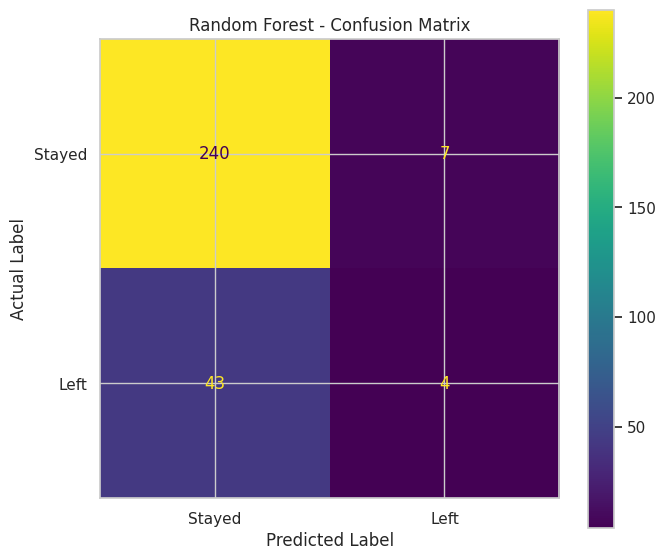

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Left"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

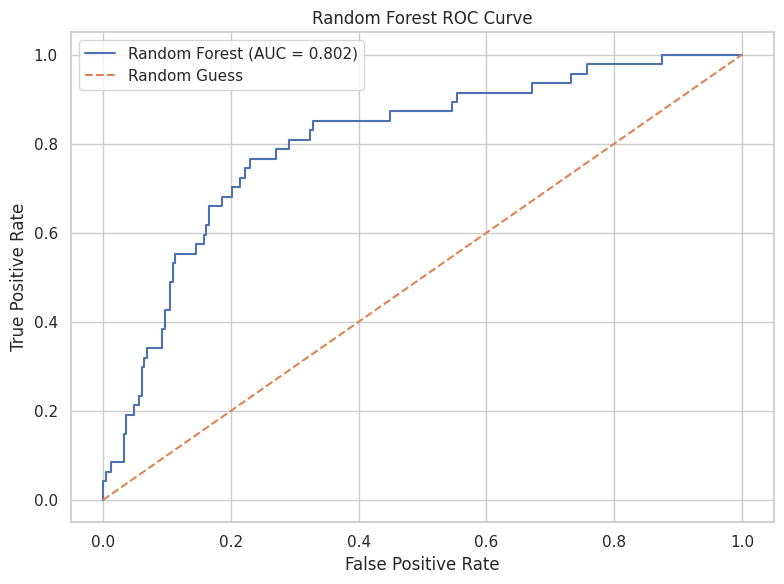

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    "random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#feature importance
feature_names_rf = (
    random_forest
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances_rf = (
    random_forest
    .named_steps["classifier"]
    .feature_importances_
)

In [ ]:
rf_feature_importance = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": feature_importances_rf
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance.head(20)

,Feature,Importance
9,num__MonthlyIncome,0.081740
16,num__TotalWorkingYears,0.071718
0,num__Age,0.066726
47,cat__OverTime_Yes,0.059074
2,num__DistanceFromHome,0.047048
1,num__DailyRate,0.045412
19,num__YearsAtCompany,0.043113
10,num__MonthlyRate,0.039991
22,num__YearsWithCurrManager,0.039182
5,num__HourlyRate,0.036109


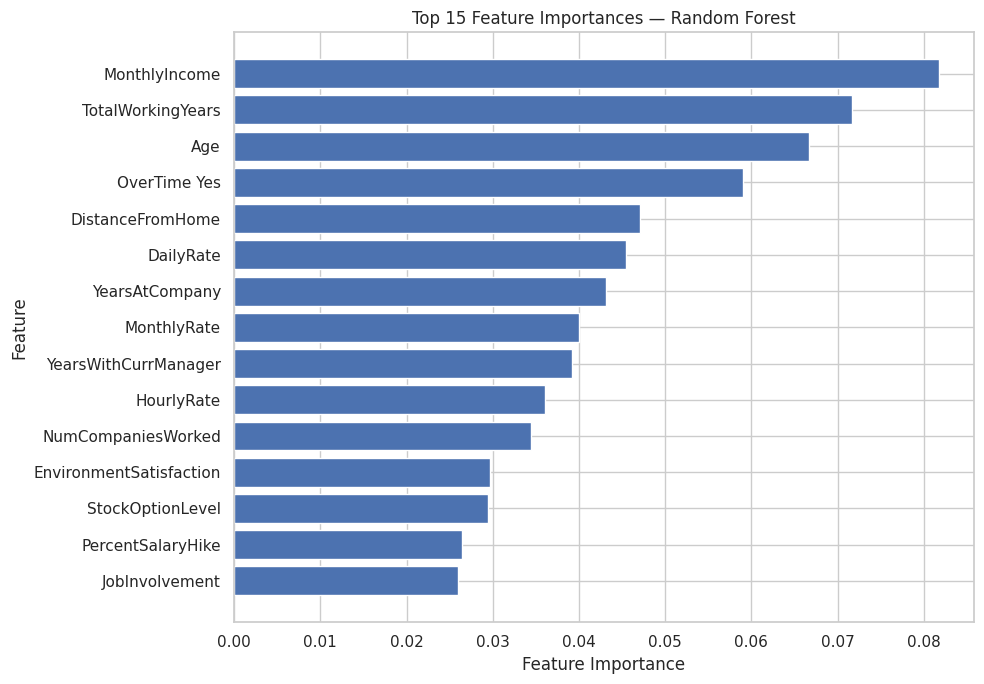

In [ ]:
top_rf_features = (
    rf_feature_importance
    .head(15)
    .copy()
)

top_rf_features["Feature"] = (
    top_rf_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_rf_features = top_rf_features.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Random Forest")

plt.tight_layout()

plt.savefig(
    "random_forest_top_15_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#model comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Balanced Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        accuracy_tree,
        accuracy_balanced_tree,
        accuracy_rf
    ],
    "Precision_Left": [
        precision,
        precision_balanced,
        precision_tree,
        precision_balanced_tree,
        precision_rf
    ],
    "Recall_Left": [
        recall,
        recall_balanced,
        recall_tree,
        recall_balanced_tree,
        recall_rf
    ],
    "F1_Left": [
        f1,
        f1_balanced,
        f1_tree,
        f1_balanced_tree,
        f1_rf
    ],
    "ROC_AUC": [
        roc_auc,
        roc_auc_balanced,
        roc_auc_tree,
        roc_auc_balanced_tree,
        roc_auc_rf
    ]
})

model_comparison

,Model,Accuracy,Precision_Left,Recall_Left,F1_Left,ROC_AUC
0,Logistic Regression,0.887755,0.818182,0.382979,0.521739,0.822465
1,Balanced Logistic Regression,0.765306,0.375000,0.702128,0.488889,0.820656
2,Decision Tree,0.829932,0.421053,0.170213,0.242424,0.655569
3,Balanced Decision Tree,0.768707,0.352113,0.531915,0.423729,0.634637
4,Random Forest,0.829932,0.363636,0.085106,0.137931,0.802309


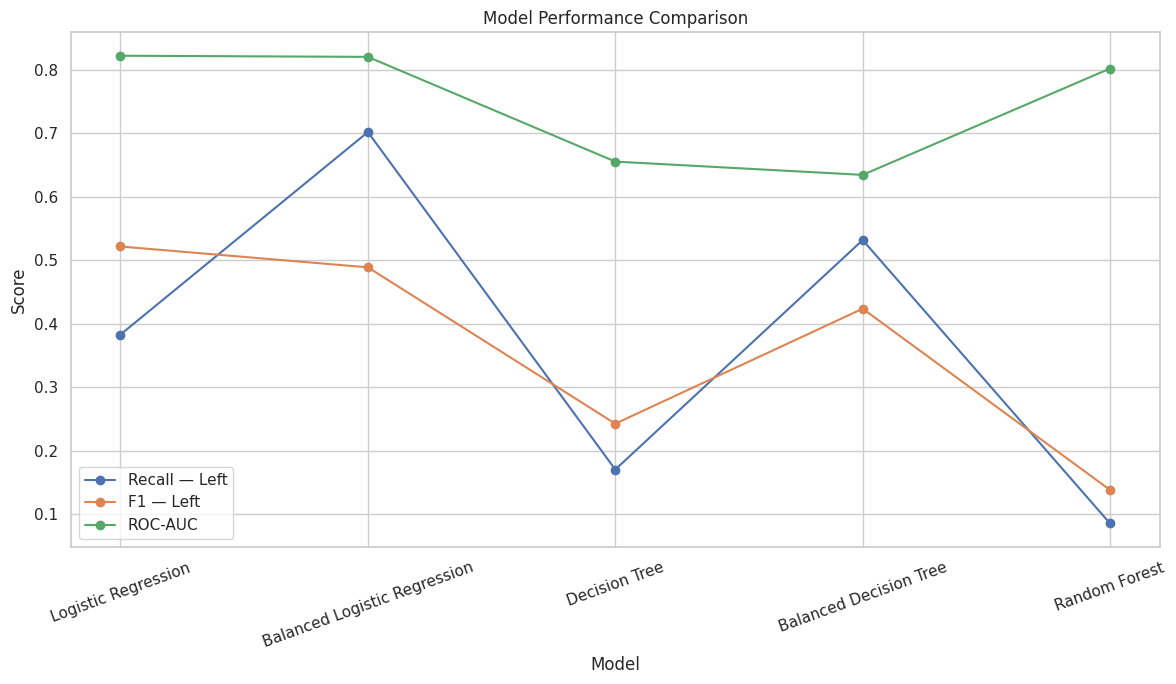

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(
    model_comparison["Model"],
    model_comparison["Recall_Left"],
    marker="o",
    label="Recall — Left"
)

plt.plot(
    model_comparison["Model"],
    model_comparison["F1_Left"],
    marker="o",
    label="F1 — Left"
)

plt.plot(
    model_comparison["Model"],
    model_comparison["ROC_AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Random Forest — Baseline Model Interpretation

### Model Performance

A Random Forest Classifier was developed to determine whether an ensemble of decision trees could capture employee attrition patterns more effectively than a single Decision Tree.

The model consisted of 300 trees with controlled tree depth and minimum split parameters to reduce unnecessary model complexity.

| Metric | Score |
|---|---:|
| Accuracy | 82.99% |
| Precision — Left | 36.36% |
| Recall — Left | 8.51% |
| F1-Score — Left | 13.79% |
| ROC-AUC | 80.23% |

### Confusion Matrix

| Actual / Predicted | Stayed | Left |
|---|---:|---:|
| **Stayed** | 240 | 7 |
| **Left** | 43 | 4 |

The model correctly identified only **4 of the 47 employees who left**, resulting in an attrition recall of **8.51%**.

This means that the baseline Random Forest missed approximately 91% of employees who actually left.

### Key Findings

Although the model achieved an overall accuracy of **82.99%**, accuracy is not sufficient for evaluating this problem because the dataset is imbalanced and the primary business objective is to identify employees who may leave.

The model's precision for the Left class was **36.36%**, while recall was only **8.51%**. Therefore, the model identified very few actual leavers at its default classification threshold.

However, the Random Forest achieved a **ROC-AUC of 80.23%**, which is substantially higher than the ROC-AUC values of the Decision Tree models.

This indicates that the Random Forest has considerably stronger overall discriminatory ability than the individual Decision Trees, even though its default classification threshold produces poor attrition recall.

### Feature Importance

The most influential features in the Random Forest were:

1. **Monthly Income** — 8.17%
2. **Total Working Years** — 7.17%
3. **Age** — 6.67%
4. **Overtime — Yes** — 5.91%
5. **Distance From Home** — 4.70%
6. **Daily Rate** — 4.54%
7. **Years at Company** — 4.31%
8. **Monthly Rate** — 4.00%
9. **Years With Current Manager** — 3.92%
10. **Hourly Rate** — 3.61%

Several of these variables have also appeared as important factors during the exploratory analysis, providing consistency between the descriptive and predictive stages of the project.

### Business Interpretation

The baseline Random Forest is not suitable for direct deployment as a retention early-warning model using the default classification threshold because it identifies only a small proportion of actual leavers.

However, its ROC-AUC of **80.23%** indicates that the model contains useful predictive information and can distinguish between employees who stay and employees who leave considerably better than the single Decision Tree.

This suggests that the model's probability estimates may contain useful information even though the default classification threshold is not optimal for the business objective.

### Model Assessment

The Random Forest substantially improved overall discrimination compared with the Decision Tree family, but its minority-class recall at the default threshold remained poor.

Therefore, the model should not yet be rejected. Instead, the next stage will investigate class balancing and alternative classification thresholds to determine whether the Random Forest's underlying predictive capability can be translated into better identification of employees at risk of attrition.

### Key Takeaway

The Random Forest demonstrates stronger overall predictive discrimination than the individual Decision Trees, but its default classification threshold is poorly suited to the imbalanced attrition problem.

Further optimization is required before determining whether Random Forest can become a competitive final model.

# **RANDOM FOREST THRESHOLD ANALYSIS**

In [ ]:
#Generate predicted probabilities
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [ ]:
#Examine different probability thresholds
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_rf >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.523810,0.237288,0.893617,0.375000
1,0.15,0.724490,0.342593,0.787234,0.477419
2,0.20,0.792517,0.410256,0.680851,0.512000
3,0.25,0.833333,0.481481,0.553191,0.514851
4,0.30,0.826531,0.444444,0.340426,0.385542
5,0.35,0.829932,0.444444,0.255319,0.324324
6,0.40,0.840136,0.500000,0.191489,0.276923
7,0.45,0.833333,0.437500,0.148936,0.222222
8,0.50,0.829932,0.363636,0.085106,0.137931
9,0.55,0.843537,0.571429,0.085106,0.148148


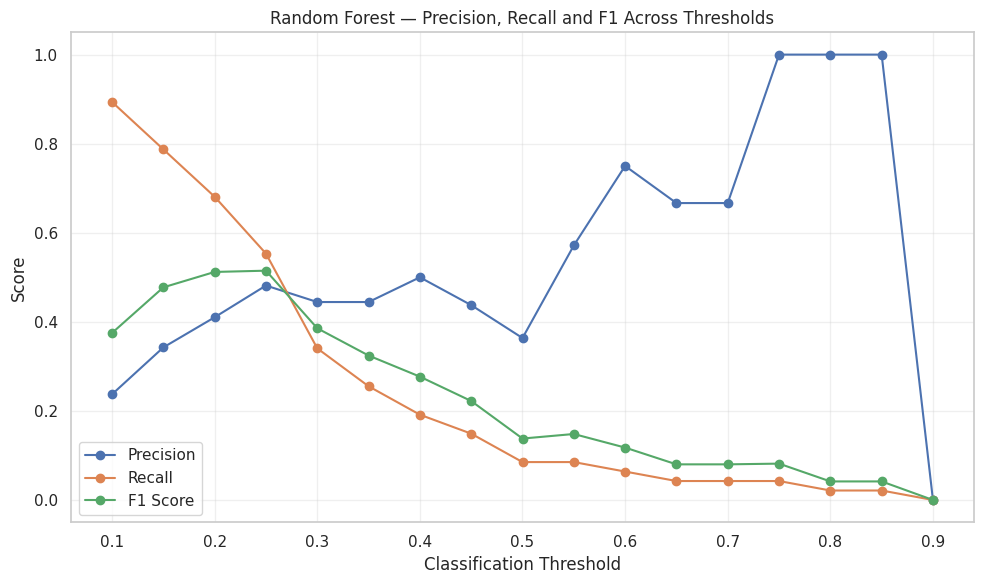

In [ ]:
#PRECISION VS RECALL
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    "Random Forest — Precision, Recall and F1 Across Thresholds"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "random_forest_threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#threshold with the best F1 score
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_f1_row

,3
Threshold,0.250000
Accuracy,0.833333
Precision,0.481481
Recall,0.553191
F1 Score,0.514851


In [ ]:
print(
    "Best F1 threshold:",
    round(best_f1_row["Threshold"], 2)
)

print(
    "Precision:",
    round(best_f1_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_f1_row["Recall"], 4)
)

print(
    "F1 Score:",
    round(best_f1_row["F1 Score"], 4)
)

print(
    "Accuracy:",
    round(best_f1_row["Accuracy"], 4)
)

Best F1 threshold: 0.25
Precision: 0.4815
Recall: 0.5532
F1 Score: 0.5149
Accuracy: 0.8333


In [ ]:
#threshold with at least 50% recall
threshold_results_df[
    threshold_results_df["Recall"] >= 0.50
]

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.523810,0.237288,0.893617,0.375000
1,0.15,0.724490,0.342593,0.787234,0.477419
2,0.20,0.792517,0.410256,0.680851,0.512000
3,0.25,0.833333,0.481481,0.553191,0.514851


In [ ]:
#threshold with at least 60% recall
threshold_results_df[
    threshold_results_df["Recall"] >= 0.60
]

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.523810,0.237288,0.893617,0.375000
1,0.15,0.724490,0.342593,0.787234,0.477419
2,0.20,0.792517,0.410256,0.680851,0.512000


In [ ]:
threshold_results_df[
    threshold_results_df["Recall"] >= 0.70
]

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.52381,0.237288,0.893617,0.375000
1,0.15,0.72449,0.342593,0.787234,0.477419


In [ ]:
best_threshold = best_f1_row["Threshold"]

y_pred_rf_tuned = (
    y_prob_rf >= best_threshold
).astype(int)

print("Selected threshold:", best_threshold)

Selected threshold: 0.25000000000000006


In [ ]:
#Threshold-selected prediction
best_threshold = best_f1_row["Threshold"]

y_pred_rf_tuned = (
    y_prob_rf >= best_threshold
).astype(int)

print("Selected threshold:", best_threshold)

Selected threshold: 0.25000000000000006


In [ ]:
#Evaluate the tuned Random Forest
print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=["Stayed", "Left"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90       247
        Left       0.48      0.55      0.51        47

    accuracy                           0.83       294
   macro avg       0.70      0.72      0.71       294
weighted avg       0.84      0.83      0.84       294



In [ ]:
cm_rf_tuned = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

print("Confusion Matrix:")
print(cm_rf_tuned)

tn, fp, fn, tp = cm_rf_tuned.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Confusion Matrix:
[[219  28]
 [ 21  26]]

TN: 219
FP: 28
FN: 21
TP: 26


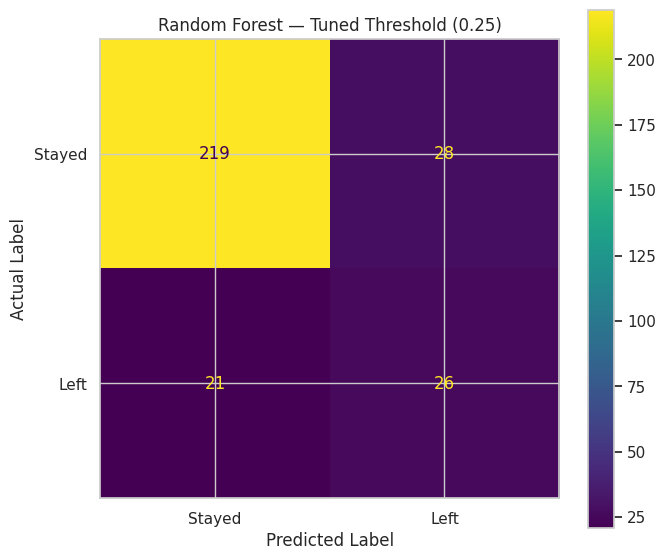

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_tuned,
    display_labels=["Stayed", "Left"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    f"Random Forest — Tuned Threshold ({best_threshold:.2f})"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "random_forest_tuned_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
business_thresholds = threshold_results_df[
    threshold_results_df["Threshold"].isin(
        [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    )
].copy()

business_thresholds

,Threshold,Accuracy,Precision,Recall,F1 Score


In [ ]:
threshold_results_df[
    threshold_results_df["Threshold"].between(
        0.19, 0.51
    )
]

,Threshold,Accuracy,Precision,Recall,F1 Score
2,0.20,0.792517,0.410256,0.680851,0.512000
3,0.25,0.833333,0.481481,0.553191,0.514851
4,0.30,0.826531,0.444444,0.340426,0.385542
5,0.35,0.829932,0.444444,0.255319,0.324324
6,0.40,0.840136,0.500000,0.191489,0.276923
7,0.45,0.833333,0.437500,0.148936,0.222222
8,0.50,0.829932,0.363636,0.085106,0.137931


## Random Forest — Probability Threshold Optimization

The baseline Random Forest achieved a ROC-AUC of 0.8023, indicating good overall discrimination between employees who stayed and those who left. However, at the default probability threshold of 0.50, the model achieved only 8.51% recall for the attrition class.

This indicated that the default threshold was too conservative for an employee retention use case.

To investigate this issue, multiple probability thresholds were evaluated between 0.20 and 0.50.

### Threshold Analysis

The analysis showed a clear trade-off between precision and recall.

At the default threshold of 0.50:

- Accuracy: 82.99%
- Precision (Left): 36.36%
- Recall (Left): 8.51%
- F1 Score (Left): 13.79%

At the optimized threshold of 0.25:

- Accuracy: 83.33%
- Precision (Left): 48.15%
- Recall (Left): 55.32%
- F1 Score (Left): 51.49%

The confusion matrix at the 0.25 threshold was:

- True Negatives: 219
- False Positives: 28
- False Negatives: 21
- True Positives: 26

Compared with the default threshold, the number of correctly identified employees who left increased from 4 to 26.

### Business Interpretation

The results demonstrate that the default 0.50 classification threshold is not necessarily appropriate for an HR attrition-risk application.

Lowering the threshold to 0.25 substantially increased the model's sensitivity to potential leavers while maintaining an overall accuracy of 83.33%.

The model identified 26 of the 47 employees who actually left, corresponding to a recall of 55.32%.

However, the model also generated 28 false-positive alerts. Therefore, the model should not be interpreted as a definitive predictor of employee resignation.

Instead, it is better positioned as an early-warning and prioritization tool that can help HR identify employees who may warrant further investigation or engagement.

Potential interventions could include retention conversations, workload assessments, career-development discussions, compensation reviews, and manager check-ins.

### Threshold Selection

The 0.25 threshold produced the highest F1 score (51.49%) among the evaluated thresholds and therefore provides the best balance between precision and recall in this analysis.

However, if the organization places a greater cost on missing potential leavers than on investigating false-positive cases, the 0.20 threshold may also be considered because it increases recall to 68.09%.

The appropriate operational threshold should ultimately be determined by the organization's intervention capacity and the relative business cost of false negatives versus false positives.

### Key Takeaway

Probability threshold optimization significantly improved the Random Forest's ability to identify potential attrition cases.

This demonstrates that model performance should not be evaluated solely using the default 0.50 classification threshold or overall accuracy. For business applications, the classification threshold should be aligned with the organization's objectives and risk tolerance.

# **BALANCED RANDOM FOREST**

In [ ]:
#TRAIN
from sklearn.ensemble import RandomForestClassifier

balanced_random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_random_forest.fit(
    X_train_processed,
    y_train
)

print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


In [ ]:
#PREDICTIONS
y_pred_brf = balanced_random_forest.predict(
    X_test_processed
)

In [ ]:
#PROBABILITIES
y_prob_brf = balanced_random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
#EVALUATION
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_brf = accuracy_score(
    y_test,
    y_pred_brf
)

precision_brf = precision_score(
    y_test,
    y_pred_brf,
    zero_division=0
)

recall_brf = recall_score(
    y_test,
    y_pred_brf,
    zero_division=0
)

f1_brf = f1_score(
    y_test,
    y_pred_brf,
    zero_division=0
)

roc_auc_brf = roc_auc_score(
    y_test,
    y_prob_brf
)

print("Accuracy :", round(accuracy_brf, 4))
print("Precision:", round(precision_brf, 4))
print("Recall   :", round(recall_brf, 4))
print("F1 Score :", round(f1_brf, 4))
print("ROC-AUC  :", round(roc_auc_brf, 4))

Accuracy : 0.8367
Precision: 0.4286
Recall   : 0.0638
F1 Score : 0.1111
ROC-AUC  : 0.7614


In [ ]:
#REPORT
print(
    classification_report(
        y_test,
        y_pred_brf,
        target_names=["Stayed", "Left"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.43      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.64      0.52      0.51       294
weighted avg       0.78      0.84      0.78       294



In [ ]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

cm_brf = confusion_matrix(
    y_test,
    y_pred_brf
)

print("Confusion Matrix:")
print(cm_brf)

tn, fp, fn, tp = cm_brf.ravel()

print("\nIndividual values:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix:
[[243   4]
 [ 44   3]]

Individual values:
True Negatives (TN): 243
False Positives (FP): 4
False Negatives (FN): 44
True Positives (TP): 3


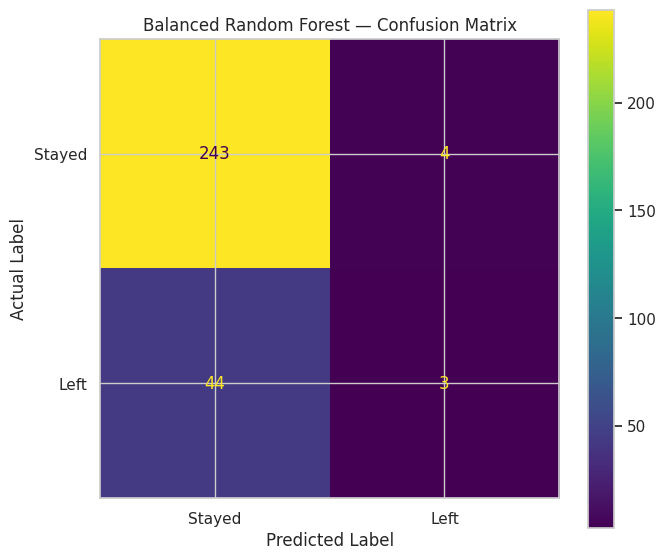

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_brf,
    display_labels=["Stayed", "Left"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Balanced Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "balanced_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

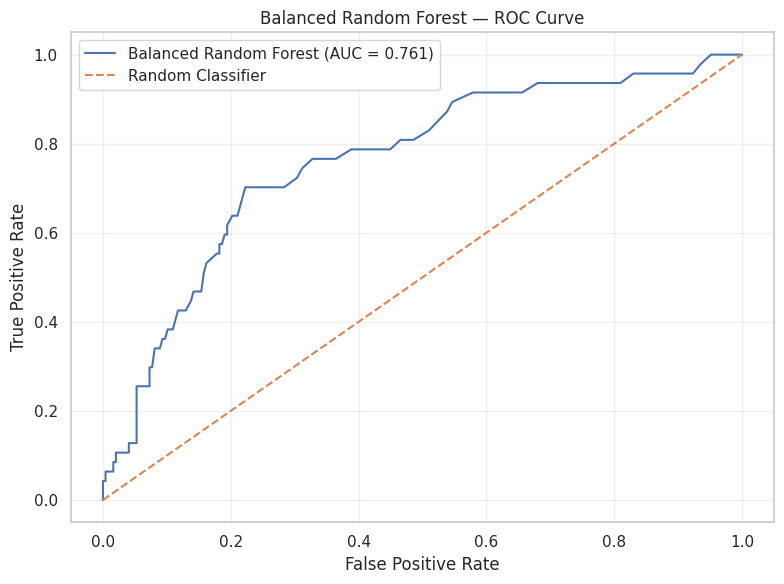

In [ ]:
from sklearn.metrics import roc_curve

fpr_brf, tpr_brf, thresholds_brf = roc_curve(
    y_test,
    y_prob_brf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_brf,
    tpr_brf,
    label=f"Balanced Random Forest (AUC = {roc_auc_brf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Balanced Random Forest — ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "balanced_random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#FEATURE IMPORTANCE
feature_importance_brf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": balanced_random_forest.feature_importances_
})

feature_importance_brf = feature_importance_brf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_brf.head(20)

,Feature,Importance
9,num__MonthlyIncome,0.073177
0,num__Age,0.062128
16,num__TotalWorkingYears,0.052528
1,num__DailyRate,0.051487
19,num__YearsAtCompany,0.046179
10,num__MonthlyRate,0.044207
2,num__DistanceFromHome,0.043086
5,num__HourlyRate,0.043000
47,cat__OverTime_Yes,0.042085
22,num__YearsWithCurrManager,0.038295


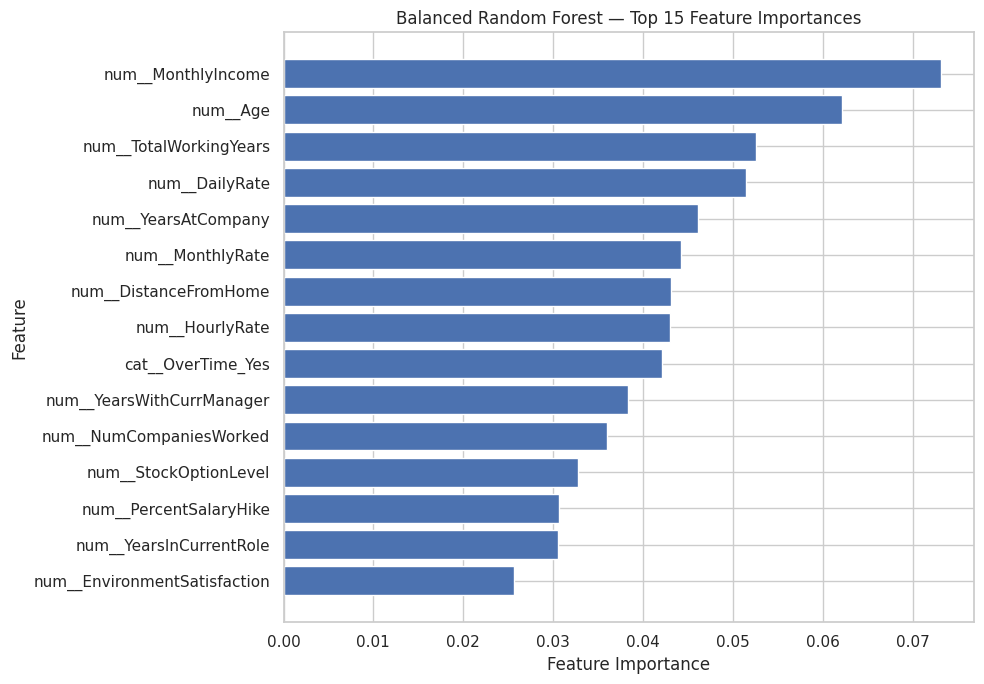

In [ ]:
top_features_brf = (
    feature_importance_brf
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_brf["Feature"],
    top_features_brf["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Balanced Random Forest — Top 15 Feature Importances"
)

plt.tight_layout()

plt.savefig(
    "balanced_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Balanced Random Forest — Model Evaluation

A Balanced Random Forest was trained using `class_weight="balanced"` to address the significant class imbalance in the dataset, where employees who stayed represented 83.84% of the training data while employees who left represented only 16.16%.

The model achieved:

- Accuracy: 83.67%
- Precision (Left): 42.86%
- Recall (Left): 6.38%
- F1 Score (Left): 11.11%
- ROC-AUC: 76.14%

### Confusion Matrix

The model produced the following confusion matrix:

- True Negatives: 243
- False Positives: 4
- False Negatives: 44
- True Positives: 3

The most significant issue is the high number of false negatives. The model correctly identified only 3 of the 47 employees who actually left, resulting in a recall of 6.38% for the attrition class.

### Business Interpretation

Although the Balanced Random Forest achieved an overall accuracy of 83.67%, accuracy alone does not provide an adequate assessment of an employee attrition model because the dataset is highly imbalanced.

The model's very low recall indicates that it is still heavily biased toward correctly identifying employees who stay rather than employees who leave.

Therefore, despite explicitly applying class balancing during model training, the Balanced Random Forest does not provide a strong solution for identifying employees at risk of attrition.

This demonstrates that class weighting alone does not necessarily solve class imbalance problems, particularly when the underlying predictive relationships are complex.

### Feature Importance

The most influential features included MonthlyIncome, Age, TotalWorkingYears, DailyRate, YearsAtCompany, MonthlyRate, DistanceFromHome, HourlyRate, OverTime, and YearsWithCurrManager.

Several of these variables are consistent with patterns identified during exploratory analysis.

However, feature importance should be interpreted as the variables the model relied on most heavily for prediction rather than evidence of causal relationships with employee attrition.

### Key Takeaway

The Balanced Random Forest did not outperform the other approaches for detecting employee attrition.

Its 6.38% recall means that it missed 44 of the 47 employees who actually left.

Consequently, this model should not be selected as the final attrition-risk model.

The results reinforce the importance of evaluating models using business-relevant metrics such as recall, precision, F1 score and ROC-AUC rather than relying primarily on overall accuracy.

# **XGBOOST**

In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [ ]:
#calculate class imbalance weight
# Calculate class imbalance ratio

class_counts = y_train.value_counts()

negative_class = class_counts[0]
positive_class = class_counts[1]

scale_pos_weight = negative_class / positive_class

print("Stayed:", negative_class)
print("Left:", positive_class)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Stayed: 986
Left: 190
scale_pos_weight: 5.19


In [ ]:
#train
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


In [ ]:
#predictions
# Predictions
xgb_pred = xgb_model.predict(X_test_processed)

# Probability of belonging to the "Left" class
xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
#evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Performance")
print("=" * 40)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Stayed", "Left"]
    )
)

XGBoost Performance
Accuracy : 0.8435
Precision: 0.5152
Recall   : 0.3617
F1 Score : 0.4250
ROC-AUC  : 0.7666

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.94      0.91       247
        Left       0.52      0.36      0.42        47

    accuracy                           0.84       294
   macro avg       0.70      0.65      0.67       294
weighted avg       0.83      0.84      0.83       294



In [ ]:
#confusion maTRIX
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_pred)

print("Confusion Matrix:")
print(xgb_cm)

tn, fp, fn, tp = xgb_cm.ravel()

print("\nIndividual values:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix:
[[231  16]
 [ 30  17]]

Individual values:
True Negatives (TN): 231
False Positives (FP): 16
False Negatives (FN): 30
True Positives (TP): 17


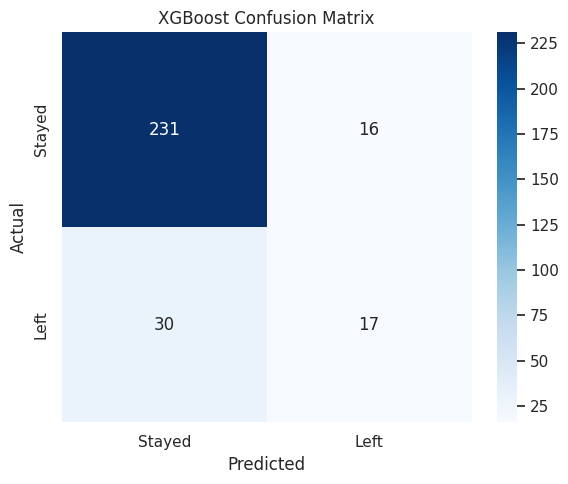

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
#FEATURE IMPORTANCE
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("Number of XGBoost features:", len(xgb_model.feature_importances_))

Number of feature names: 51
Number of XGBoost features: 51


In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
43,cat__JobRole_Sales Executive,0.053044
47,cat__OverTime_Yes,0.047351
7,num__JobLevel,0.044367
15,num__StockOptionLevel,0.035325
48,cat__IncomeBand_Low,0.031307
26,cat__Department_Sales,0.030247
22,num__YearsWithCurrManager,0.029059
19,num__YearsAtCompany,0.027732
28,cat__EducationField_Marketing,0.027589
44,cat__JobRole_Sales Representative,0.025319


In [ ]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision_Left": xgb_precision,
    "Recall_Left": xgb_recall,
    "F1_Left": xgb_f1,
    "ROC_AUC": xgb_roc_auc
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.8435374149659864,
 'Precision_Left': 0.5151515151515151,
 'Recall_Left': 0.3617021276595745,
 'F1_Left': 0.425,
 'ROC_AUC': np.float64(0.7666465673184598)}

## XGBoost — Model Evaluation

XGBoost was introduced as a gradient-boosting approach capable of capturing nonlinear relationships and interactions between employee characteristics.

Because the target variable is imbalanced, `scale_pos_weight` was applied using the ratio of employees who stayed to employees who left in the training dataset.

The model achieved:

- Accuracy: 84.35%
- Precision (Left): 51.52%
- Recall (Left): 36.17%
- F1 Score (Left): 42.50%
- ROC-AUC: 76.66%

### Confusion Matrix

The XGBoost model produced:

- True Negatives: 231
- False Positives: 16
- False Negatives: 30
- True Positives: 17

The model correctly identified 17 of the 47 employees who actually left, resulting in a recall of 36.17% for the attrition class.

Although the model achieved relatively strong precision of 51.52%, it missed 30 employees who eventually left. This indicates that the model is more conservative in identifying potential leavers and may not be sufficient on its own for a retention strategy where identifying as many at-risk employees as possible is the primary objective.

### Feature Importance

The most influential features included Job Role (Sales Executive), OverTime, Job Level, Stock Option Level, Income Band, Department, Years With Current Manager, Years At Company, Education Field and other job-role variables.

Several of these variables are consistent with patterns observed during exploratory data analysis, particularly the importance of overtime, job structure, compensation, tenure and job role.

However, feature importance represents the contribution of variables to the model's predictions and should not be interpreted as evidence of causal relationships.

### Business Interpretation

The model demonstrates useful predictive capability, particularly in terms of precision. Approximately 52% of employees predicted as likely to leave were actually members of the attrition class.

However, the 36.17% recall indicates that a substantial proportion of actual leavers would still remain unidentified.

Therefore, the baseline XGBoost model does not outperform the strongest existing approaches for the primary objective of identifying employees at risk of attrition.

Its results nevertheless provide valuable evidence that nonlinear and interaction-based modeling can capture different patterns from the linear and tree-based models previously evaluated.

# **PROBABILITY THRESHOLD OPTIMIZATION**

In [ ]:
# PREDICT PROBABILITIES FOR THRESHOLD ANALYSIS

# Balanced Logistic Regression
balanced_log_prob = logistic_balanced.predict_proba(
    X_test
)[:, 1]

# Random Forest
rf_prob = random_forest.predict_proba(
    X_test
)[:, 1]

# XGBoost
xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("Probability predictions generated successfully.")

Probability predictions generated successfully.


In [ ]:
#Test multiple thresholds
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:

    # Balanced Logistic Regression
    balanced_log_pred = (
        balanced_log_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Model": "Balanced Logistic Regression",
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            balanced_log_pred
        ),
        "Precision": precision_score(
            y_test,
            balanced_log_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            balanced_log_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            balanced_log_pred,
            zero_division=0
        )
    })

    # Random Forest
    rf_pred_threshold = (
        rf_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Model": "Random Forest",
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            rf_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            rf_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            rf_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            rf_pred_threshold,
            zero_division=0
        )
    })

    # XGBoost
    xgb_pred_threshold = (
        xgb_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Model": "XGBoost",
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            xgb_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.round(3)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Balanced Logistic Regression,0.10,0.378,0.199,0.957,0.330
1,Random Forest,0.10,0.524,0.237,0.894,0.375
2,XGBoost,0.10,0.643,0.293,0.872,0.439
3,Balanced Logistic Regression,0.15,0.459,0.220,0.936,0.356
4,Random Forest,0.15,0.724,0.343,0.787,0.477
5,XGBoost,0.15,0.684,0.291,0.681,0.408
6,Balanced Logistic Regression,0.20,0.537,0.246,0.915,0.387
7,Random Forest,0.20,0.793,0.410,0.681,0.512
8,XGBoost,0.20,0.711,0.289,0.553,0.380
9,Balanced Logistic Regression,0.25,0.609,0.276,0.894,0.422


In [ ]:
#best F1 threshold for each model
best_thresholds = (
    threshold_results_df
    .sort_values("F1 Score", ascending=False)
    .groupby("Model")
    .head(1)
)

best_thresholds

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
10,Random Forest,0.25,0.833333,0.481481,0.553191,0.514851
24,Balanced Logistic Regression,0.50,0.765306,0.375000,0.702128,0.488889
23,XGBoost,0.45,0.833333,0.476190,0.425532,0.449438


In [ ]:
#BEST THRESHHOLD FOR RECALL
best_recall_thresholds = (
    threshold_results_df
    .sort_values("Recall", ascending=False)
    .groupby("Model")
    .head(1)
)

best_recall_thresholds

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Balanced Logistic Regression,0.1,0.377551,0.199115,0.957447,0.329670
1,Random Forest,0.1,0.523810,0.237288,0.893617,0.375000
2,XGBoost,0.1,0.642857,0.292857,0.872340,0.438503


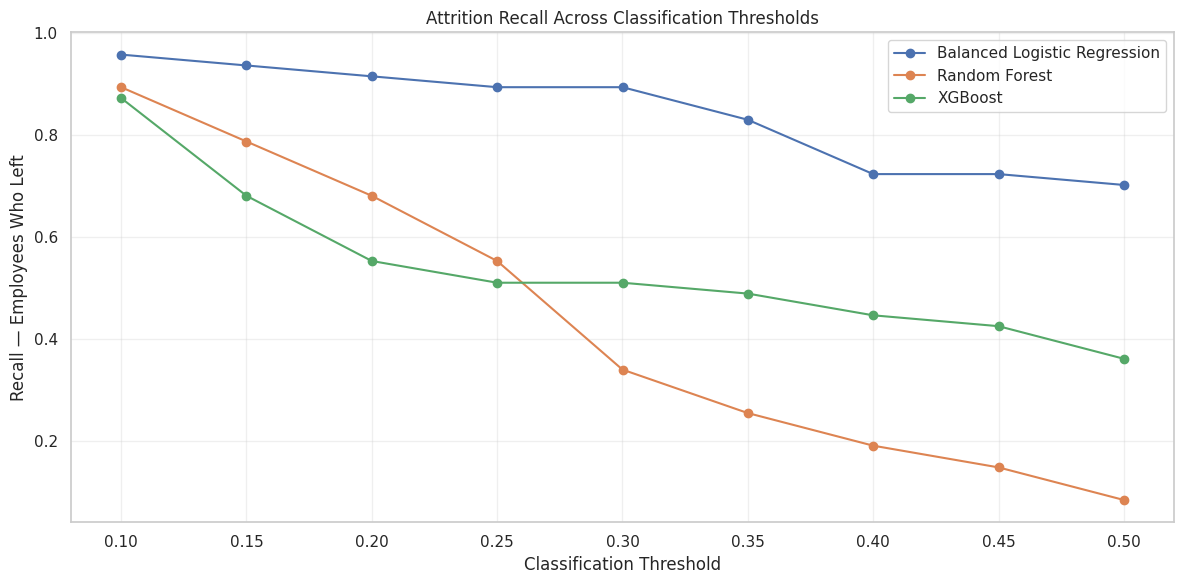

In [ ]:
plt.figure(figsize=(12, 6))

for model in threshold_results_df["Model"].unique():

    model_data = threshold_results_df[
        threshold_results_df["Model"] == model
    ]

    plt.plot(
        model_data["Threshold"],
        model_data["Recall"],
        marker="o",
        label=model
    )

plt.title("Attrition Recall Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Recall — Employees Who Left")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

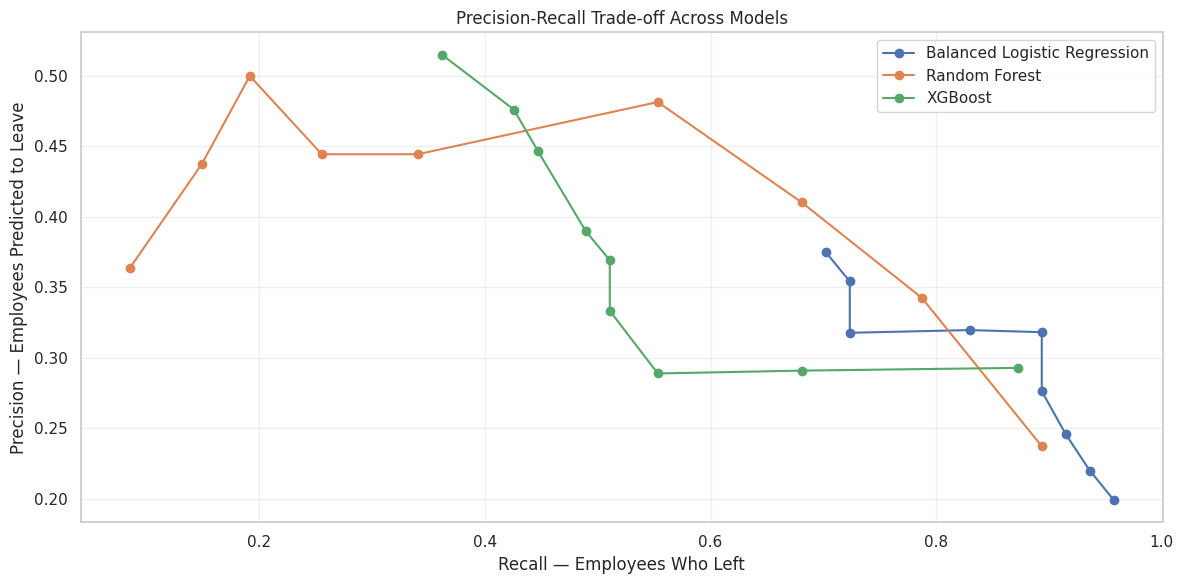

In [ ]:
plt.figure(figsize=(12, 6))

for model in threshold_results_df["Model"].unique():

    model_data = threshold_results_df[
        threshold_results_df["Model"] == model
    ]

    plt.plot(
        model_data["Recall"],
        model_data["Precision"],
        marker="o",
        label=model
    )

plt.title("Precision-Recall Trade-off Across Models")
plt.xlabel("Recall — Employees Who Left")
plt.ylabel("Precision — Employees Predicted to Leave")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#THRESHOLD TABLE
business_thresholds = threshold_results_df[
    threshold_results_df["Threshold"].isin(
        [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
    )
].copy()

business_thresholds.round(3)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score


In [ ]:
# Display business threshold results clearly

business_thresholds = threshold_results_df[
    threshold_results_df["Threshold"].isin(
        [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
    )
].copy()

business_thresholds = business_thresholds.sort_values(
    ["Model", "Threshold"]
)

display(
    business_thresholds[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ]
    ].round(3)
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score


In [ ]:
print(
    business_thresholds[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ]
    ].round(3).to_string(index=False)
)

Empty DataFrame
Columns: [Model, Threshold, Accuracy, Precision, Recall, F1 Score]
Index: []


In [ ]:
print(
    business_thresholds[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ]
    ].round(3).to_string(index=False)
)

Empty DataFrame
Columns: [Model, Threshold, Accuracy, Precision, Recall, F1 Score]
Index: []


In [ ]:
print(threshold_results_df["Threshold"].dtype)
print(threshold_results_df["Threshold"].unique())

float64
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


In [ ]:
threshold_results_df["Threshold"] = pd.to_numeric(
    threshold_results_df["Threshold"],
    errors="coerce"
)

print(threshold_results_df["Threshold"].dtype)
print(threshold_results_df["Threshold"].unique())

float64
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


In [ ]:
business_thresholds = threshold_results_df[
    (threshold_results_df["Threshold"] >= 0.20) &
    (threshold_results_df["Threshold"] <= 0.50)
].copy()

business_thresholds

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
6,Balanced Logistic Regression,0.20,0.537415,0.245714,0.914894,0.387387
7,Random Forest,0.20,0.792517,0.410256,0.680851,0.512000
8,XGBoost,0.20,0.710884,0.288889,0.553191,0.379562
9,Balanced Logistic Regression,0.25,0.608844,0.276316,0.893617,0.422111
10,Random Forest,0.25,0.833333,0.481481,0.553191,0.514851
11,XGBoost,0.25,0.758503,0.333333,0.510638,0.403361
12,Balanced Logistic Regression,0.30,0.676871,0.318182,0.893617,0.469274
13,Random Forest,0.30,0.826531,0.444444,0.340426,0.385542
14,XGBoost,0.30,0.782313,0.369231,0.510638,0.428571
15,Balanced Logistic Regression,0.35,0.690476,0.319672,0.829787,0.461538


In [ ]:
# ============================================
# NUMBER OF EMPLOYEES FLAGGED AT EACH THRESHOLD
# ============================================

threshold_employee_results = []

for model_name, probabilities in [
    ("Balanced Logistic Regression", balanced_log_prob),
    ("Random Forest", rf_prob),
    ("XGBoost", xgb_prob)
]:

    for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        flagged = predictions.sum()

        threshold_employee_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Employees_Flagged": flagged,
            "Percentage_Flagged": (
                flagged / len(predictions) * 100
            )
        })

flagged_df = pd.DataFrame(threshold_employee_results)

display(
    flagged_df.round(2)
)

,Model,Threshold,Employees_Flagged,Percentage_Flagged
0,Balanced Logistic Regression,0.20,175,59.52
1,Balanced Logistic Regression,0.25,152,51.70
2,Balanced Logistic Regression,0.30,132,44.90
3,Balanced Logistic Regression,0.35,122,41.50
4,Balanced Logistic Regression,0.40,107,36.39
5,Balanced Logistic Regression,0.45,96,32.65
6,Balanced Logistic Regression,0.50,88,29.93
7,Random Forest,0.20,78,26.53
8,Random Forest,0.25,54,18.37
9,Random Forest,0.30,36,12.24


## Threshold Optimization and Final Threshold Selection

Because employee attrition is an imbalanced classification problem, the default probability threshold of 0.50 may not provide the most useful business outcome. Threshold analysis was therefore performed across Balanced Logistic Regression, Random Forest, and XGBoost models.

The analysis demonstrated a clear trade-off between precision and recall. Lower classification thresholds generally increased recall by identifying more potential leavers, but also increased the number of false-positive predictions.

### Key Findings

**Balanced Logistic Regression** achieved the highest recall across the tested thresholds. At a threshold of 0.20, it achieved a recall of 91.49%, meaning that it identified the majority of employees who actually left. However, its precision was only 24.57%, meaning that a large proportion of employees flagged by the model would not necessarily leave.

At a threshold of 0.45, Balanced Logistic Regression provided a more balanced result, with 72.34% recall, 35.42% precision, and an F1 score of 47.55%.

**Random Forest** produced the strongest overall balance between precision and recall. At a threshold of 0.25, it achieved:

- Accuracy: 83.33%
- Precision: 48.15%
- Recall: 55.32%
- F1 Score: 51.49%

This was the highest F1 score observed across the tested models and thresholds.

**XGBoost** performed competitively but did not exceed Random Forest on the primary retention metrics. Its strongest observed F1 score was 44.68% at a threshold of 0.40.

### Final Threshold Selection

Based on the trade-off between predictive performance and operational usefulness, **Random Forest with a probability threshold of 0.25** was selected as the preferred operational configuration.

At this threshold, the model identifies 55.32% of actual leavers while achieving 48.15% precision. It flags approximately 18.37% of the test population for potential intervention.

This provides HR with a more manageable group of employees to prioritize for retention initiatives while still capturing more than half of employees who ultimately leave.

### Business Implication

The threshold should not be interpreted as a universal optimum. The appropriate threshold depends on the organization's tolerance for false positives and false negatives.

If management prioritizes identifying as many potential leavers as possible, a lower threshold or the Balanced Logistic Regression model may be appropriate. If intervention resources are limited and HR requires a more targeted group, Random Forest at a 0.25 threshold provides a stronger balance.

Therefore, the selected configuration is intended as a **decision-support tool rather than an automatic employee-retention decision system**.

# **Final Random Forest Feature Importance**

In [ ]:
import pandas as pd

# FINAL RANDOM FOREST FEATURE IMPORTANCE

# Get feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

# Get importance values from final Random Forest
importance_values = random_forest.named_steps["classifier"].feature_importances_

# Create feature importance dataframe
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from most to least important
rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Display top 20
rf_importance.head(20)

,Feature,Importance
0,num__MonthlyIncome,0.081740
1,num__TotalWorkingYears,0.071718
2,num__Age,0.066726
3,cat__OverTime_Yes,0.059074
4,num__DistanceFromHome,0.047048
5,num__DailyRate,0.045412
6,num__YearsAtCompany,0.043113
7,num__MonthlyRate,0.039991
8,num__YearsWithCurrManager,0.039182
9,num__HourlyRate,0.036109


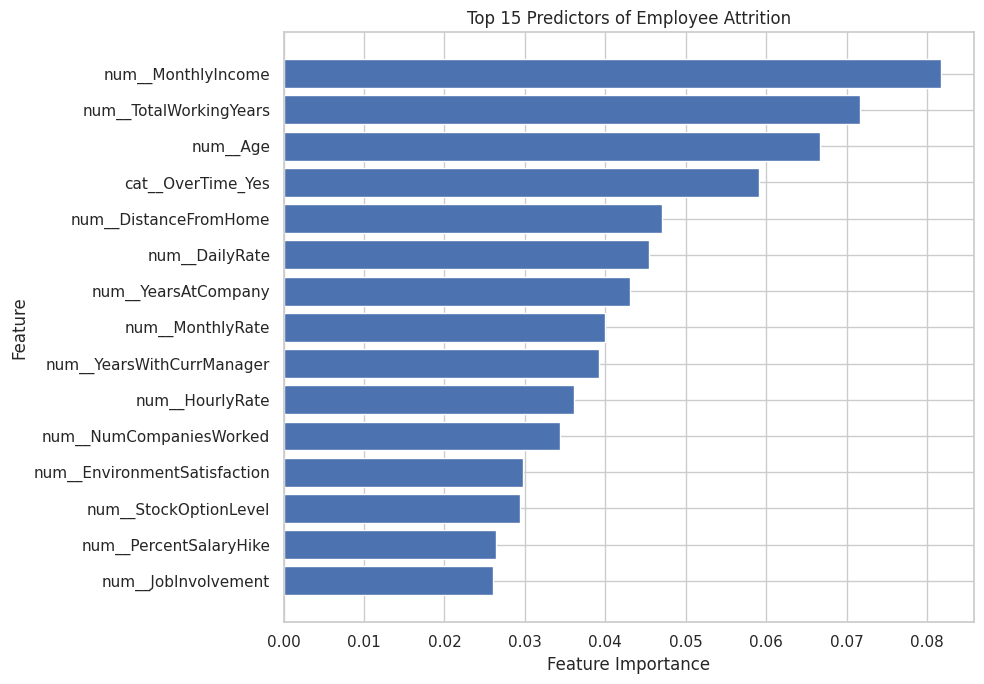

In [ ]:
# TOP 15 RANDOM FOREST FEATURES


top_features = rf_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Predictors of Employee Attrition")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# CLEAN FEATURE NAMES


rf_importance["CleanFeature"] = (
    rf_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

rf_importance.head(20)

,Feature,Importance,CleanFeature
0,num__MonthlyIncome,0.081740,MonthlyIncome
1,num__TotalWorkingYears,0.071718,TotalWorkingYears
2,num__Age,0.066726,Age
3,cat__OverTime_Yes,0.059074,OverTime_Yes
4,num__DistanceFromHome,0.047048,DistanceFromHome
5,num__DailyRate,0.045412,DailyRate
6,num__YearsAtCompany,0.043113,YearsAtCompany
7,num__MonthlyRate,0.039991,MonthlyRate
8,num__YearsWithCurrManager,0.039182,YearsWithCurrManager
9,num__HourlyRate,0.036109,HourlyRate


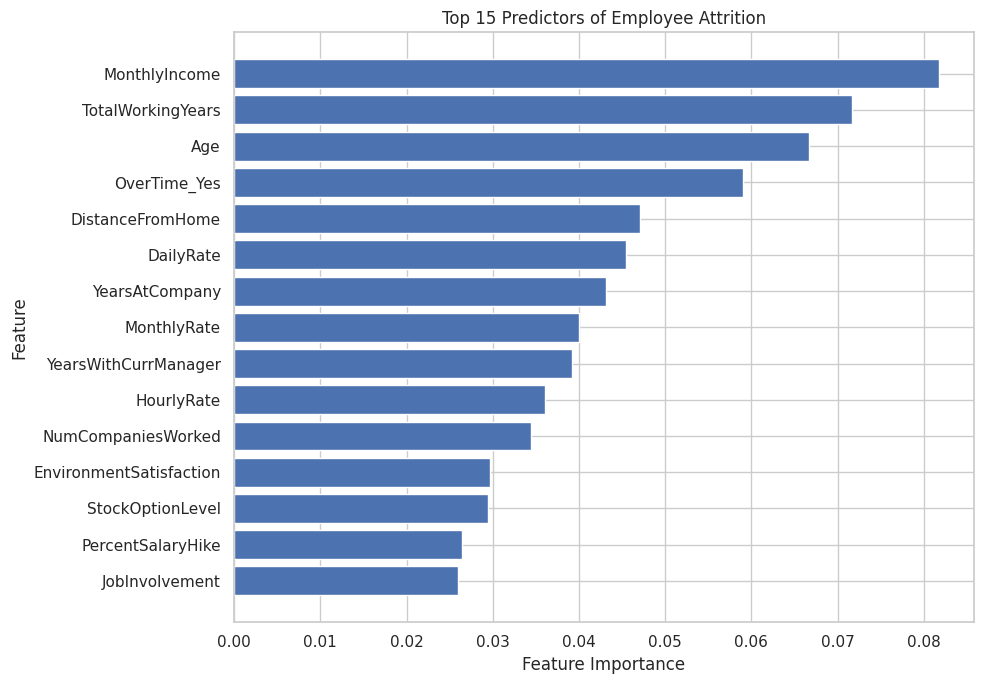

In [ ]:
top_features_clean = rf_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_clean["CleanFeature"],
    top_features_clean["Importance"]
)

plt.title("Top 15 Predictors of Employee Attrition")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
#Percentage Contribution
rf_importance["Importance_Percentage"] = (
    rf_importance["Importance"] * 100
)

rf_importance.head(15)

,Feature,Importance,CleanFeature,Importance_Percentage
0,num__MonthlyIncome,0.081740,MonthlyIncome,8.173996
1,num__TotalWorkingYears,0.071718,TotalWorkingYears,7.171774
2,num__Age,0.066726,Age,6.672628
3,cat__OverTime_Yes,0.059074,OverTime_Yes,5.907443
4,num__DistanceFromHome,0.047048,DistanceFromHome,4.704760
5,num__DailyRate,0.045412,DailyRate,4.541225
6,num__YearsAtCompany,0.043113,YearsAtCompany,4.311333
7,num__MonthlyRate,0.039991,MonthlyRate,3.999052
8,num__YearsWithCurrManager,0.039182,YearsWithCurrManager,3.918152
9,num__HourlyRate,0.036109,HourlyRate,3.610871


In [ ]:
# ============================================
# EMPLOYEE ATTRITION RISK SCORES

# Generate attrition probabilities
final_risk_probability = random_forest.predict_proba(
    X_test
)[:, 1]

# Create risk dataframe
risk_df = X_test.copy()

# Add actual outcome
risk_df["Actual_Attrition"] = y_test.values

# Add probability of leaving
risk_df["Attrition_Probability"] = final_risk_probability

# Apply our selected threshold
risk_df["Predicted_Attrition"] = (
    risk_df["Attrition_Probability"] >= 0.25
).astype(int)

risk_df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EducationLevel,IncomeBand,Actual_Attrition,Attrition_Probability,Predicted_Attrition
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,3,1,Sales Representative,2,Married,2033,7103,1,No,13,3,3,1,1,2,3,1,0,0,0,College,Low,0,0.517861,1
891,44,Travel_Rarely,1117,Research & Development,2,1,Life Sciences,1,Female,72,4,1,Research Scientist,4,Married,2011,19982,1,No,13,3,4,1,10,5,3,10,5,7,7,Below College,Low,0,0.085732,0
456,31,Travel_Rarely,688,Sales,7,3,Life Sciences,3,Male,44,2,3,Manager,4,Divorced,11557,25291,9,No,21,4,3,1,10,3,2,5,4,0,1,Bachelor,Very High,0,0.126730,0
922,44,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,3,Male,92,4,5,Manager,1,Divorced,19190,17477,1,No,14,3,4,2,26,4,2,25,9,14,13,College,Very High,0,0.029684,0
69,36,Travel_Rarely,318,Research & Development,9,3,Medical,4,Male,79,2,1,Research Scientist,3,Married,3388,21777,0,Yes,17,3,1,1,2,0,2,1,0,0,0,Bachelor,Medium,1,0.213638,0


In [ ]:
# CREATE RISK CATEGORIES

def assign_risk_category(probability):

    if probability >= 0.50:
        return "High Risk"

    elif probability >= 0.20:
        return "Medium Risk"

    else:
        return "Low Risk"


risk_df["Risk_Category"] = (
    risk_df["Attrition_Probability"]
    .apply(assign_risk_category)
)

risk_df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EducationLevel,IncomeBand,Actual_Attrition,Attrition_Probability,Predicted_Attrition,Risk_Category
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,3,1,Sales Representative,2,Married,2033,7103,1,No,13,3,3,1,1,2,3,1,0,0,0,College,Low,0,0.517861,1,High Risk
891,44,Travel_Rarely,1117,Research & Development,2,1,Life Sciences,1,Female,72,4,1,Research Scientist,4,Married,2011,19982,1,No,13,3,4,1,10,5,3,10,5,7,7,Below College,Low,0,0.085732,0,Low Risk
456,31,Travel_Rarely,688,Sales,7,3,Life Sciences,3,Male,44,2,3,Manager,4,Divorced,11557,25291,9,No,21,4,3,1,10,3,2,5,4,0,1,Bachelor,Very High,0,0.126730,0,Low Risk
922,44,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,3,Male,92,4,5,Manager,1,Divorced,19190,17477,1,No,14,3,4,2,26,4,2,25,9,14,13,College,Very High,0,0.029684,0,Low Risk
69,36,Travel_Rarely,318,Research & Development,9,3,Medical,4,Male,79,2,1,Research Scientist,3,Married,3388,21777,0,Yes,17,3,1,1,2,0,2,1,0,0,0,Bachelor,Medium,1,0.213638,0,Medium Risk


In [ ]:
risk_distribution = (
    risk_df["Risk_Category"]
    .value_counts()
)

print(risk_distribution)

Risk_Category
Low Risk       216
Medium Risk     67
High Risk       11
Name: count, dtype: int64


In [ ]:
risk_percentage = (
    risk_df["Risk_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(risk_percentage)

Risk_Category
Low Risk       73.47
Medium Risk    22.79
High Risk       3.74
Name: proportion, dtype: float64


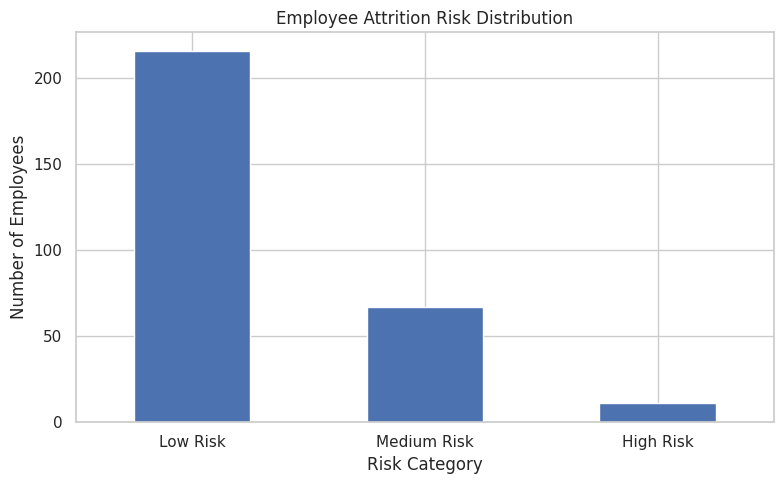

In [ ]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(
    kind="bar"
)

plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# HIGHEST-RISK EMPLOYEES

highest_risk = risk_df.sort_values(
    "Attrition_Probability",
    ascending=False
)

highest_risk[
    [
        "Attrition_Probability",
        "Risk_Category",
        "Predicted_Attrition",
        "Actual_Attrition"
    ]
].head(20)

,Attrition_Probability,Risk_Category,Predicted_Attrition,Actual_Attrition
688,0.871338,High Risk,1,1
911,0.799545,High Risk,1,1
301,0.740209,High Risk,1,0
711,0.602452,High Risk,1,1
1311,0.595630,High Risk,1,0
109,0.563379,High Risk,1,0
357,0.554144,High Risk,1,1
764,0.538841,High Risk,1,0
1402,0.534073,High Risk,1,0
17,0.526288,High Risk,1,0


FINAL CMPAARISON

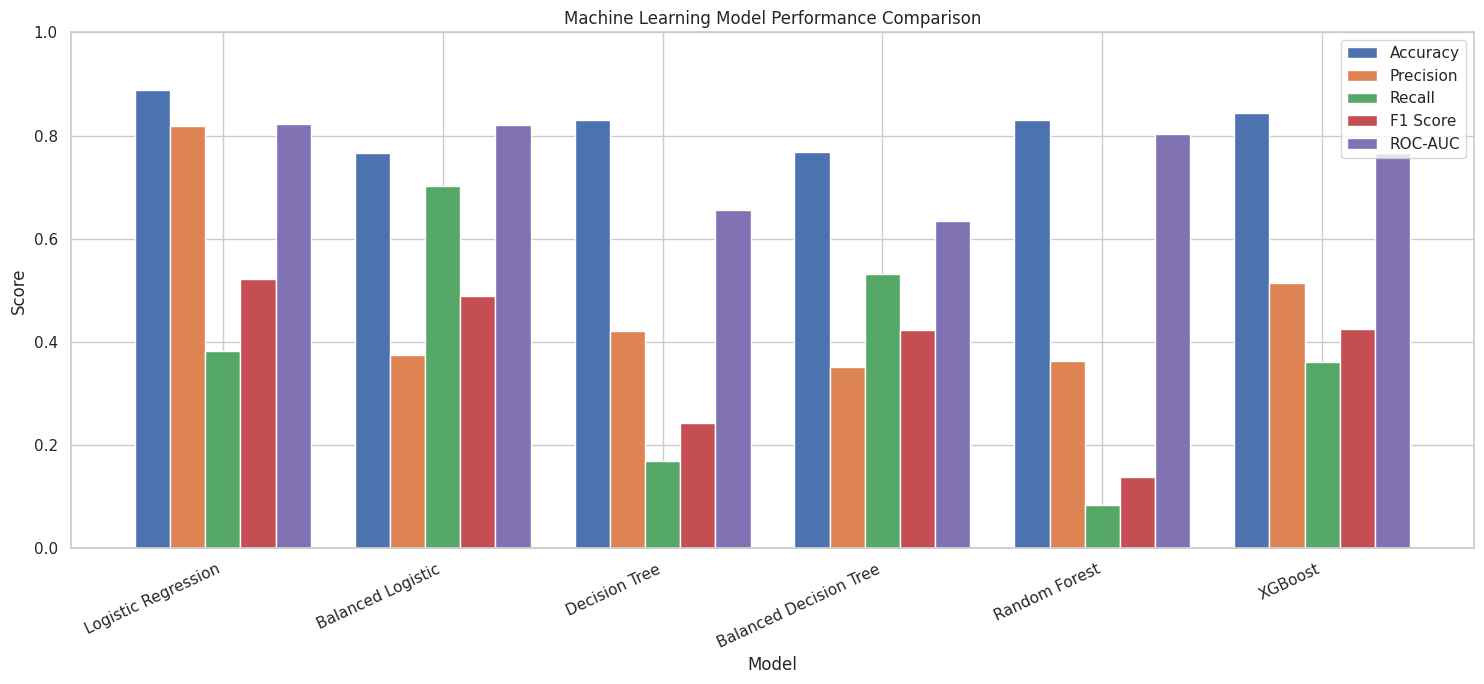

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance data
models = [
    "Logistic Regression",
    "Balanced Logistic",
    "Decision Tree",
    "Balanced Decision Tree",
    "Random Forest",
    "XGBoost"
]

accuracy = [0.8878, 0.7653, 0.8299, 0.7687, 0.8299, 0.8435]
precision = [0.8182, 0.3750, 0.4211, 0.3521, 0.3636, 0.5152]
recall = [0.3830, 0.7021, 0.1702, 0.5319, 0.0851, 0.3617]
f1 = [0.5217, 0.4889, 0.2424, 0.4237, 0.1379, 0.4250]
roc_auc = [0.8225, 0.8207, 0.6556, 0.6346, 0.8023, 0.7666]

x = np.arange(len(models))
width = 0.16

plt.figure(figsize=(15, 7))

plt.bar(x - 2*width, accuracy, width, label="Accuracy")
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1 Score")
plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Machine Learning Model Performance Comparison")
plt.xticks(x, models, rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

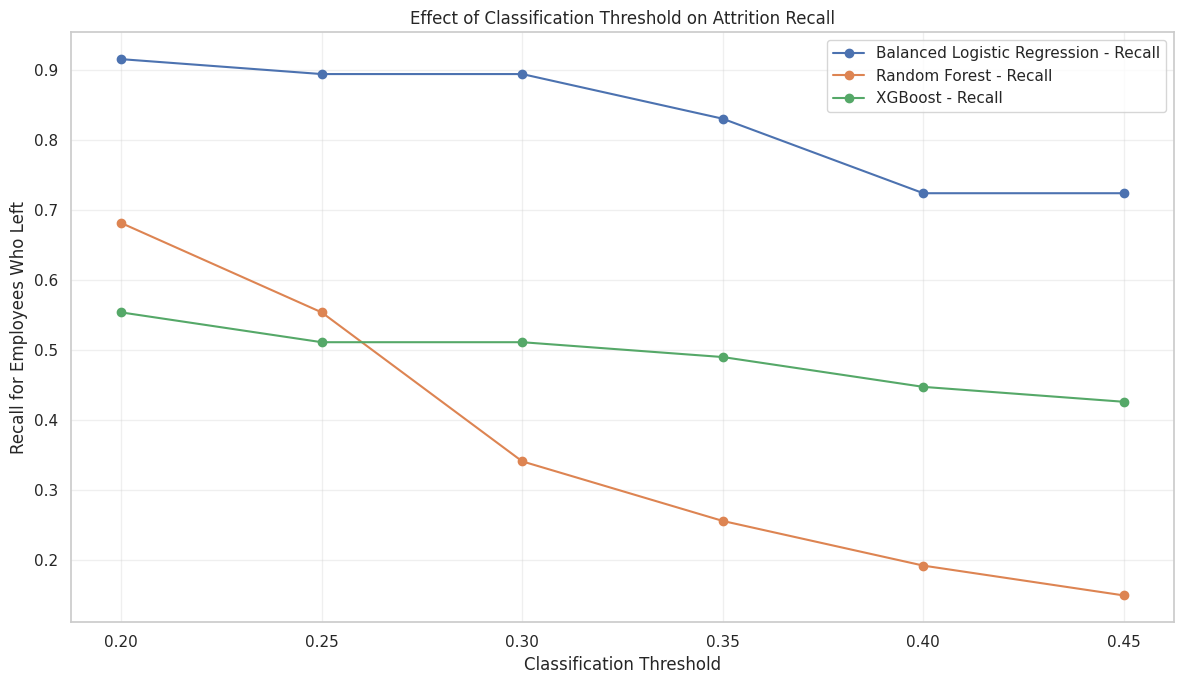

In [ ]:
import matplotlib.pyplot as plt

threshold_data = {
    "Balanced Logistic Regression": {
        "Threshold": [0.20, 0.25, 0.30, 0.35, 0.40, 0.45],
        "Recall": [0.9149, 0.8936, 0.8936, 0.8298, 0.7234, 0.7234],
        "F1": [0.3874, 0.4221, 0.4693, 0.4615, 0.4416, 0.4755]
    },
    "Random Forest": {
        "Threshold": [0.20, 0.25, 0.30, 0.35, 0.40, 0.45],
        "Recall": [0.6809, 0.5532, 0.3404, 0.2553, 0.1915, 0.1489],
        "F1": [0.5120, 0.5149, 0.3855, 0.3243, 0.2769, 0.2222]
    },
    "XGBoost": {
        "Threshold": [0.20, 0.25, 0.30, 0.35, 0.40, 0.45],
        "Recall": [0.5532, 0.5106, 0.5106, 0.4894, 0.4468, 0.4255],
        "F1": [0.3796, 0.4034, 0.4286, 0.4340, 0.4468, 0.4494]
    }
}

plt.figure(figsize=(12, 7))

for model, data in threshold_data.items():
    plt.plot(
        data["Threshold"],
        data["Recall"],
        marker="o",
        label=f"{model} - Recall"
    )

plt.xlabel("Classification Threshold")
plt.ylabel("Recall for Employees Who Left")
plt.title("Effect of Classification Threshold on Attrition Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **MODEL INTERPRETATION**

In [ ]:
# Get the feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of processed features: 51

First 20 features:
['num__Age' 'num__DailyRate' 'num__DistanceFromHome' 'num__Education'
 'num__EnvironmentSatisfaction' 'num__HourlyRate' 'num__JobInvolvement'
 'num__JobLevel' 'num__JobSatisfaction' 'num__MonthlyIncome'
 'num__MonthlyRate' 'num__NumCompaniesWorked' 'num__PercentSalaryHike'
 'num__PerformanceRating' 'num__RelationshipSatisfaction'
 'num__StockOptionLevel' 'num__TotalWorkingYears'
 'num__TrainingTimesLastYear' 'num__WorkLifeBalance' 'num__YearsAtCompany']


In [ ]:
# Extract Logistic Regression coefficients

logistic_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_baseline.named_steps["classifier"].coef_[0]
})

# Calculate absolute importance
logistic_coefficients["AbsoluteCoefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient
logistic_coefficients = logistic_coefficients.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

logistic_coefficients.head(20)

,Feature,Coefficient,AbsoluteCoefficient
47,cat__OverTime_Yes,1.829624,1.829624
23,cat__BusinessTravel_Travel_Frequently,1.518045,1.518045
38,cat__JobRole_Laboratory Technician,1.143849,1.143849
41,cat__JobRole_Research Director,-0.895041,0.895041
30,cat__EducationField_Other,-0.777043,0.777043
46,cat__MaritalStatus_Single,0.767435,0.767435
48,cat__IncomeBand_Low,0.745019,0.745019
50,cat__IncomeBand_Very High,0.731718,0.731718
44,cat__JobRole_Sales Representative,0.728521,0.728521
24,cat__BusinessTravel_Travel_Rarely,0.659777,0.659777


In [ ]:
# Features associated with higher attrition probability

positive_features = logistic_coefficients[
    logistic_coefficients["Coefficient"] > 0
].sort_values(
    "Coefficient",
    ascending=False
)

print("Top features increasing predicted attrition:")
display(positive_features.head(15))

Top features increasing predicted attrition:


,Feature,Coefficient,AbsoluteCoefficient
47,cat__OverTime_Yes,1.829624,1.829624
23,cat__BusinessTravel_Travel_Frequently,1.518045,1.518045
38,cat__JobRole_Laboratory Technician,1.143849,1.143849
46,cat__MaritalStatus_Single,0.767435,0.767435
48,cat__IncomeBand_Low,0.745019,0.745019
50,cat__IncomeBand_Very High,0.731718,0.731718
44,cat__JobRole_Sales Representative,0.728521,0.728521
24,cat__BusinessTravel_Travel_Rarely,0.659777,0.659777
11,num__NumCompaniesWorked,0.514318,0.514318
21,num__YearsSinceLastPromotion,0.465573,0.465573


In [ ]:
# Features associated with lower attrition probability

negative_features = logistic_coefficients[
    logistic_coefficients["Coefficient"] < 0
].sort_values(
    "Coefficient",
    ascending=True
)

print("Top features decreasing predicted attrition:")
display(negative_features.head(15))

Top features decreasing predicted attrition:


,Feature,Coefficient,AbsoluteCoefficient
41,cat__JobRole_Research Director,-0.895041,0.895041
30,cat__EducationField_Other,-0.777043,0.777043
16,num__TotalWorkingYears,-0.533257,0.533257
4,num__EnvironmentSatisfaction,-0.493658,0.493658
25,cat__Department_Research & Development,-0.482121,0.482121
29,cat__EducationField_Medical,-0.453303,0.453303
8,num__JobSatisfaction,-0.392345,0.392345
22,num__YearsWithCurrManager,-0.372360,0.372360
0,num__Age,-0.368262,0.368262
34,cat__EducationLevel_Doctor,-0.367151,0.367151


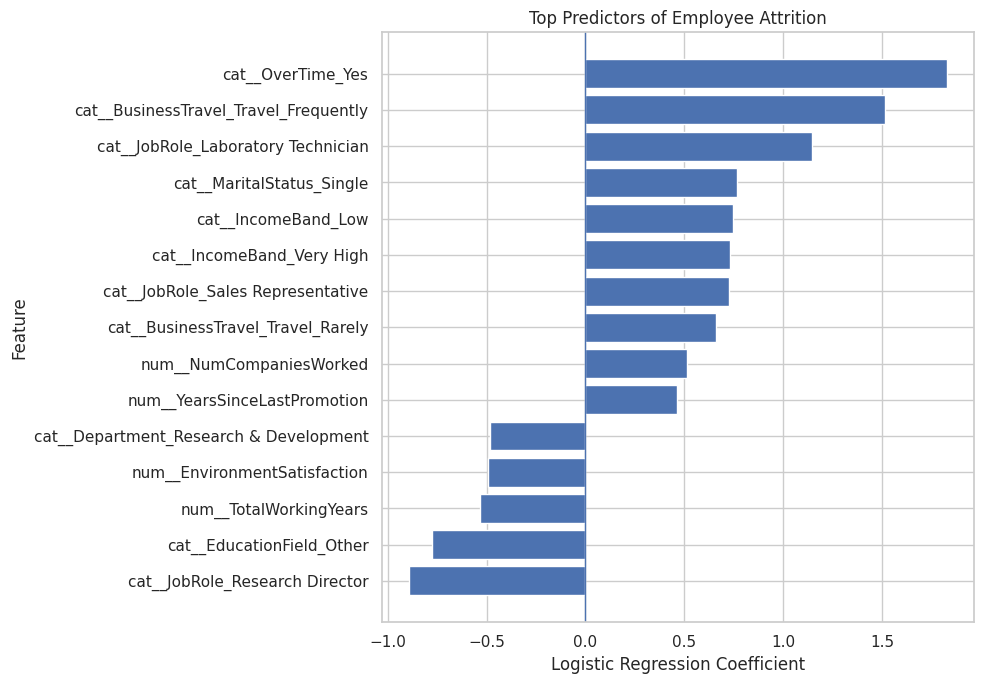

In [ ]:
# Select the 15 most influential features

top_coefficients = logistic_coefficients.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Top Predictors of Employee Attrition")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

SHAP Explainability

In [ ]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# Create SHAP explainer for XGBoost

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (294, 51)


In [ ]:
# Calculate mean absolute SHAP values

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "MeanAbsSHAP",
    ascending=False
)

shap_importance.head(20)

,Feature,MeanAbsSHAP
47,cat__OverTime_Yes,0.697771
15,num__StockOptionLevel,0.435141
0,num__Age,0.398273
9,num__MonthlyIncome,0.387403
11,num__NumCompaniesWorked,0.368718
2,num__DistanceFromHome,0.358641
22,num__YearsWithCurrManager,0.303431
4,num__EnvironmentSatisfaction,0.303039
1,num__DailyRate,0.297200
8,num__JobSatisfaction,0.251929


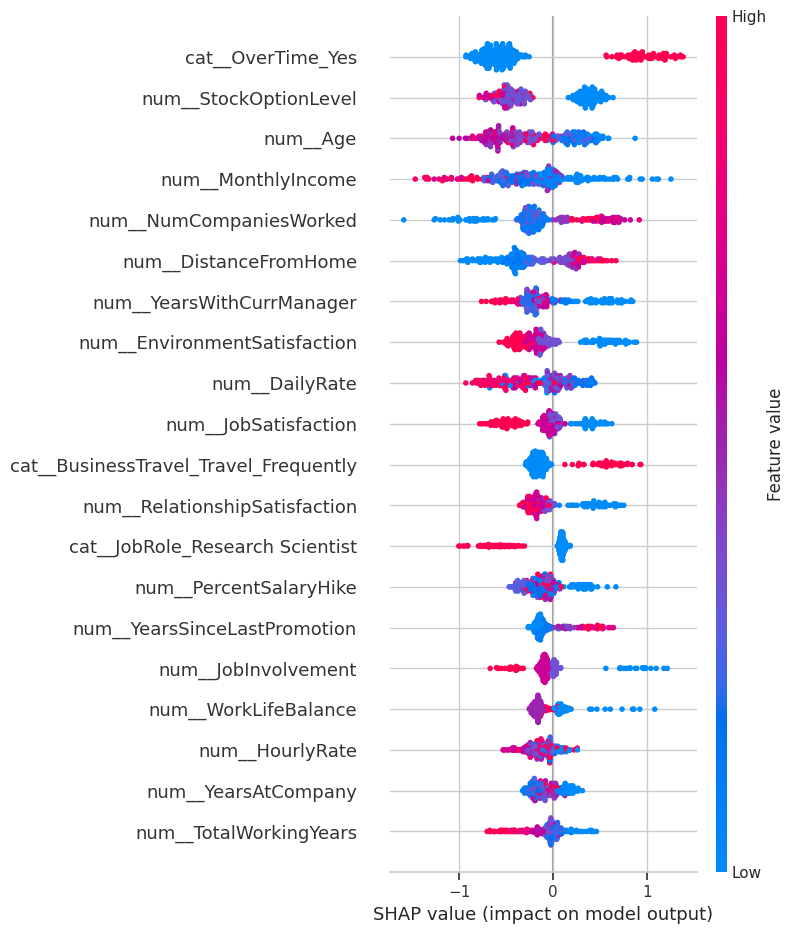

In [ ]:
# SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=20
)

## **IBM HR Analytics — Employee Attrition Prediction & Workforce Insights**

## Project Overview

Employee turnover is a major business challenge because replacing employees can result in recruitment costs, productivity losses, knowledge loss, and additional training requirements.

This project uses the IBM HR Analytics Employee Attrition dataset to investigate the factors associated with employee attrition and develop machine learning models capable of identifying employees who may be at higher risk of leaving.

The project combines:

- Exploratory Data Analysis (EDA)
- Statistical analysis
- Feature engineering
- Data preprocessing
- Class imbalance analysis
- Machine learning classification
- Model comparison
- Classification threshold optimization
- Feature importance analysis
- Logistic Regression interpretation
- SHAP explainability
- Business-oriented interpretation and recommendations

The objective is not simply to achieve high predictive accuracy, but to understand **why employees may leave and how predictive analytics can support proactive HR decision-making.**



# 1. Business Problem

Employee attrition can negatively affect organizational performance through:

- Recruitment and replacement costs
- Loss of experienced employees
- Reduced productivity
- Knowledge and skill gaps
- Increased workload for remaining employees
- Disruption to teams and operations
- Additional onboarding and training requirements

From an HR perspective, identifying employees who are more likely to leave can allow organizations to move from a reactive approach to a more proactive retention strategy.

### Business Problem

The organization needs to understand:

1. What factors are associated with employee attrition?
2. Which employee characteristics are most strongly related to the likelihood of leaving?
3. Can machine learning models identify employees at higher risk of attrition?
4. Which model provides the most useful balance between identifying potential leavers and avoiding excessive false alarms?
5. How can the findings support practical HR retention strategies?

This project therefore treats employee attrition as a **binary classification problem**, where:

- `0` = Employee Stayed
- `1` = Employee Left

# 2. Project Objectives

The major objectives of this project are to:

- Understand the structure and quality of the HR dataset.
- Identify important demographic, professional, compensation, satisfaction, and work-related factors associated with attrition.
- Explore relationships between employee characteristics and monthly income, tenure, satisfaction, and work-life balance.
- Engineer useful analytical features such as age groups and income bands.
- Prepare the dataset for machine learning.
- Address the class imbalance in the attrition target.
- Develop and evaluate multiple classification models.
- Compare model performance using accuracy, precision, recall, F1-score, and ROC-AUC.
- Investigate the impact of classification thresholds.
- Identify important predictors of employee attrition.
- Use SHAP to improve model interpretability.
- Translate the technical findings into actionable HR insights.

# 3. Key Business Questions

The analysis was structured around the following business questions:

### Employee Profile
- Which employee characteristics are associated with attrition?
- Does age appear to influence employee turnover?
- Does marital status have an observable relationship with attrition?
- Does distance from home matter?

### Compensation
- Is monthly income associated with employee attrition?
- Does income level appear to influence the likelihood of leaving?
- How does job level relate to monthly income?

### Career Development
- Does total working experience influence attrition?
- Does time spent at the company influence employee retention?
- Does time with the current manager relate to employee stability?
- Does time since the last promotion matter?

### Satisfaction and Engagement
- Does job satisfaction differ between employees who stay and those who leave?
- Does work-life balance appear to influence attrition?
- Does environmental satisfaction relate to employee turnover?
- Does job involvement contribute to attrition risk?

### Work Conditions
- Does overtime influence work-life balance and attrition?
- Does frequent business travel increase attrition risk?

### Predictive Analytics
- Can machine learning predict employee attrition?
- Which model performs best?
- Which model is most useful from an HR perspective?
- What happens when the classification threshold is changed?

# 4. Dataset & Data Understanding

The project uses the IBM HR Analytics Employee Attrition dataset.

The dataset contains employee-level information covering areas such as:

- Demographics
- Job characteristics
- Compensation
- Job satisfaction
- Work environment
- Career progression
- Work-life balance
- Business travel
- Overtime
- Employee attrition

The analysis also introduced additional engineered variables to make the dataset easier to interpret from a business perspective.

### Target Variable

The target variable used for machine learning was:

`Attrition_Flag`

where:

- `0` = Stayed
- `1` = Left

### Dataset Preparation

Before modeling, the dataset was inspected for:

- Data types
- Missing values
- Duplicate records
- Categorical variables
- Numerical variables
- Engineered features
- Potential preprocessing requirements

# 5. Data Quality Check

The dataset was examined for missing values and data quality issues before proceeding to modeling.

The missing-value check returned:

`0`

This indicates that there were **no missing values requiring imputation** in the dataset at the time of analysis.

The engineered `AgeGroup` variable contained:

`8`

This was not treated as missing data. The value represented the number of records in the corresponding category/value encountered during the inspection and was investigated as part of the feature-engineering/data-validation process.

Overall, the dataset was considered sufficiently clean to proceed to preprocessing after validating the data types and engineered variables.

# 6. Exploratory Data Analysis

Exploratory Data Analysis was conducted to understand the relationships between employee characteristics and attrition.

The analysis covered:

- Demographic characteristics
- Compensation
- Job level
- Career tenure
- Satisfaction
- Work-life balance
- Overtime
- Business travel
- Correlation analysis
- Feature relationships

The EDA was designed to answer business questions rather than simply generate visualizations.

Each analysis was interpreted in terms of its potential HR and workforce implications.

# 7. Correlation Analysis

Correlation analysis was performed to identify numerical variables that had stronger relationships with other numerical variables in the dataset.

The analysis included:

- A correlation matrix
- Heatmap visualization
- Top 20 strongest correlations
- Selected business relationships

Particular attention was given to variables related to:

- Income
- Age
- Working experience
- Company tenure
- Manager tenure
- Job level
- Satisfaction
- Work-life balance

Correlation analysis was used as an exploratory tool. Correlation does not imply causation, so the identified relationships were treated as indicators for further investigation rather than proof of causal relationships.

# 8. Monthly Income vs Total Working Years

The relationship between Monthly Income and Total Working Years was examined to determine whether employees with greater professional experience generally earned higher incomes.

### Business Interpretation

The analysis helps establish whether compensation tends to increase with accumulated professional experience.

This relationship is important because compensation and career progression can influence employee retention. Employees with substantial experience but comparatively low compensation may represent a potential retention concern.

However, the relationship should not be interpreted as evidence that income alone causes employees to leave.

# 9. Monthly Income vs Job Level

Monthly Income was compared with Job Level to investigate the relationship between organizational seniority and compensation.

### Business Interpretation

Job Level is expected to have a strong relationship with compensation because employees at higher organizational levels generally have greater responsibilities and may receive higher salaries.

This analysis provides useful context for understanding whether compensation differences observed elsewhere in the attrition analysis may partly reflect differences in job seniority.

It also helps HR evaluate compensation structures in relation to employee career progression.

# 10. Age vs Total Working Years

Age was compared with Total Working Years to understand the relationship between employee age and accumulated professional experience.

### Business Interpretation

A positive relationship between these variables is expected because older employees generally have had more opportunity to accumulate work experience.

This relationship is important when interpreting model results because age and total working years may contain overlapping information.

Therefore, individual feature importance should be interpreted carefully rather than assuming that one variable independently causes attrition.

# 11. Years at Company vs Years with Current Manager

Years at Company was compared with Years with Current Manager to understand employee tenure and managerial stability.

### Business Interpretation

Employees who have spent longer periods with the organization may also have spent longer periods reporting to the same manager.

This relationship provides insight into organizational stability and employee-manager continuity.

Managerial relationships are particularly relevant to HR because changes in management, limited progression, or weak manager-employee relationships may contribute to employee dissatisfaction in some circumstances.

# 12. Monthly Income vs Job Satisfaction

Monthly Income was compared with Job Satisfaction to investigate whether compensation levels were associated with employees' reported satisfaction.

### Business Interpretation

Compensation is an important component of the employee experience, but higher income does not necessarily guarantee higher job satisfaction.

The analysis therefore considers compensation alongside other factors such as:

- Work environment
- Career progression
- Work-life balance
- Job involvement
- Overtime
- Management relationships

This supports a more holistic interpretation of employee retention.

# 13. Work-Life Balance vs Overtime

The relationship between Work-Life Balance and Overtime was examined using both average work-life balance scores and percentage distributions.

### Average Work-Life Balance

Employees who did not work overtime had an average Work-Life Balance score of approximately:

**2.77**

Employees who worked overtime had an average score of approximately:

**2.73**

The difference was relatively small.

### Percentage Distribution

| Work-Life Balance | No Overtime | Overtime |
|---|---:|---:|
| 1 | 5.50% | 5.29% |
| 2 | 22.77% | 25.00% |
| 3 | 60.63% | 61.06% |
| 4 | 11.10% | 8.65% |

### Business Interpretation

Employees working overtime showed a slightly lower average Work-Life Balance score than employees who did not work overtime.

The distribution also shows that overtime employees had a slightly higher proportion in Work-Life Balance category 2 and a lower proportion in category 4.

This suggests that overtime may be associated with somewhat less favorable work-life balance outcomes.

However, the difference is not large enough to conclude that overtime alone explains employee dissatisfaction or attrition. It should instead be considered alongside other factors such as job satisfaction, workload, compensation, and career progression.

# 14. Feature Engineering

Additional features were created to improve the business interpretability of the dataset.

Examples included:

- `AgeGroup`
- `IncomeBand`
- `Attrition_Flag`

### AgeGroup

Age was transformed into meaningful age categories to support segmented analysis.

### IncomeBand

Monthly income was transformed into income bands such as:

- Low
- Medium
- High
- Very High

These engineered variables made it easier to analyze employee groups and were also incorporated into the machine learning preprocessing pipeline where appropriate.

Feature engineering was performed carefully to ensure that categorical variables were not incorrectly passed to numerical transformations.

# 15. Data Preprocessing

Before machine learning, the dataset was prepared using a preprocessing pipeline.

The dataset contained:

- **23 integer/numerical features**
- **8 object/categorical features**
- **1 categorical feature stored as `category`**

The categorical variables included:

- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- OverTime
- EducationLevel
- IncomeBand

Categorical variables were processed using One-Hot Encoding, while numerical variables were processed using numerical scaling where required.

### Important Preprocessing Issue

During preprocessing, errors initially occurred because categorical variables such as:

- `AgeGroup`
- `IncomeBand`

were incorrectly included among numerical features.

This resulted in errors such as:

`ValueError: could not convert string to float: '46-55'`

and:

`ValueError: could not convert string to float: 'Very High'`

The issue was resolved by correctly separating numerical and categorical features before applying the preprocessing transformations.

### Final Preprocessing Result

The original dataset contained:

**32 features**

After preprocessing and one-hot encoding, the dataset contained:

**51 processed features**

This demonstrates the effect of converting categorical variables into machine-readable numerical representations.

# 16. Train/Test Split & Class Imbalance

The data was divided into training and testing sets before model development.

The training set contained:

- Stayed: **986 employees**
- Left: **190 employees**

### Class Distribution

| Class | Count | Percentage |
|---|---:|---:|
| Stayed | 986 | 83.84% |
| Left | 190 | 16.16% |

The majority-to-minority class ratio was approximately:

**5.19 : 1**

### Business Implication

This represents a significant class imbalance.

If a model focuses primarily on predicting the majority class, it can achieve relatively high accuracy while performing poorly at identifying employees who actually leave.

For an HR attrition problem, this is particularly important because correctly identifying potential leavers is often more valuable than simply maximizing overall accuracy.

Therefore, both standard and class-balanced models were evaluated.

# 17. Machine Learning Strategy

Several classification algorithms were evaluated to determine their ability to predict employee attrition.

The models included:

1. Logistic Regression
2. Balanced Logistic Regression
3. Decision Tree
4. Balanced Decision Tree
5. Random Forest
6. XGBoost

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The primary focus was placed on the performance of the **Left** class because identifying employees who may leave is the key business objective.

# 18. Logistic Regression — Baseline

The standard Logistic Regression model achieved:

| Metric | Score |
|---|---:|
| Accuracy | 0.8878 |
| Precision — Left | 0.8182 |
| Recall — Left | 0.3830 |
| F1 Score — Left | 0.5217 |
| ROC-AUC | 0.8225 |

### Confusion Matrix

- True Negatives: 243
- False Positives: 4
- False Negatives: 29
- True Positives: 18

### Interpretation

The baseline Logistic Regression model achieved the highest overall accuracy among the initial models at approximately **88.8%**.

It also achieved relatively high precision for employees predicted to leave, meaning that when the model predicted an employee would leave, the prediction was reasonably reliable.

However, its recall for the Left class was only **38.3%**.

This means the model identified fewer than four out of every ten actual employees who left.

The model therefore demonstrates strong overall classification performance but is relatively conservative when identifying potential leavers.

From an HR perspective, relying solely on the default 0.50 classification threshold would result in many employees at risk of attrition being missed.

# 19. Balanced Logistic Regression

To address the class imbalance, a class-balanced Logistic Regression model was evaluated.

### Performance

| Metric | Score |
|---|---:|
| Accuracy | 0.7653 |
| Precision — Left | 0.3750 |
| Recall — Left | 0.7021 |
| F1 Score — Left | 0.4889 |
| ROC-AUC | 0.8207 |

### Confusion Matrix

- True Negatives: 192
- False Positives: 55
- False Negatives: 14
- True Positives: 33

### Interpretation

Balancing the classes significantly changed the model's behavior.

Recall for the Left class increased from **38.3% to 70.2%**, meaning the balanced model identified substantially more actual employees who left.

However, this improvement came at the cost of precision and overall accuracy.

The model produced considerably more false positives, meaning more employees who actually stayed were incorrectly flagged as potential leavers.

This illustrates an important business trade-off:

> Improving attrition detection often requires accepting more false alarms.

For an HR intervention program, this trade-off may still be worthwhile because missing a genuinely at-risk employee can be more costly than contacting an employee who ultimately decides to stay.

# 20. Decision Tree

The standard Decision Tree model achieved:

| Metric | Score |
|---|---:|
| Accuracy | 0.8299 |
| Precision — Left | 0.4211 |
| Recall — Left | 0.1702 |
| F1 Score — Left | 0.2424 |
| ROC-AUC | 0.6556 |

### Confusion Matrix

- True Negatives: 236
- False Positives: 11
- False Negatives: 39
- True Positives: 8

### Interpretation

The Decision Tree achieved reasonable overall accuracy but performed poorly in identifying employees who left.

Its recall of only **17.0%** indicates that most actual leavers were missed.

Although decision trees are easy to interpret, this particular configuration was not effective enough for the attrition detection objective.

# 21. Balanced Decision Tree

The balanced Decision Tree produced:

| Metric | Score |
|---|---:|
| Accuracy | 0.7687 |
| Precision — Left | 0.3521 |
| Recall — Left | 0.5319 |
| F1 Score — Left | 0.4237 |
| ROC-AUC | 0.6346 |

### Confusion Matrix

- True Negatives: 201
- False Positives: 46
- False Negatives: 22
- True Positives: 25

### Interpretation

Balancing the Decision Tree substantially improved recall from **17.0% to 53.2%**.

However, the model also produced substantially more false positives and had lower overall accuracy.

Compared with the standard Decision Tree, the balanced model is more useful for identifying potential leavers, but its overall predictive discrimination remained weaker than the Logistic Regression and XGBoost models.

# 21. Balanced Decision Tree

The balanced Decision Tree produced:

| Metric | Score |
|---|---:|
| Accuracy | 0.7687 |
| Precision — Left | 0.3521 |
| Recall — Left | 0.5319 |
| F1 Score — Left | 0.4237 |
| ROC-AUC | 0.6346 |

### Confusion Matrix

- True Negatives: 201
- False Positives: 46
- False Negatives: 22
- True Positives: 25

### Interpretation

Balancing the Decision Tree substantially improved recall from **17.0% to 53.2%**.

However, the model also produced substantially more false positives and had lower overall accuracy.

Compared with the standard Decision Tree, the balanced model is more useful for identifying potential leavers, but its overall predictive discrimination remained weaker than the Logistic Regression and XGBoost models.

# 23. XGBoost

XGBoost was evaluated as a more advanced ensemble learning approach.

### Performance

| Metric | Score |
|---|---:|
| Accuracy | 0.8435 |
| Precision — Left | 0.5152 |
| Recall — Left | 0.3617 |
| F1 Score — Left | 0.4250 |
| ROC-AUC | 0.7666 |

### Confusion Matrix

- True Negatives: 231
- False Positives: 16
- False Negatives: 30
- True Positives: 17

### Interpretation

XGBoost achieved an accuracy of approximately **84.4%** and the highest precision for the Left class among the evaluated models at their default thresholds.

Its precision of **51.5%** means that approximately half of the employees flagged as potential leavers were actually in the Left class.

However, recall was only **36.2%**, meaning that many actual leavers were still missed.

XGBoost therefore provided a useful balance between precision and predictive performance but still required threshold analysis for a retention-focused business application.

# 24. Model Comparison

The major models were compared using their performance on the Left class.

| Model | Accuracy | Precision — Left | Recall — Left | F1 — Left | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8878 | 0.8182 | 0.3830 | 0.5217 | 0.8225 |
| Balanced Logistic Regression | 0.7653 | 0.3750 | 0.7021 | 0.4889 | 0.8207 |
| Decision Tree | 0.8299 | 0.4211 | 0.1702 | 0.2424 | 0.6556 |
| Balanced Decision Tree | 0.7687 | 0.3521 | 0.5319 | 0.4237 | 0.6346 |
| Random Forest | 0.8299 | 0.3636 | 0.0851 | 0.1379 | 0.8023 |
| XGBoost | 0.8435 | 0.5152 | 0.3617 | 0.4250 | 0.7666 |

### Key Observation

No single model dominated every metric.

The standard Logistic Regression model produced the highest accuracy and strong ROC-AUC.

The Balanced Logistic Regression model produced the highest recall for the Left class at the default threshold.

XGBoost produced the strongest default precision among the evaluated models.

This demonstrated why model selection should be driven by the **business objective**, rather than accuracy alone.

# 25. Classification Threshold Analysis

The default classification threshold of 0.50 was not automatically treated as the optimal business threshold.

For an employee attrition problem, the cost of missing a genuinely at-risk employee may be significant.

Therefore, thresholds from 0.20 to 0.45 were evaluated for:

- Balanced Logistic Regression
- Random Forest
- XGBoost

The purpose was to understand how changing the threshold affects:

- Accuracy
- Precision
- Recall
- F1 Score

# 26. Threshold Analysis Results

| Model | Threshold | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|---:|
| Balanced Logistic Regression | 0.20 | 0.5374 | 0.2457 | 0.9149 | 0.3874 |
| Random Forest | 0.20 | 0.7925 | 0.4103 | 0.6809 | 0.5120 |
| XGBoost | 0.20 | 0.7109 | 0.2889 | 0.5532 | 0.3796 |
| Balanced Logistic Regression | 0.25 | 0.6088 | 0.2763 | 0.8936 | 0.4221 |
| Random Forest | 0.25 | 0.8333 | 0.4815 | 0.5532 | 0.5149 |
| XGBoost | 0.25 | 0.7585 | 0.3333 | 0.5106 | 0.4034 |
| Balanced Logistic Regression | 0.30 | 0.6769 | 0.3182 | 0.8936 | 0.4693 |
| Random Forest | 0.30 | 0.8265 | 0.4444 | 0.3404 | 0.3855 |
| XGBoost | 0.30 | 0.7823 | 0.3692 | 0.5106 | 0.4286 |
| Balanced Logistic Regression | 0.35 | 0.6905 | 0.3197 | 0.8298 | 0.4615 |
| Random Forest | 0.35 | 0.8299 | 0.4444 | 0.2553 | 0.3243 |
| XGBoost | 0.35 | 0.7959 | 0.3898 | 0.4894 | 0.4340 |
| Balanced Logistic Regression | 0.40 | 0.7075 | 0.3178 | 0.7234 | 0.4416 |
| Random Forest | 0.40 | 0.8401 | 0.5000 | 0.1915 | 0.2769 |
| XGBoost | 0.40 | 0.8231 | 0.4468 | 0.4468 | 0.4468 |
| Balanced Logistic Regression | 0.45 | 0.7449 | 0.3542 | 0.7234 | 0.4755 |
| Random Forest | 0.45 | 0.8333 | 0.4375 | 0.1489 | 0.2222 |
| XGBoost | 0.45 | 0.8333 | 0.4762 | 0.4255 | 0.4494 |

### Key Finding

Lowering the classification threshold generally increases recall because the model becomes more willing to classify employees as potential leavers.

However, this also reduces precision and can increase the number of employees flagged for intervention.

This confirms that threshold selection should be based on the organization's tolerance for:

- Missed at-risk employees
- False alarms
- HR intervention capacity
- Cost of employee turnover

# 28. Threshold Recall Visualization

The threshold analysis was visualized to demonstrate how attrition recall changes as the classification threshold increases.

### Key Observation

The visualization shows that:

- Balanced Logistic Regression maintains the highest recall across the tested thresholds.
- Random Forest experiences the steepest decline in recall as the threshold increases.
- XGBoost maintains a more moderate recall pattern.

The analysis demonstrates the fundamental trade-off between sensitivity and selectivity in employee attrition prediction.

Lower thresholds increase the number of employees identified as potential leavers, while higher thresholds produce a smaller and more selective group.

# 30. Random Forest Feature Importance

The Random Forest feature importance analysis identified several variables with relatively high predictive contribution.

The leading features included:

1. Monthly Income
2. Total Working Years
3. Age
4. OverTime — Yes
5. Distance From Home
6. Daily Rate
7. Years At Company
8. Monthly Rate
9. Years With Current Manager
10. Hourly Rate
11. Number of Companies Worked
12. Environment Satisfaction
13. Stock Option Level
14. Percent Salary Hike
15. Job Involvement
16. Years In Current Role
17. Work-Life Balance
18. Job Satisfaction
19. Relationship Satisfaction
20. Job Level

### Interpretation

Compensation, experience, workload, tenure, satisfaction, and employee circumstances all appeared among the important predictors.

This supports the broader finding that employee attrition is a **multifactor problem** rather than being driven by a single variable.

# 31. XGBoost Feature Importance

The XGBoost model identified the following as important predictive features:

- Job Role — Sales Executive
- OverTime — Yes
- Job Level
- Stock Option Level
- Income Band — Low
- Department — Sales
- Years With Current Manager
- Years At Company
- Education Field — Marketing
- Job Role — Sales Representative
- Age
- Job Role — Research Director
- Number of Companies Worked
- Business Travel — Travel Frequently
- Job Role — Research Scientist
- Work-Life Balance
- Environment Satisfaction
- Monthly Income
- Total Working Years

### Interpretation

XGBoost identified a mixture of:

- Job characteristics
- Compensation
- Career progression
- Work conditions
- Employee demographics
- Business travel
- Satisfaction

as relevant predictors of attrition.

The prominence of overtime and job-role-related variables suggests that employee retention strategies should consider differences in workload and employee experience across roles rather than applying a single organization-wide intervention.

# 32. Logistic Regression Coefficient Analysis

Logistic Regression provides an additional advantage because its coefficients can be interpreted directionally.

Positive coefficients indicate that a feature increases the model's predicted likelihood of the positive class (`Left`), while negative coefficients indicate a lower predicted likelihood, holding the other model variables constant.

### Strong Positive Predictors

The largest positive coefficients included:

- OverTime — Yes: **1.8296**
- BusinessTravel — Travel Frequently: **1.5180**
- JobRole — Laboratory Technician: **1.1438**
- MaritalStatus — Single: **0.7674**
- IncomeBand — Low: **0.7450**
- IncomeBand — Very High: **0.7317**
- JobRole — Sales Representative: **0.7285**
- BusinessTravel — Travel Rarely: **0.6598**
- Number of Companies Worked: **0.5143**
- Years Since Last Promotion: **0.4656**

### Strong Negative Predictors

Important negative coefficients included:

- JobRole — Research Director: **-0.8950**
- EducationField — Other: **-0.7770**
- Total Working Years: **-0.5333**
- Environment Satisfaction: **-0.4937**
- Department — Research & Development: **-0.4821**
- EducationField — Medical: **-0.4533**
- Job Satisfaction: **-0.3923**
- Years With Current Manager: **-0.3724**
- Age: **-0.3683**
- Job Involvement: **-0.3655**
- Relationship Satisfaction: **-0.3117**
- Work-Life Balance: **-0.2897**
- Stock Option Level: **-0.2860**

### Important Note

These coefficients describe relationships learned by the model and should not be interpreted as proof of causation.

Categorical variables are also interpreted relative to their omitted reference categories created during one-hot encoding.

# 33. SHAP Explainability

SHAP (SHapley Additive exPlanations) was used to provide a more detailed explanation of model predictions.

Unlike simple feature importance, SHAP helps explain:

- Which features influence predictions
- The direction of their influence
- The relative magnitude of their contribution

The SHAP summary visualization showed several important predictors.

### Major SHAP Features

The strongest features included:

- OverTime — Yes
- Stock Option Level
- Age
- Monthly Income
- Number of Companies Worked
- Distance From Home
- Years With Current Manager
- Environment Satisfaction
- Daily Rate
- Job Satisfaction
- Business Travel — Travel Frequently
- Relationship Satisfaction
- Job Role — Research Scientist
- Percent Salary Hike
- Years Since Last Promotion
- Job Involvement
- Work-Life Balance
- Years At Company
- Total Working Years

### Interpretation

The SHAP analysis reinforces several patterns identified during EDA and model-based feature importance analysis.

In particular, **OverTime** consistently appears as one of the strongest predictive variables.

Compensation, career history, satisfaction, workload, and employee circumstances also contribute meaningfully to the model's predictions.

This consistency across multiple analytical methods increases confidence that these areas deserve attention in the business interpretation.

# 33. SHAP Explainability

SHAP (SHapley Additive exPlanations) was used to provide a more detailed explanation of model predictions.

Unlike simple feature importance, SHAP helps explain:

- Which features influence predictions
- The direction of their influence
- The relative magnitude of their contribution

The SHAP summary visualization showed several important predictors.

### Major SHAP Features

The strongest features included:

- OverTime — Yes
- Stock Option Level
- Age
- Monthly Income
- Number of Companies Worked
- Distance From Home
- Years With Current Manager
- Environment Satisfaction
- Daily Rate
- Job Satisfaction
- Business Travel — Travel Frequently
- Relationship Satisfaction
- Job Role — Research Scientist
- Percent Salary Hike
- Years Since Last Promotion
- Job Involvement
- Work-Life Balance
- Years At Company
- Total Working Years

### Interpretation

The SHAP analysis reinforces several patterns identified during EDA and model-based feature importance analysis.

In particular, **OverTime** consistently appears as one of the strongest predictive variables.

Compensation, career history, satisfaction, workload, and employee circumstances also contribute meaningfully to the model's predictions.

This consistency across multiple analytical methods increases confidence that these areas deserve attention in the business interpretation.

# 36. Business Recommendations

Based on the combined EDA, machine learning, feature importance, coefficient analysis, and SHAP results, the following recommendations can be considered.

## 1. Monitor overtime exposure

Overtime was consistently identified as an important predictor.

HR should monitor employees with sustained overtime workloads and investigate whether workload distribution, staffing, scheduling, or role expectations are contributing to increased attrition risk.

## 2. Strengthen career progression

Variables such as Total Working Years, Years At Company, Years Since Last Promotion, and Job Level were important in the analysis.

Organizations should ensure employees have:

- Clear career paths
- Regular performance discussions
- Promotion opportunities
- Professional development plans
- Transparent progression criteria

## 3. Review compensation alongside employee experience

Monthly Income and Income Band appeared among important predictors.

Compensation reviews should consider:

- Role
- Job level
- Experience
- Market competitiveness
- Internal equity
- Career progression

Compensation should not be treated as the only retention lever.

## 4. Improve employee satisfaction

Job Satisfaction and Environment Satisfaction were relevant predictors.

HR teams should regularly gather employee feedback and identify workplace factors contributing to dissatisfaction.

## 5. Pay attention to business travel

Frequent business travel appeared as an important predictive factor.

Organizations may consider:

- Travel workload reviews
- Flexible scheduling
- Adequate recovery periods
- Travel support
- Monitoring employees with sustained travel requirements

## 6. Strengthen manager-employee relationships

Years With Current Manager and Relationship Satisfaction appeared in the analysis.

Managers should be equipped with effective:

- Communication skills
- Feedback practices
- Employee development practices
- Conflict-resolution skills
- Recognition strategies

## 7. Use predictive analytics for proactive HR intervention

The machine learning models demonstrate that employee-level attrition risk can potentially be estimated.

However, predictions should be used to **support HR decision-making**, not automatically determine employment decisions.

Employees flagged as higher risk should receive appropriate human review and supportive interventions rather than punitive treatment.

# 37. Responsible Use of the Model

Employee attrition prediction involves sensitive workforce information and should therefore be implemented responsibly.

The model should not be used to:

- Automatically terminate employees
- Penalize employees
- Deny promotions
- Make irreversible employment decisions
- Treat predictions as facts

Instead, predictions should be used as an early-warning signal that allows HR professionals to investigate potential workplace issues.

### Key Principles

- Human oversight
- Transparency
- Fairness
- Privacy
- Appropriate data governance
- Regular model evaluation
- Monitoring for bias
- Responsible intervention

A model prediction indicates **risk**, not certainty.


# 38. Project Limitations

Although the analysis provides useful insights, several limitations should be acknowledged.

### 1. Dataset limitations

The analysis is based on the IBM HR Analytics dataset, which may not represent every organization's workforce structure or employee behavior.

### 2. Historical data

Machine learning models learn patterns from historical observations. Changes in organizational policies, labor markets, compensation structures, or employee behavior may affect future performance.

### 3. Correlation does not imply causation

Observed relationships do not prove that a specific variable causes employee attrition.

### 4. Class imbalance

The original dataset contained substantially more employees who stayed than employees who left.

Although class balancing and threshold analysis were used, imbalance remains an important consideration.

### 5. Model interpretability

Different machine learning algorithms may rank features differently.

Therefore, feature importance should be interpreted collectively rather than as absolute causal rankings.

### 6. HR intervention capacity

A model that identifies many potential leavers may create too many cases for HR teams to investigate.

Therefore, model thresholds should be aligned with practical organizational capacity.

# 39. Final Project Conclusion

This project demonstrates how data analytics and machine learning can be used to investigate employee attrition from both a technical and business perspective.

The analysis moved beyond simply predicting whether an employee would leave.

It examined:

- Employee demographics
- Compensation
- Career progression
- Job satisfaction
- Work-life balance
- Overtime
- Business travel
- Organizational tenure
- Managerial relationships
- Predictive model performance
- Classification thresholds
- Feature importance
- Model explainability

The machine learning analysis showed that no single metric should be used to judge an attrition model.

The standard Logistic Regression model achieved high overall accuracy, while the Balanced Logistic Regression model substantially improved recall for employees who left.

Random Forest demonstrated that threshold adjustment can produce a more practical balance between attrition detection and the number of employees flagged for intervention.

XGBoost provided another useful predictive approach and identified several workforce characteristics as important predictors.

Across multiple analytical techniques, variables related to **overtime, compensation, career experience, tenure, satisfaction, business travel, and employee circumstances** repeatedly appeared as relevant predictors.

Overall, the project demonstrates the value of combining:

**Exploratory Data Analysis + Statistical Reasoning + Machine Learning + Explainability + Business Interpretation**

to support more proactive and data-informed workforce management.